In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv
/kaggle/input/datasets/riddhimadeshmukh/teleco-customer-churn-dataset/Telco-Customer-Churn.csv


# Initialization

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report

In [25]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")
sample_submission_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv")


In [4]:
train_data.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [15]:
num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns

In [16]:
train_data.loc[:, num_cols].describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,num_addons,tenure_group
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,0.520965,0.302649,36.577258,0.938907,0.615252,65.866223,2494.377057,0.225208,2.053368,1.724366
std,0.317936,0.499561,0.459405,25.061922,0.239501,0.486536,31.067444,2353.916710,0.417719,1.968652,1.216272
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,12.000000,1.000000,0.000000,29.900000,639.650000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,35.000000,1.000000,1.000000,74.100000,1433.650000,0.000000,2.000000,2.000000
75%,0.000000,1.000000,1.000000,62.000000,1.000000,1.000000,90.800000,4263.800000,0.000000,4.000000,3.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,6.000000,3.000000


In [4]:
def getColumnWiseDistinctValues(df): 
    for col in df.columns:
        print(col, ":", train_data[col].unique())
        print("")

In [6]:
getColumnWiseDistinctValues(train_data);

id : [     0      1      2 ... 594191 594192 594193]

gender : ['Male' 'Female']

SeniorCitizen : [0 1]

Partner : ['Yes' 'No']

Dependents : ['Yes' 'No']

tenure : [29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]

PhoneService : ['Yes' 'No']

MultipleLines : ['No' 'Yes' 'No phone service']

InternetService : ['DSL' 'Fiber optic' 'No']

OnlineSecurity : ['Yes' 'No' 'No internet service']

OnlineBackup : ['No' 'Yes' 'No internet service']

DeviceProtection : ['Yes' 'No' 'No internet service']

TechSupport : ['Yes' 'No' 'No internet service']

StreamingTV : ['No' 'Yes' 'No internet service']

StreamingMovies : ['No' 'Yes' 'No internet service']

Contract : ['One year' 'Two year' 'Month-to-month']

PaperlessBilling : ['Yes' 'No']

PaymentMethod : ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfe

Observations: 
- 'No phone service' or 'No internet service' are redundant with the columns PhoneService and InternetService (if they are no, then no need of specifying in other columns)
- Can consider putting tenure into groups
- MonthlyCharges needs to be scaled as it includes 18.45 as well as 112.05
- TotalCharges derived from MonthlyCharges x tenure?

## Understanding the Data

Target -> 
* Churn: Did the customer leave the company? Yes or No. 

Customer Info -> 
* id: A unique number to identify each customer. Not useful for prediction.
* gender: Male or Female.
* SeniorCitizen: Whether the customer is 65+. Stored as 1 (yes) or 0 (no).
* Partner: Whether the customer has a spouse/partner (Yes/No).
* Dependents: Whether the customer has dependents like children (Yes/No).

Account Info ->
* tenure: How many months the customer has been with the company. A tenure of 1 means they just joined; 72 means they've been there 6 years. This is usually one of the strongest predictors (longer customers churn less).
* Contract: The type of contract - Month-to-month, One year, or Two year. Month-to-month customers are much easier to leave and tend to churn more.
* PaperlessBilling: Whether the customer gets bills via email instead of paper (Yes/No).
* PaymentMethod: How they pay - Electronic check, Mailed check, Bank transfer, or Credit card.
* MonthlyCharges: How much they're billed per month in dollars.
* TotalCharges: The total amount they've ever been billed (roughly tenure × MonthlyCharges).

Phone Services ->
* PhoneService: Whether the customer has a phone line with the company (Yes/No).
* MultipleLines: Whether they have more than one phone line. Can be Yes, No, or No phone service.

Internet Services ->
* InternetService: Type of internet - DSL, Fiber optic, or No. Fiber optic customers may tend to churn more, possibly because they're more tech-savvy and shop around.
* OnlineSecurity: Add-on that protects against online threats (Yes / No / No internet service).
* OnlineBackup: Cloud backup service add-on.
* DeviceProtection: Insurance/protection plan for their devices.
* TechSupport: Access to a tech support helpline.
* StreamingTV: Whether they stream TV through the internet service.
* StreamingMovies: Whether they stream movies through the internet service.

# EDA

In [49]:
# check churn imbalance

train_data['Churn'].value_counts(normalize=True)

Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

In [6]:
cat_cols = train_data.select_dtypes(include=['object']).columns
cat_features = cat_cols[cat_cols != 'Churn']
cat_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

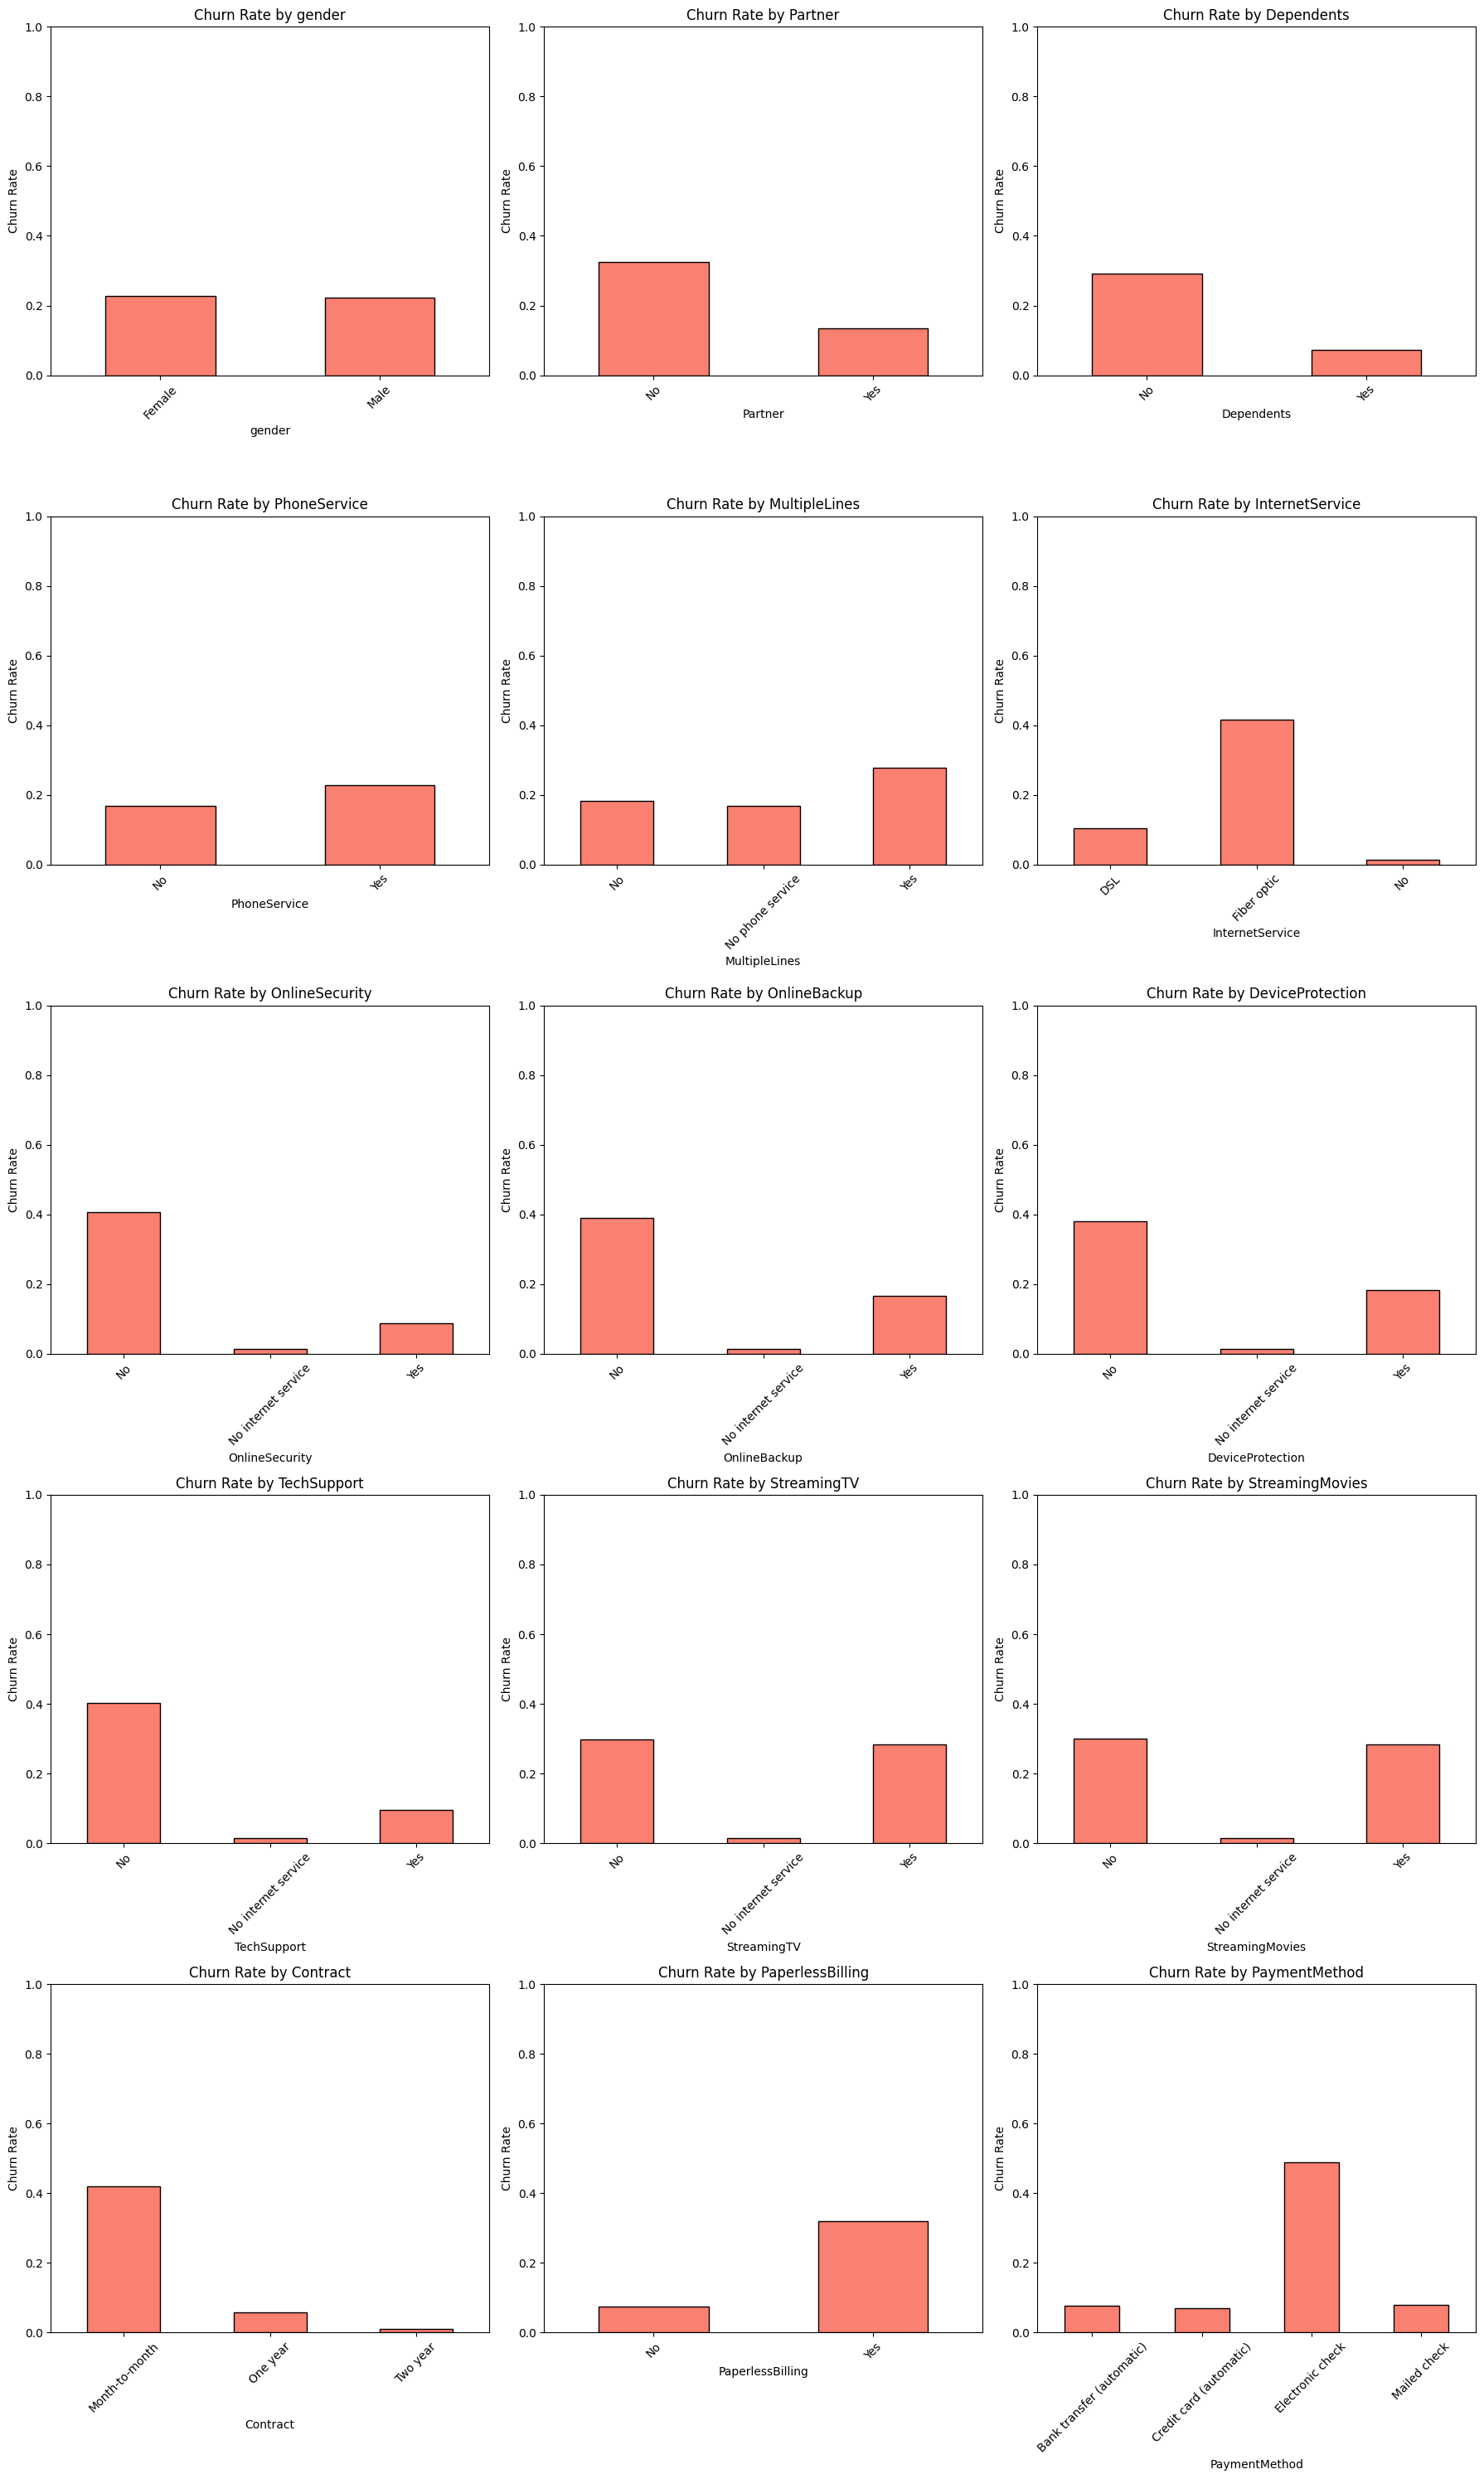

In [23]:
fig, axes = plt.subplots(5, 3, figsize=(18, 30))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = train_data.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

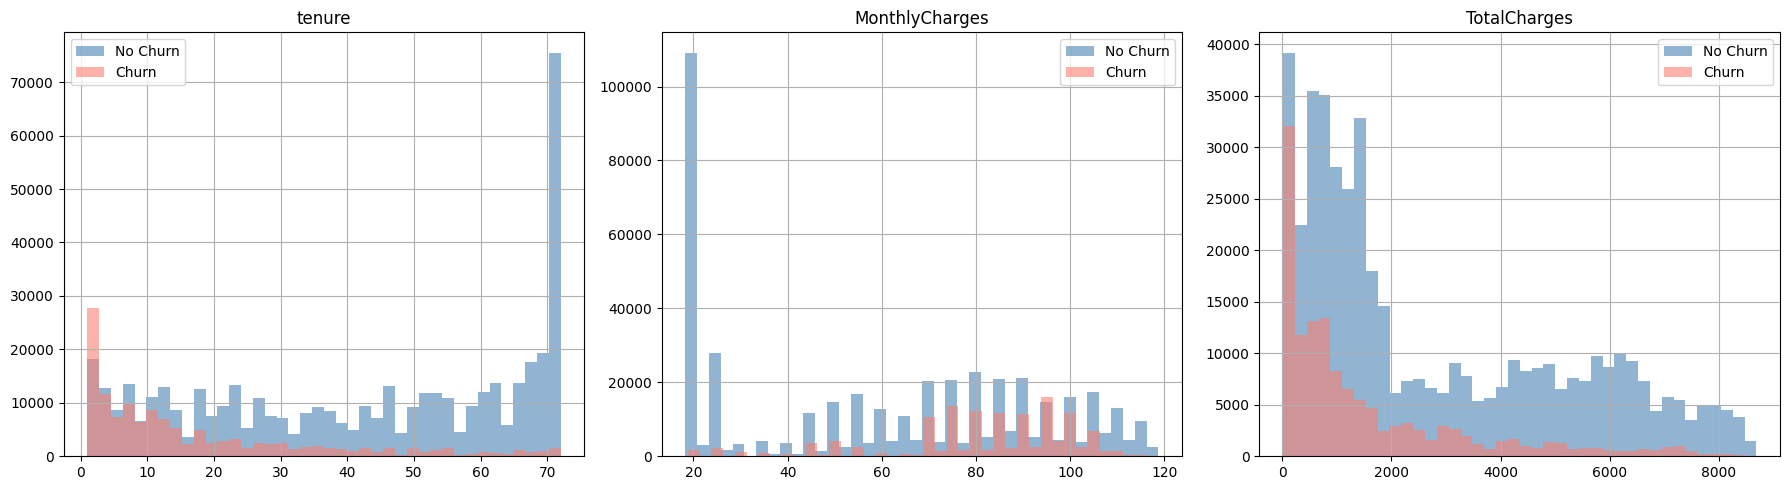

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    train_data[train_data['Churn'] == 'No'][col].hist(ax=ax, alpha=0.6, label='No Churn', bins=40, color='steelblue')
    train_data[train_data['Churn'] == 'Yes'][col].hist(ax=ax, alpha=0.6, label='Churn', bins=40, color='salmon')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

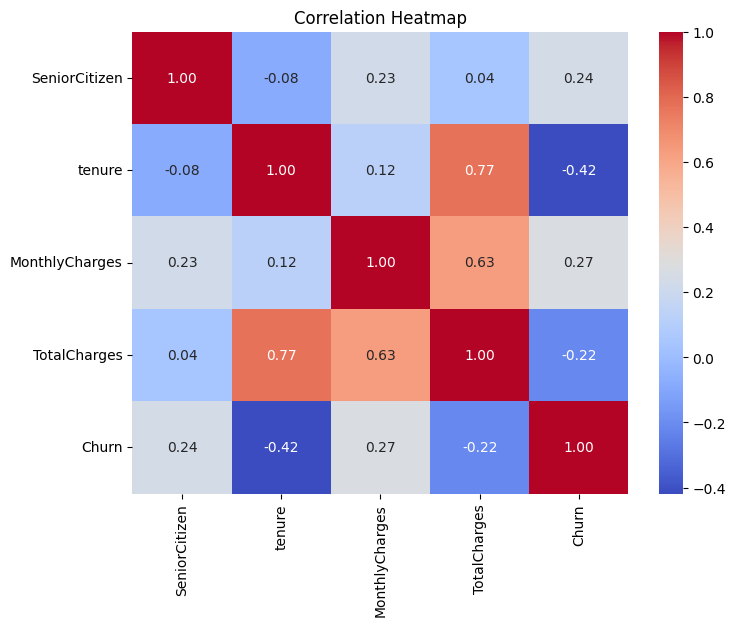

In [19]:
# temporarily encode just for the heatmap
temp = train_data.copy()
temp['Churn'] = (temp['Churn'] == 'Yes').astype(int)

# only numeric cols for now
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

plt.figure(figsize=(8, 6))
sns.heatmap(temp[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Observations:

\
Class Balance:
- Dataset is moderately imbalanced: **77.5% No Churn / 22.5% Churn**
- Will need to account for this during modeling 


\
Categorical Features:

\
Strong Predictors
| Feature | Observation |
|---|---|
| `Contract` | Month-to-month customers churn at **~42%** vs 6% (one year) and 2% (two year)  |
| `PaymentMethod` | Electronic check customers churn at **~49%** — nearly 5x higher than other payment methods |
| `InternetService` | Fiber optic customers churn at **~42%** vs DSL at ~11% |
| `PaperlessBilling` | Paperless billing customers churn at **~33%** vs ~8% for non-paperless |

\
Add-on Services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies)
- Consistent pattern across all six: customers **without** an add-on (but with internet) churn at **~38–40%**
- Customers **with** an add-on churn at only **~8–18%**
- "No internet service" group has near-zero churn — they are a distinct, highly loyal segment

\
Weak / No Signal
| Feature | Observation |
|---|---|
| `Gender` | Male and female churn at identical rates (~22%)  |
| `PhoneService` | Very small difference in churn rate — weak signal |
| `MultipleLines` | Slight uplift for multiple lines, but weak overall |

\
Moderate Predictors
| Feature | Observation |
|---|---|
| `Partner` | No partner: ~32% churn vs ~13% with partner |
| `Dependents` | No dependents: ~30% churn vs ~8% with dependents |

\
\
Numeric Features

| Feature | Observation |
|---|---|
| `tenure` | Churn is heavily concentrated in the **first few months**; customers at 72 months almost never churn. Strongest numeric predictor. |
| `MonthlyCharges` | Churners cluster in the high charge range (~$60–100+)|
| `TotalCharges` | Churners have **low total charges** — consistent with leaving early in their tenure |

\
Correlations (Heatmap)

| Pair | Correlation | Interpretation |
|---|---|---|
| `tenure` → `Churn` | **-0.42** | Longest tenure = most likely to stay |
| `MonthlyCharges` → `Churn` | **+0.27** | Higher bill = more likely to churn |
| `TotalCharges` → `Churn` | **-0.22** | High total spend = long-tenured = stays |
| `tenure` & `TotalCharges` | **0.77** | Highly correlated — expected (tenure × monthly ≈ total) |

\
Feature Engineering Ideas 
- `num_addons` — count of add-on services a customer has
- `tenure_group` — bin tenure into 0–1yr, 1–2yr, 2–4yr, 4–6yr
- `charge_discrepancy` — difference between MonthlyCharges and TotalCharges/tenure (signals rate changes)

# Advanced EDA

In [36]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

X = train_data.drop(columns=['Churn'])
y = train_data['Churn']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': X.columns,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print(mi_df.to_string())

                                  feature  mutual_info
7                            TotalCharges     0.138612
27         PaymentMethod_Electronic_check     0.137749
22            InternetService_Fiber_optic     0.137380
30                           tenure_group     0.133383
25                      Contract_Two_year     0.122055
4                            PhoneService     0.115053
5                        PaperlessBilling     0.113429
3                                  tenure     0.108455
1                                 Partner     0.105357
6                          MonthlyCharges     0.094729
10     OnlineSecurity_No_internet_service     0.078518
16        TechSupport_No_internet_service     0.077522
14   DeviceProtection_No_internet_service     0.077205
12       OnlineBackup_No_internet_service     0.076908
18        StreamingTV_No_internet_service     0.076671
23                     InternetService_No     0.076353
20    StreamingMovies_No_internet_service     0.076297
2         

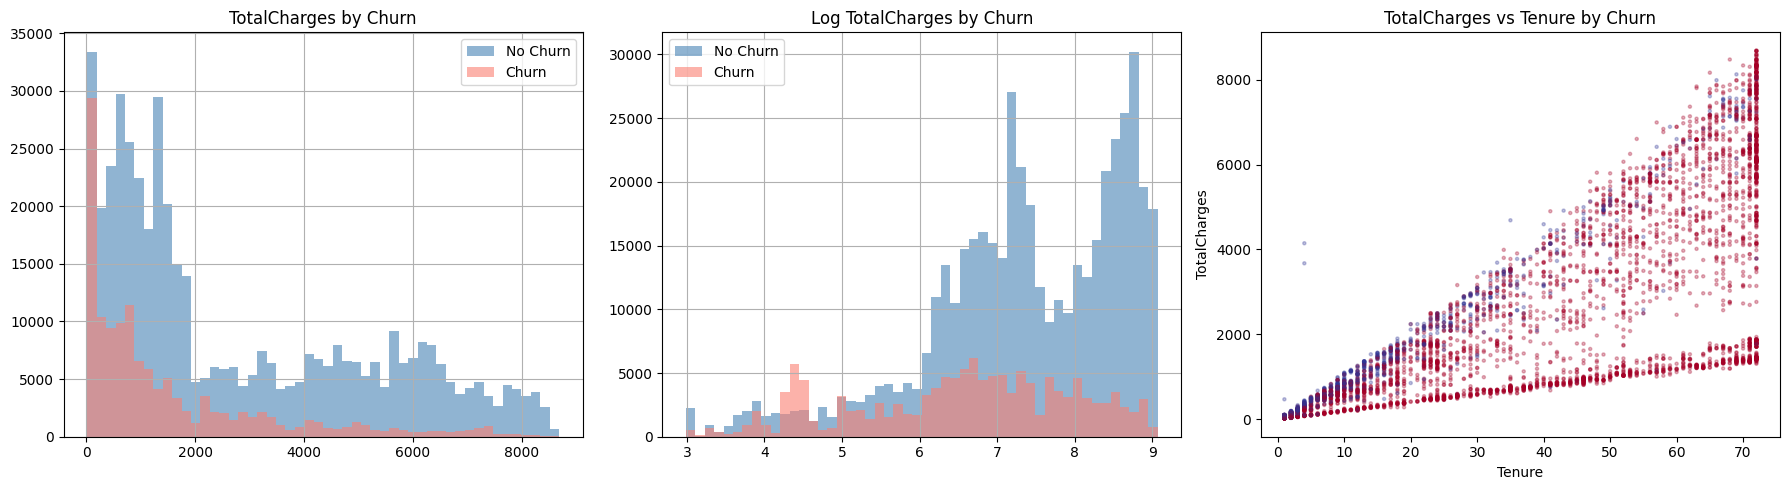

In [37]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. TotalCharges distribution by churn
train_data[train_data['Churn']==0]['TotalCharges'].hist(
    ax=axes[0], bins=50, alpha=0.6, label='No Churn', color='steelblue')
train_data[train_data['Churn']==1]['TotalCharges'].hist(
    ax=axes[0], bins=50, alpha=0.6, label='Churn', color='salmon')
axes[0].set_title('TotalCharges by Churn')
axes[0].legend()

# 2. Log TotalCharges
train_data['log_TotalCharges'] = np.log1p(train_data['TotalCharges'])
train_data[train_data['Churn']==0]['log_TotalCharges'].hist(
    ax=axes[1], bins=50, alpha=0.6, label='No Churn', color='steelblue')
train_data[train_data['Churn']==1]['log_TotalCharges'].hist(
    ax=axes[1], bins=50, alpha=0.6, label='Churn', color='salmon')
axes[1].set_title('Log TotalCharges by Churn')
axes[1].legend()

# 3. TotalCharges vs tenure colored by churn
sample = train_data.sample(5000, random_state=42)
axes[2].scatter(
    sample['tenure'], sample['TotalCharges'],
    c=sample['Churn'], cmap='RdYlBu', alpha=0.3, s=5
)
axes[2].set_title('TotalCharges vs Tenure by Churn')
axes[2].set_xlabel('Tenure')
axes[2].set_ylabel('TotalCharges')

plt.tight_layout()
plt.show()

# Drop log feature for now
train_data.drop(columns=['log_TotalCharges'], inplace=True)

In [38]:
# Expected TotalCharges = tenure × MonthlyCharges
# Actual vs Expected ratio
train_data['charge_ratio'] = train_data['TotalCharges'] / (
    train_data['tenure'] * train_data['MonthlyCharges'] + 1
)

# Also try log TotalCharges
train_data['log_TotalCharges'] = np.log1p(train_data['TotalCharges'])

# Check correlations
print(f"charge_ratio corr with Churn: {train_data['charge_ratio'].corr(train_data['Churn']):.4f}")
print(f"log_TotalCharges corr:        {train_data['log_TotalCharges'].corr(train_data['Churn']):.4f}")
print(f"TotalCharges corr:            {train_data['TotalCharges'].corr(train_data['Churn']):.4f}")

charge_ratio corr with Churn: 0.0283
log_TotalCharges corr:        -0.2482
TotalCharges corr:            -0.2184


Running MDS...


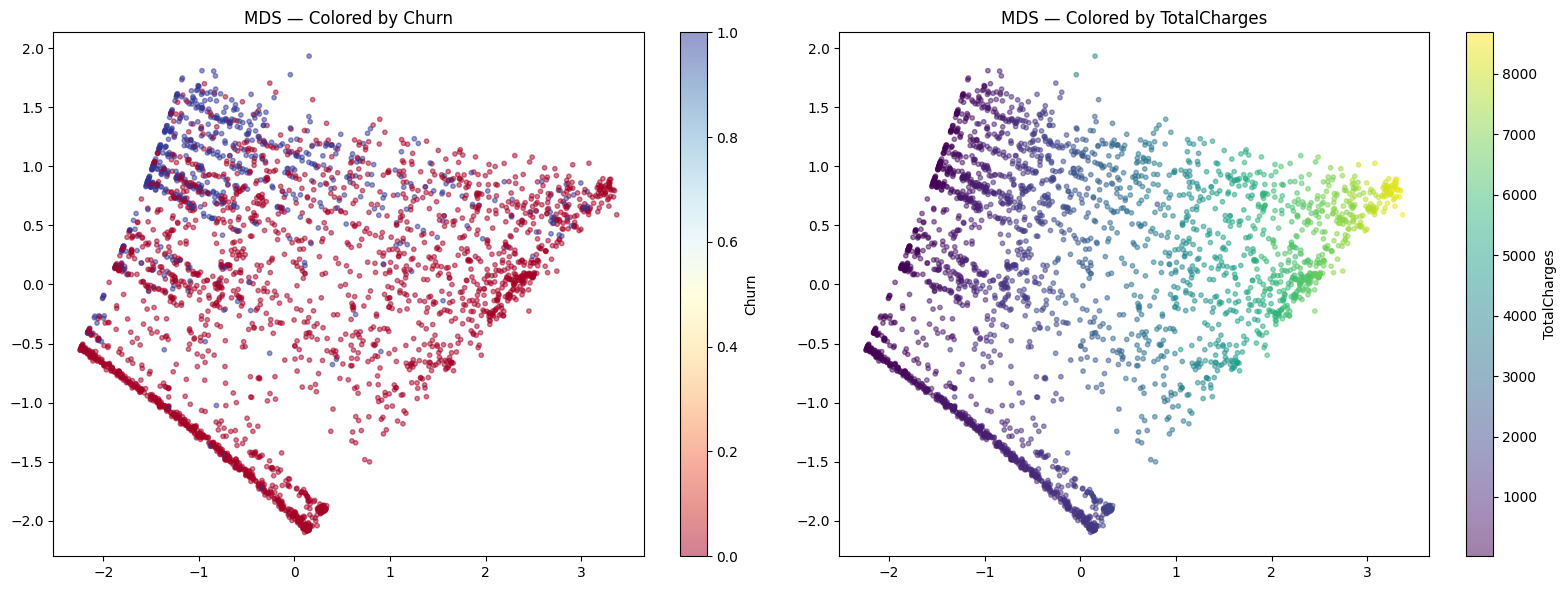

MDS stress: 5009.36


In [39]:
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Sample — MDS is very slow on large datasets
sample_idx = train_data.sample(3000, random_state=42).index
sample = train_data.loc[sample_idx]

# Scale numeric features
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_sample = scaler.fit_transform(sample[numeric_cols])

# MDS
print("Running MDS...")
mds = MDS(n_components=2, random_state=42, n_jobs=-1)
X_mds = mds.fit_transform(X_sample)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by churn
scatter1 = axes[0].scatter(
    X_mds[:, 0], X_mds[:, 1],
    c=sample['Churn'], cmap='RdYlBu',
    alpha=0.5, s=10
)
plt.colorbar(scatter1, ax=axes[0], label='Churn')
axes[0].set_title('MDS — Colored by Churn')

# Color by TotalCharges
scatter2 = axes[1].scatter(
    X_mds[:, 0], X_mds[:, 1],
    c=sample['TotalCharges'], cmap='viridis',
    alpha=0.5, s=10
)
plt.colorbar(scatter2, ax=axes[1], label='TotalCharges')
axes[1].set_title('MDS — Colored by TotalCharges')

plt.tight_layout()
plt.show()

print(f"MDS stress: {mds.stress_:.2f}")

In [40]:
# sqrt transform
train_data['sqrt_TotalCharges'] = np.sqrt(train_data['TotalCharges'])
print(f"sqrt_TotalCharges corr: {train_data['sqrt_TotalCharges'].corr(train_data['Churn']):.4f}")

sqrt_TotalCharges corr: -0.2386


In [42]:
# Add transformed features
train_data['log_TotalCharges'] = np.log1p(train_data['TotalCharges'])
train_data['sqrt_TotalCharges'] = np.sqrt(train_data['TotalCharges'])

# Also try log MonthlyCharges and log tenure
train_data['log_MonthlyCharges'] = np.log1p(train_data['MonthlyCharges'])
train_data['log_tenure'] = np.log1p(train_data['tenure'])

# Check all correlations
for col in ['log_TotalCharges', 'sqrt_TotalCharges', 
            'log_MonthlyCharges', 'log_tenure']:
    corr = train_data[col].corr(train_data['Churn'])
    print(f"{col}: {corr:.4f}")

log_TotalCharges: -0.2482
sqrt_TotalCharges: -0.2386
log_MonthlyCharges: 0.2894
log_tenure: -0.4379


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


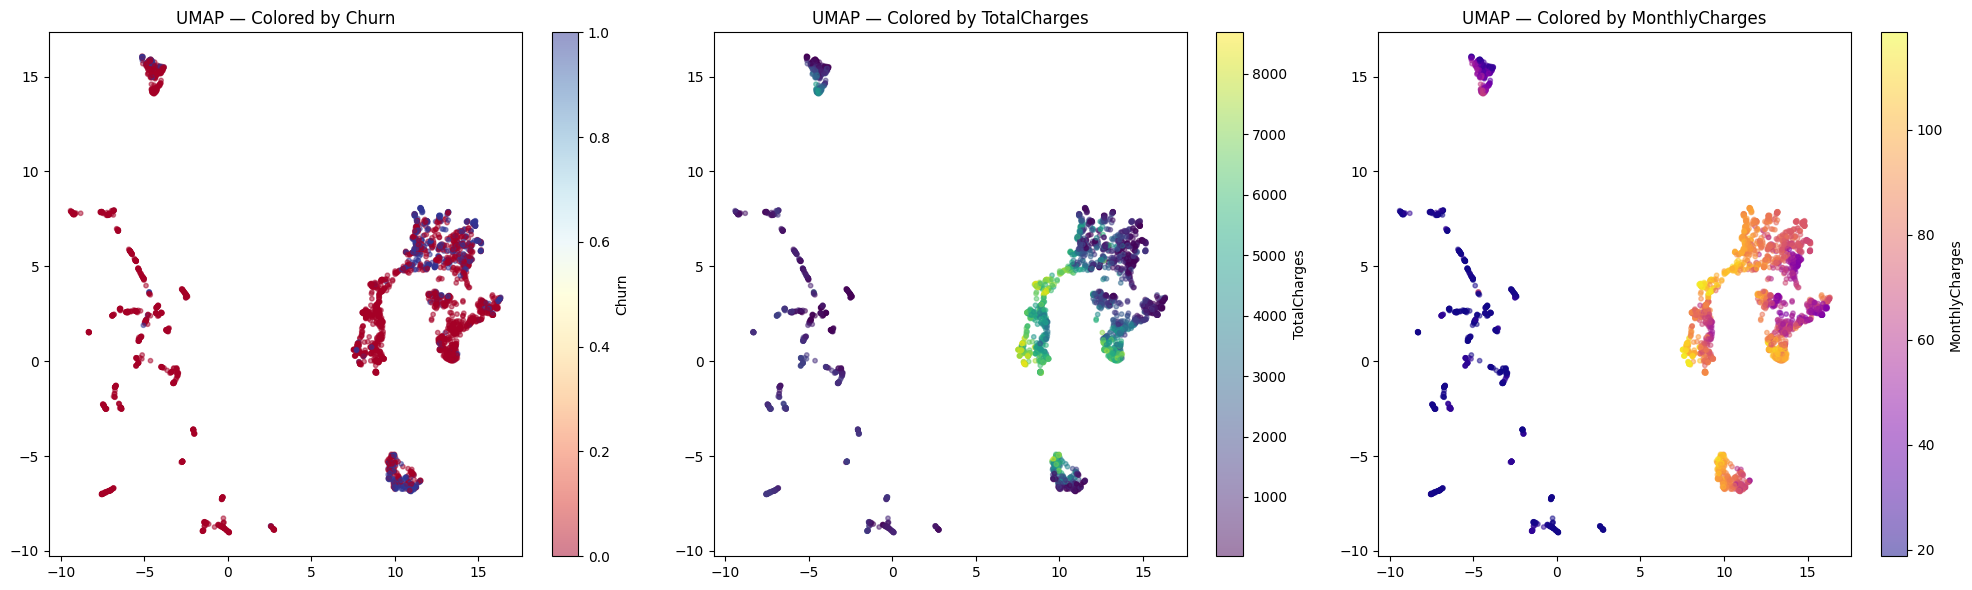

In [43]:
import umap

# Use all features this time not just numeric
scaler_umap = StandardScaler()
X_sample_all = scaler_umap.fit_transform(
    train_data.loc[sample_idx].drop(columns=['Churn', 'log_TotalCharges', 
                                              'sqrt_TotalCharges',
                                              'log_MonthlyCharges', 
                                              'log_tenure'])
)

reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_sample_all)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Color by Churn
scatter1 = axes[0].scatter(
    embedding[:, 0], embedding[:, 1],
    c=sample['Churn'], cmap='RdYlBu',
    alpha=0.5, s=10
)
plt.colorbar(scatter1, ax=axes[0], label='Churn')
axes[0].set_title('UMAP — Colored by Churn')

# Color by TotalCharges
scatter2 = axes[1].scatter(
    embedding[:, 0], embedding[:, 1],
    c=sample['TotalCharges'], cmap='viridis',
    alpha=0.5, s=10
)
plt.colorbar(scatter2, ax=axes[1], label='TotalCharges')
axes[1].set_title('UMAP — Colored by TotalCharges')

# Color by MonthlyCharges
scatter3 = axes[2].scatter(
    embedding[:, 0], embedding[:, 1],
    c=sample['MonthlyCharges'], cmap='plasma',
    alpha=0.5, s=10
)
plt.colorbar(scatter3, ax=axes[2], label='MonthlyCharges')
axes[2].set_title('UMAP — Colored by MonthlyCharges')

plt.tight_layout()
plt.show()

In [46]:
# Add UMAP coordinates to sample dataframe
sample_umap = train_data.loc[sample_idx].copy()
sample_umap['umap_x'] = embedding[:, 0]
sample_umap['umap_y'] = embedding[:, 1]

# Define regions based on what we saw in the plot
# Left scattered region (churners) — roughly x < 0
# Right curved blob (non-churners) — roughly x > 5
# Top isolated cluster — roughly y > 12
# Bottom small clusters — roughly y < -7

sample_umap['region'] = 'middle'
sample_umap.loc[sample_umap['umap_x'] < 0, 'region'] = 'left_churners'
sample_umap.loc[sample_umap['umap_x'] > 5, 'region'] = 'right_non_churners'
sample_umap.loc[sample_umap['umap_y'] > 12, 'region'] = 'top_isolated'
sample_umap.loc[sample_umap['umap_y'] < -7, 'region'] = 'bottom_clusters'

# Profile each region
print("=" * 60)
print("REGION PROFILES")
print("=" * 60)

# Load raw for readable labels
raw_sample = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
raw_sample = raw_sample.loc[sample_idx].reset_index(drop=True)
raw_sample['region'] = sample_umap['region'].values
raw_sample['Churn'] = raw_sample['Churn'].map({'Yes': 1, 'No': 0})

for region in ['left_churners', 'right_non_churners', 'top_isolated', 'bottom_clusters', 'middle']:
    subset = raw_sample[raw_sample['region'] == region]
    if len(subset) == 0:
        continue
    print(f"\n── {region.upper()} (n={len(subset)}) ──")
    print(f"Churn rate: {subset['Churn'].mean():.3f}")
    print(f"Contract:   {subset['Contract'].value_counts().to_dict()}")
    print(f"Internet:   {subset['InternetService'].value_counts().to_dict()}")
    print(f"Payment:    {subset['PaymentMethod'].value_counts().to_dict()}")
    print(f"Tenure:     mean={subset['tenure'].mean():.1f}, median={subset['tenure'].median():.1f}")
    print(f"Monthly$:   mean={subset['MonthlyCharges'].mean():.1f}")
    print(f"Total$:     mean={subset['TotalCharges'].mean():.1f}")

REGION PROFILES

── LEFT_CHURNERS (n=608) ──
Churn rate: 0.016
Contract:   {'Two year': 304, 'One year': 171, 'Month-to-month': 133}
Internet:   {'No': 605, 'Fiber optic': 2, 'DSL': 1}
Payment:    {'Mailed check': 250, 'Bank transfer (automatic)': 171, 'Credit card (automatic)': 166, 'Electronic check': 21}
Tenure:     mean=40.0, median=43.0
Monthly$:   mean=21.2
Total$:     mean=861.4

── RIGHT_NON_CHURNERS (n=2052) ──
Churn rate: 0.288
Contract:   {'Month-to-month': 1222, 'Two year': 481, 'One year': 349}
Internet:   {'Fiber optic': 1245, 'DSL': 807}
Payment:    {'Electronic check': 937, 'Credit card (automatic)': 464, 'Bank transfer (automatic)': 400, 'Mailed check': 251}
Tenure:     mean=35.2, median=31.0
Monthly$:   mean=81.8
Total$:     mean=3063.8

── TOP_ISOLATED (n=214) ──
Churn rate: 0.154
Contract:   {'Month-to-month': 115, 'Two year': 63, 'One year': 36}
Internet:   {'DSL': 214}
Payment:    {'Electronic check': 68, 'Credit card (automatic)': 54, 'Mailed check': 49, 'Bank tr

In [45]:
import pandas as pd
import numpy as np

# Load raw train for readable labels
raw = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
raw['Churn'] = raw['Churn'].map({'Yes': 1, 'No': 0})

# ── 1. Contract × InternetService × PaymentMethod ─────────────────────
print("=" * 60)
print("Contract × InternetService → Churn Rate")
print("=" * 60)
ct1 = raw.groupby(['Contract', 'InternetService'])['Churn'].agg(['mean', 'count'])
ct1.columns = ['Churn_Rate', 'Count']
ct1 = ct1.sort_values('Churn_Rate', ascending=False)
print(ct1.to_string())

# ── 2. Contract × PaymentMethod → Churn ───────────────────────────────
print("\n" + "=" * 60)
print("Contract × PaymentMethod → Churn Rate")
print("=" * 60)
ct2 = raw.groupby(['Contract', 'PaymentMethod'])['Churn'].agg(['mean', 'count'])
ct2.columns = ['Churn_Rate', 'Count']
ct2 = ct2.sort_values('Churn_Rate', ascending=False)
print(ct2.to_string())

# ── 3. InternetService × OnlineSecurity × Contract ────────────────────
print("\n" + "=" * 60)
print("InternetService × OnlineSecurity × Contract → Churn Rate")
print("=" * 60)
ct3 = raw.groupby(['InternetService', 'OnlineSecurity', 'Contract'])['Churn'].agg(['mean', 'count'])
ct3.columns = ['Churn_Rate', 'Count']
ct3 = ct3.sort_values('Churn_Rate', ascending=False)
print(ct3.head(15).to_string())

# ── 4. tenure_group × Contract × InternetService ──────────────────────
print("\n" + "=" * 60)
print("tenure_group × Contract × InternetService → Churn Rate")
print("=" * 60)
raw['tenure_group'] = pd.cut(
    raw['tenure'], bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr']
)
ct4 = raw.groupby(['tenure_group', 'Contract', 'InternetService'])['Churn'].agg(['mean', 'count'])
ct4.columns = ['Churn_Rate', 'Count']
ct4 = ct4.sort_values('Churn_Rate', ascending=False)
print(ct4.head(20).to_string())

# ── 5. PaymentMethod × PaperlessBilling × InternetService ─────────────
print("\n" + "=" * 60)
print("PaymentMethod × PaperlessBilling × InternetService → Churn Rate")
print("=" * 60)
ct5 = raw.groupby(['PaymentMethod', 'PaperlessBilling', 'InternetService'])['Churn'].agg(['mean', 'count'])
ct5.columns = ['Churn_Rate', 'Count']
ct5 = ct5.sort_values('Churn_Rate', ascending=False)
print(ct5.head(15).to_string())

Contract × InternetService → Churn Rate
                                Churn_Rate   Count
Contract       InternetService                    
Month-to-month Fiber optic        0.550093  193898
               DSL                0.225724   77732
One year       Fiber optic        0.132738   37992
Month-to-month No                 0.054969   27288
Two year       Fiber optic        0.035436   40496
One year       DSL                0.022020   38920
               No                 0.010916   31421
Two year       DSL                0.004035   64429
               No                 0.002085   82018

Contract × PaymentMethod → Churn Rate
                                          Churn_Rate   Count
Contract       PaymentMethod                                
Month-to-month Electronic check             0.556798  182172
               Bank transfer (automatic)    0.240299   31311
               Credit card (automatic)      0.233974   31559
               Mailed check                 0.173862   

/tmp/ipykernel_55/2430349189.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct4 = raw.groupby(['tenure_group', 'Contract', 'InternetService'])['Churn'].agg(['mean', 'count'])


### Training vs. Testing Distributions

Train size: 594194
Test size:  254655


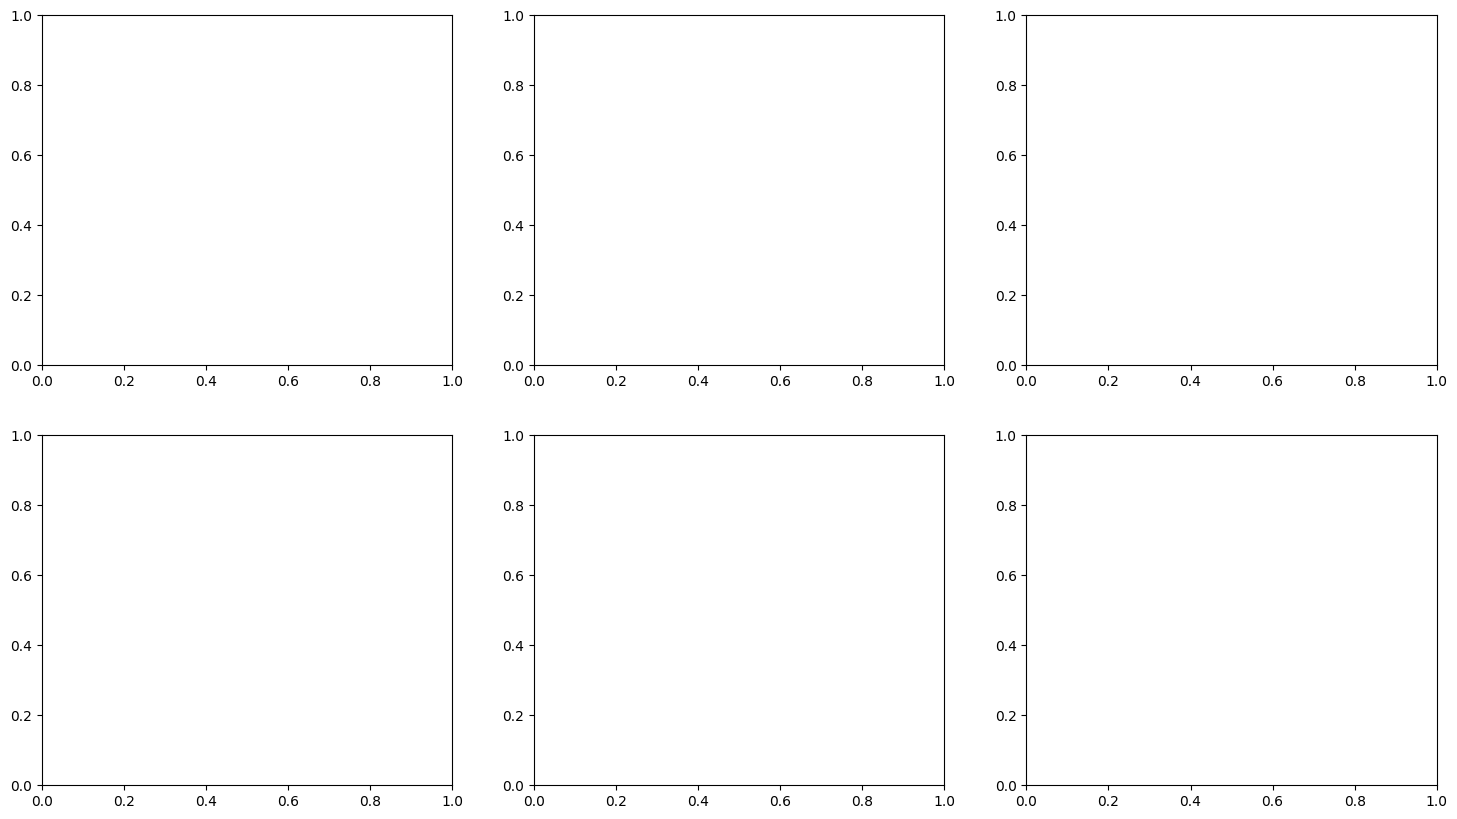

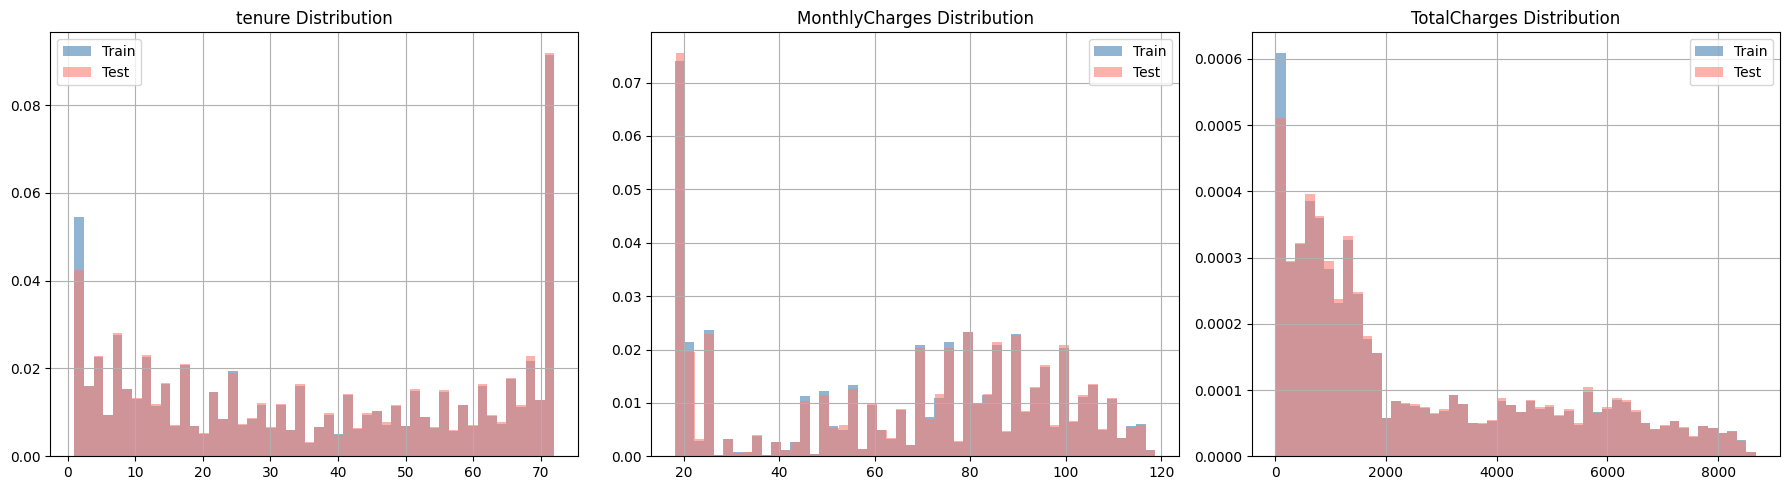

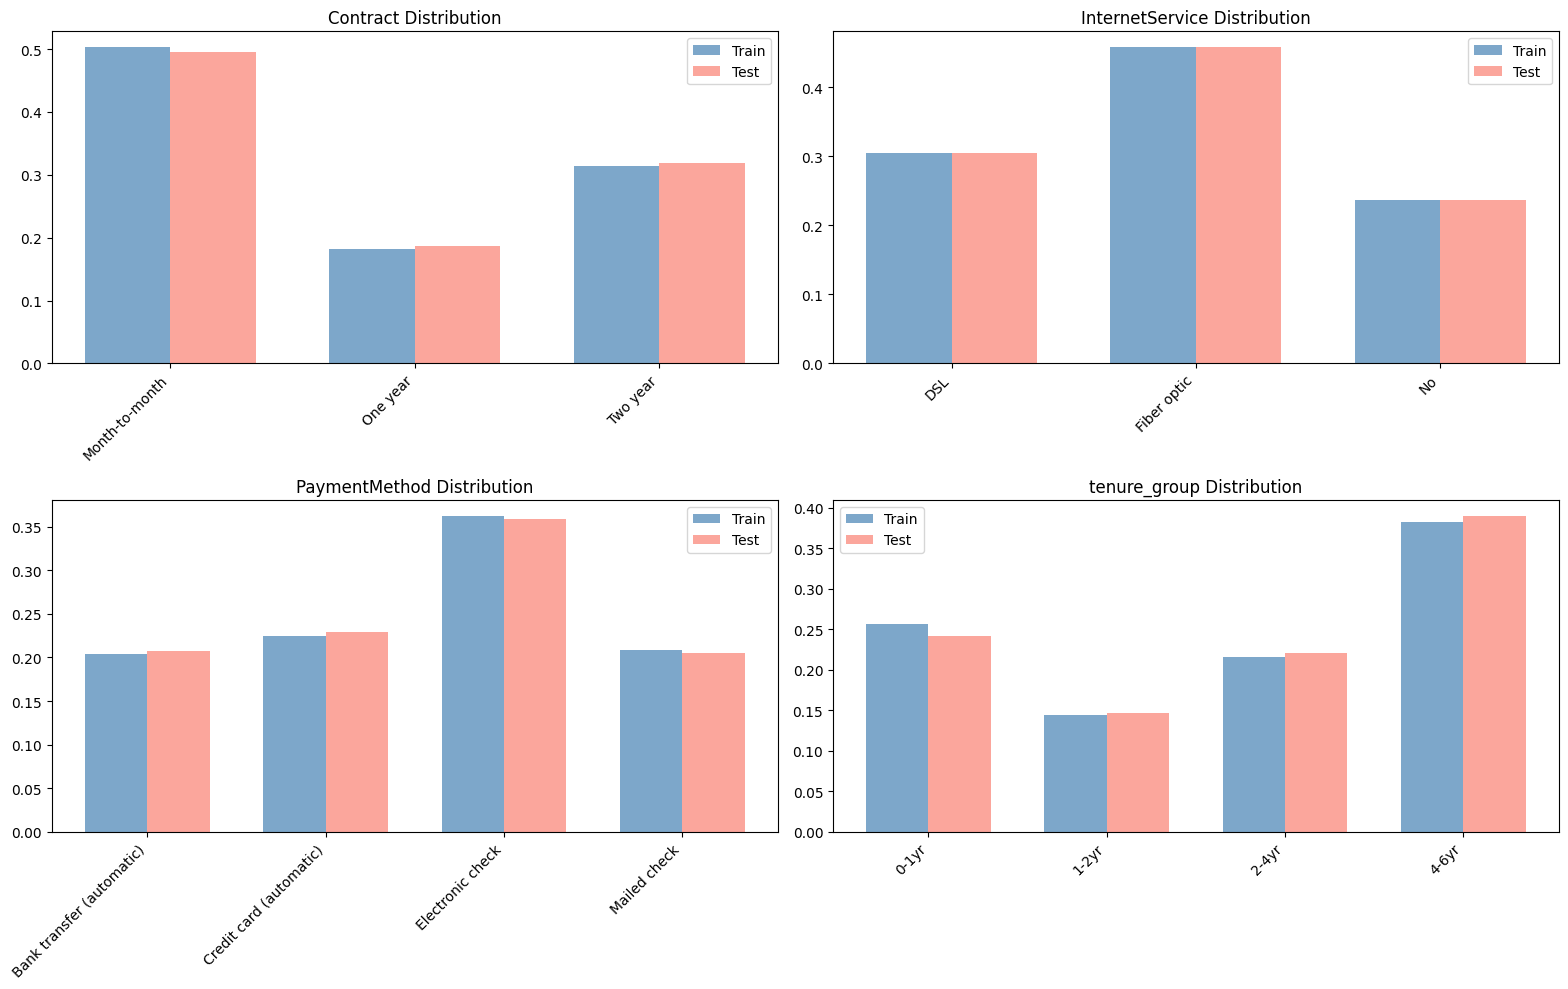


KS TEST — Train vs Test (p-value < 0.05 = different)
tenure              : KS=0.0171, p=0.0000 → DIFFERENT ⚠️
MonthlyCharges      : KS=0.0065, p=0.0000 → DIFFERENT ⚠️
TotalCharges        : KS=0.0177, p=0.0000 → DIFFERENT ⚠️

CATEGORICAL DISTRIBUTION DIFFERENCES

Contract:
  Month-to-month                     : train=0.503 test=0.496 ≈ -0.007
  Two year                           : train=0.315 test=0.318 ≈ +0.004
  One year                           : train=0.182 test=0.186 ≈ +0.004

InternetService:
  Fiber optic                        : train=0.458 test=0.458 ≈ -0.000
  DSL                                : train=0.305 test=0.305 ≈ +0.000
  No                                 : train=0.237 test=0.237 ≈ +0.000

PaymentMethod:
  Electronic check                   : train=0.362 test=0.358 ≈ -0.004
  Credit card (automatic)            : train=0.225 test=0.230 ≈ +0.005
  Mailed check                       : train=0.208 test=0.205 ≈ -0.003
  Bank transfer (automatic)          : train=0.204 te

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Load raw test
test_raw = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
train_raw = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')

print(f"Train size: {len(train_raw)}")
print(f"Test size:  {len(test_raw)}")

# ── 1. Numeric feature distributions ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), ['tenure', 'MonthlyCharges', 'TotalCharges',
                                      'SeniorCitizen', 'tenure', 'MonthlyCharges']):
    pass

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    train_raw[col] = pd.to_numeric(train_raw[col], errors='coerce')
    test_raw[col] = pd.to_numeric(test_raw[col], errors='coerce')
    
    train_raw[col].hist(ax=ax, bins=50, alpha=0.6, 
                        label='Train', color='steelblue', density=True)
    test_raw[col].hist(ax=ax, bins=50, alpha=0.6, 
                       label='Test', color='salmon', density=True)
    ax.set_title(f'{col} Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

# ── 2. Categorical feature distributions ──────────────────────────────
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 
            'tenure_group_raw']

# Add tenure group to raw
train_raw['tenure_group'] = pd.cut(
    train_raw['tenure'], bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr']
)
test_raw['tenure_group'] = pd.cut(
    test_raw['tenure'], bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr']
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, ['Contract', 'InternetService', 
                           'PaymentMethod', 'tenure_group']):
    train_pct = train_raw[col].value_counts(normalize=True).sort_index()
    test_pct = test_raw[col].value_counts(normalize=True).sort_index()
    
    x = np.arange(len(train_pct))
    width = 0.35
    
    ax.bar(x - width/2, train_pct.values, width, 
           label='Train', color='steelblue', alpha=0.7)
    ax.bar(x + width/2, [test_pct.get(k, 0) for k in train_pct.index], 
           width, label='Test', color='salmon', alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(train_pct.index, rotation=45, ha='right')
    ax.set_title(f'{col} Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

# ── 3. Statistical comparison ──────────────────────────────────────────
from scipy import stats

print("\n" + "=" * 50)
print("KS TEST — Train vs Test (p-value < 0.05 = different)")
print("=" * 50)

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    train_col = pd.to_numeric(train_raw[col], errors='coerce').dropna()
    test_col = pd.to_numeric(test_raw[col], errors='coerce').dropna()
    ks_stat, p_value = stats.ks_2samp(train_col, test_col)
    different = "DIFFERENT ⚠️" if p_value < 0.05 else "Similar ✅"
    print(f"{col:20s}: KS={ks_stat:.4f}, p={p_value:.4f} → {different}")

# Categorical distribution differences
print("\n" + "=" * 50)
print("CATEGORICAL DISTRIBUTION DIFFERENCES")
print("=" * 50)

for col in ['Contract', 'InternetService', 'PaymentMethod']:
    train_pct = train_raw[col].value_counts(normalize=True)
    test_pct = test_raw[col].value_counts(normalize=True)
    print(f"\n{col}:")
    for cat in train_pct.index:
        diff = test_pct.get(cat, 0) - train_pct.get(cat, 0)
        arrow = "↑" if diff > 0.01 else "↓" if diff < -0.01 else "≈"
        print(f"  {cat:35s}: train={train_pct[cat]:.3f} test={test_pct.get(cat,0):.3f} {arrow} {diff:+.3f}")

In [48]:
# Give more weight to tenure=72 customers
sample_weights = np.ones(len(X_train))
sample_weights[X_train['tenure'] == 72] = 1.5

In [49]:
# Check exact tenure distribution difference
print("Train tenure distribution:")
print(train_raw['tenure'].value_counts(normalize=True).head(10))
print("\nTest tenure distribution:")
print(test_raw['tenure'].value_counts(normalize=True).head(10))

Train tenure distribution:
tenure
72    0.094937
1     0.049112
71    0.034943
2     0.028216
3     0.022683
9     0.021895
7     0.021104
10    0.018502
4     0.018363
70    0.018348
Name: proportion, dtype: float64

Test tenure distribution:
tenure
72    0.094893
71    0.035695
1     0.032436
2     0.027893
3     0.022615
7     0.021861
9     0.021727
10    0.018837
4     0.018500
70    0.018272
Name: proportion, dtype: float64


# Preprocessing

In [26]:
# encode the target
train_data['Churn'] = train_data['Churn'].map({'Yes': 1, 'No': 0})

In [27]:
# id column is not required, gender had equal balance hence not an indicator for churn
train_data.drop(columns=['id', 'gender'], inplace=True)

In [28]:
# encoding the features that had only Yes, No as entries
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    train_data[col] = train_data[col].map({'Yes': 1, 'No': 0})

One Hot Encoding:

In [29]:
# one-hot encoding on the other columns
three_cat_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

train_data = pd.get_dummies(train_data, columns=three_cat_cols, drop_first=True)

multi_cols = ['InternetService', 'Contract', 'PaymentMethod']

train_data = pd.get_dummies(train_data, columns=multi_cols, drop_first=True)

In [31]:
print(train_data.dtypes)
print(train_data.shape)

SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No internet service             bool
StreamingTV_Yes     

In [32]:
train_data.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,29,1,1,60.10,1653.85,0,False,...,False,False,False,False,False,True,False,False,False,True
1,0,1,1,58,1,0,69.50,3778.20,0,False,...,True,False,False,False,False,False,True,True,False,False
2,0,1,0,58,1,1,100.40,5841.35,0,False,...,True,False,True,True,False,False,False,False,True,False
3,0,0,0,1,1,1,69.70,70.70,1,False,...,False,False,False,True,False,False,False,False,True,False
4,0,0,0,1,1,1,70.45,70.45,1,False,...,False,False,False,True,False,False,False,False,True,False


In [30]:
# fixing up column names
train_data.columns = train_data.columns.str.replace(" ", "_")

In [31]:
print(train_data.columns.tolist())

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No_phone_service', 'MultipleLines_Yes', 'OnlineSecurity_No_internet_service', 'OnlineSecurity_Yes', 'OnlineBackup_No_internet_service', 'OnlineBackup_Yes', 'DeviceProtection_No_internet_service', 'DeviceProtection_Yes', 'TechSupport_No_internet_service', 'TechSupport_Yes', 'StreamingTV_No_internet_service', 'StreamingTV_Yes', 'StreamingMovies_No_internet_service', 'StreamingMovies_Yes', 'InternetService_Fiber_optic', 'InternetService_No', 'Contract_One_year', 'Contract_Two_year', 'PaymentMethod_Credit_card_(automatic)', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check']


# Feature Engineering

In [9]:
# 1. Number of add-on services the customer has
addon_cols = [
    'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
]
train_data['num_addons'] = train_data[addon_cols].sum(axis=1)

# 2. Tenure group — bin tenure into stages
train_data['tenure_group'] = pd.cut(
    train_data['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3]  # 0=new, 1=developing, 2=established, 3=loyal
).astype(int)

In [37]:
print(train_data['num_addons'].value_counts().sort_index())
print(train_data['tenure_group'].value_counts().sort_index())

num_addons
0    203853
1     75363
2     81929
3     79585
4     64692
5     49277
6     39495
Name: count, dtype: int64
tenure_group
0    152646
1     86024
2    127988
3    227536
Name: count, dtype: int64


Continuing Feature Engineering After 2 Submissions: XGBoost, Ensemble

{did not help the model, reduced score, revert back to original features}

In [40]:
'''
print([c for c in train_data.columns if 'Contract' in c])
print([c for c in train_data.columns if 'Payment' in c])
'''

['Contract_One_year', 'Contract_Two_year']
['PaymentMethod_Credit_card_(automatic)', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check']


In [41]:
'''
# 1. Cost per service
train_data['charge_per_addon'] = train_data['MonthlyCharges'] / (train_data['num_addons'] + 1)

# 2. High risk flag
train_data['is_high_risk'] = (
    (train_data['Contract_Two_year'] == 0) &
    (train_data['Contract_One_year'] == 0) &
    (train_data['PaymentMethod_Electronic_check'] == 1) &
    (train_data['InternetService_Fiber_optic'] == 1) &
    (train_data['tenure'] <= 12)
).astype(int)

# 3. Month to month + electronic check interaction
train_data['month_to_month_echeck'] = (
    (train_data['Contract_Two_year'] == 0) &
    (train_data['Contract_One_year'] == 0) &
    (train_data['PaymentMethod_Electronic_check'] == 1)
).astype(int)

# 4. Tenure × MonthlyCharges interaction
train_data['tenure_x_charges'] = train_data['tenure'] * train_data['MonthlyCharges']
'''

In [42]:
'''
# Same features for test_data
test_data['charge_per_addon'] = test_data['MonthlyCharges'] / (test_data['num_addons'] + 1)

test_data['is_high_risk'] = (
    (test_data['Contract_Two_year'] == 0) &
    (test_data['Contract_One_year'] == 0) &
    (test_data['PaymentMethod_Electronic_check'] == 1) &
    (test_data['InternetService_Fiber_optic'] == 1) &
    (test_data['tenure'] <= 12)
).astype(int)

test_data['month_to_month_echeck'] = (
    (test_data['Contract_Two_year'] == 0) &
    (test_data['Contract_One_year'] == 0) &
    (test_data['PaymentMethod_Electronic_check'] == 1)
).astype(int)

test_data['tenure_x_charges'] = test_data['tenure'] * test_data['MonthlyCharges']
'''

In [12]:
print(train_data.shape)
print(test_data.shape)
print(train_data.columns.tolist())

(594194, 32)
(254655, 20)
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No_phone_service', 'MultipleLines_Yes', 'OnlineSecurity_No_internet_service', 'OnlineSecurity_Yes', 'OnlineBackup_No_internet_service', 'OnlineBackup_Yes', 'DeviceProtection_No_internet_service', 'DeviceProtection_Yes', 'TechSupport_No_internet_service', 'TechSupport_Yes', 'StreamingTV_No_internet_service', 'StreamingTV_Yes', 'StreamingMovies_No_internet_service', 'StreamingMovies_Yes', 'InternetService_Fiber_optic', 'InternetService_No', 'Contract_One_year', 'Contract_Two_year', 'PaymentMethod_Credit_card_(automatic)', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check', 'num_addons', 'tenure_group']


# Modeling

In [10]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = train_data.drop(columns=['Churn'])
y = train_data['Churn']

# Stratify ensures the 77/23 split is preserved in both train and val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_val.shape)
print(y_train.value_counts(normalize=True))

(475355, 31) (118839, 31)
Churn
0    0.774791
1    0.225209
Name: proportion, dtype: float64


## Using Logistic Regression as the baseline

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = ['MonthlyCharges', 'TotalCharges', 'tenure']

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_val_scaled)
lr_probs = lr.predict_proba(X_val_scaled)[:, 1]

print(f"AUC: {roc_auc_score(y_val, lr_probs):.4f}")
print(classification_report(y_val, lr_preds))

AUC: 0.9084
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     92076
           1       0.68      0.66      0.67     26763

    accuracy                           0.85    118839
   macro avg       0.79      0.78      0.79    118839
weighted avg       0.85      0.85      0.85    118839



Observations:

Logistic Regression —> Baseline Results

| Metric | Score |
|---|---|
| AUC | 0.9084 |
| Accuracy | 0.85 |
| Churn Precision | 0.68 |
| Churn Recall | 0.66 |
| Churn F1 | 0.67 |

**Key takeaway:** Strong baseline with AUC of 0.91, but misses **34% of actual churners** (recall 0.66). Predicting non-churners is much easier for the model than identifying churners, which is expected given the class imbalance. Goal for tree-based models is to improve churn recall and F1 without sacrificing AUC.

\
Edit:
- Ran again with additional features
- Recall dropped
- Reverted back to original features

## XGBoost

In [41]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,        # handles class imbalance (roughly 77/23 ≈ 3)
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50   # stops if no improvement for 50 rounds
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50                 # prints progress every 50 trees
)

xgb_preds = model.predict(X_val)
xgb_probs = model.predict_proba(X_val)[:, 1]

print(f"AUC: {roc_auc_score(y_val, xgb_probs):.4f}")
print(classification_report(y_val, xgb_preds))

[0]	validation_0-auc:0.89817
[50]	validation_0-auc:0.91258
[100]	validation_0-auc:0.91396
[150]	validation_0-auc:0.91487
[200]	validation_0-auc:0.91549
[250]	validation_0-auc:0.91586
[300]	validation_0-auc:0.91607
[350]	validation_0-auc:0.91627
[400]	validation_0-auc:0.91639
[450]	validation_0-auc:0.91646
[499]	validation_0-auc:0.91651
AUC: 0.9165
              precision    recall  f1-score   support

           0       0.95      0.82      0.88     92076
           1       0.58      0.86      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.77      0.84      0.79    118839
weighted avg       0.87      0.83      0.84    118839



Observations:

XGBoost —> Results

| Metric | Logistic Regression | XGBoost | Change |
|---|---|---|---|
| AUC | 0.9084 | 0.9165 | +0.008 |
| Churn Precision | 0.68 | 0.58 | -0.10 |
| Churn Recall | 0.66 | 0.86 | +0.20 |
| Churn F1 | 0.67 | 0.69 | +0.02 |

- AUC improved slightly, XGBoost ranks churners better overall
- `scale_pos_weight=3` aggressively addressed class imbalance — churn recall jumped from 0.66 → **0.86** (catching 20% more actual churners)
- Precision dropped as a tradeoff — model is more aggressive about predicting churn, leading to more false positives
- Early stopping didn't trigger (ran all 500 trees, AUC still climbing at [499]) — model may benefit from more trees
- **Next steps:** check feature importances, then tune `n_estimators` and other hyperparameters

                                 feature  importance
27        PaymentMethod_Electronic_check    0.307736
22           InternetService_Fiber_optic    0.197817
25                     Contract_Two_year    0.188640
30                          tenure_group    0.061538
24                     Contract_One_year    0.061072
10    OnlineSecurity_No_internet_service    0.039568
12      OnlineBackup_No_internet_service    0.037539
3                                 tenure    0.016249
19                       StreamingTV_Yes    0.008984
5                       PaperlessBilling    0.008590
21                   StreamingMovies_Yes    0.008492
11                    OnlineSecurity_Yes    0.007387
0                          SeniorCitizen    0.006894
14  DeviceProtection_No_internet_service    0.006617
4                           PhoneService    0.006464


<Figure size 1000x800 with 0 Axes>

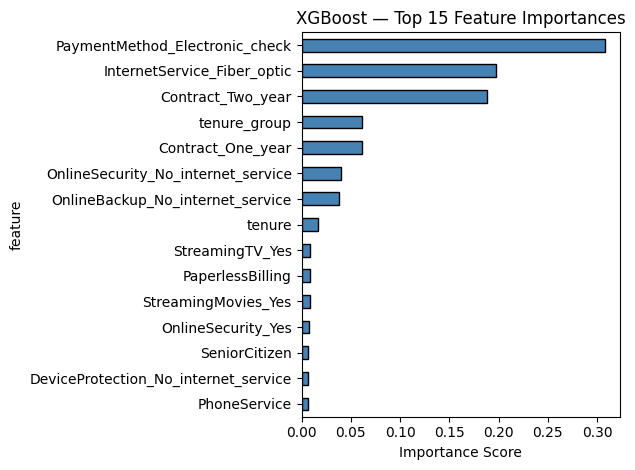

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(15))

# Plot
plt.figure(figsize=(10, 8))
importance.head(15).plot(
    kind='barh', x='feature', y='importance',
    color='steelblue', edgecolor='black', legend=False
)
plt.title('XGBoost — Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Observations:

XGBoost —> Feature Importance Observations

\
Top 3 Dominant Features
- `PaymentMethod_Electronic_check` (0.3077) — single most important feature by a large margin, consistent with ~49% churn rate in EDA
- `InternetService_Fiber_optic` (0.1978) — second strongest, consistent with ~42% churn rate in EDA
- `Contract_Two_year` (0.1886) — used heavily as a "won't churn" signal

<br>
> These 3 features alone account for **~69% of total importance**

\
Notable Observations
- `tenure_group` (engineered) performed comparably to `Contract_One_year` — binning tenure was more useful to the model than the raw `tenure` value (which scored very low at 0.015)
- `OnlineSecurity_No_internet_service` and `OnlineBackup_No_internet_service` appearing in top 15 validates keeping "No internet service" as a separate category rather than collapsing it into "No"
- `MonthlyCharges` and `TotalCharges` absent from top 15 despite strong EDA correlation — likely because their signal is already captured by `InternetService_Fiber_optic` and `Contract` (fiber/month-to-month customers naturally pay more)
- `num_addons` didn't appear — its signal is likely split across the individual add-on columns

\
Next Steps
- Considering dropping raw `tenure` since `tenure_group` covers it
- Moving to hyperparameter tuning to squeeze more performance out of the model

In [43]:
# pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [44]:
'''
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': 3,
        'eval_metric': 'auc',
        'random_state': 42,
        'early_stopping_rounds': 50
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)


# Run the study
study = optuna.create_study(direction='maximize')  # we want to maximize AUC
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Results
print(f"Best AUC: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")
'''

[I 2026-03-13 22:18:41,211] A new study created in memory with name: no-name-ea30d417-87a3-4b57-989a-0d7e267b6e4d


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-13 22:18:58,516] Trial 0 finished with value: 0.9124604961588512 and parameters: {'n_estimators': 410, 'max_depth': 3, 'learning_rate': 0.015162818064838495, 'subsample': 0.8129622609444318, 'colsample_bytree': 0.695791596143071, 'min_child_weight': 5, 'gamma': 1.7785408733121533}. Best is trial 0 with value: 0.9124604961588512.
[I 2026-03-13 22:19:47,243] Trial 1 finished with value: 0.9164303007418803 and parameters: {'n_estimators': 946, 'max_depth': 6, 'learning_rate': 0.02048577252873327, 'subsample': 0.8131955833381908, 'colsample_bytree': 0.820613354496932, 'min_child_weight': 10, 'gamma': 1.913842874713438}. Best is trial 1 with value: 0.9164303007418803.
[I 2026-03-13 22:19:57,950] Trial 2 finished with value: 0.9158840390266365 and parameters: {'n_estimators': 649, 'max_depth': 8, 'learning_rate': 0.14878184050997917, 'subsample': 0.6427028839139611, 'colsample_bytree': 0.6003308139503637, 'min_child_weight': 1, 'gamma': 2.8399791066534776}. Best is trial 1 with va

In [47]:
final_model = XGBClassifier(                  # adding best params manually, to avoid running Optuna
    n_estimators=395,
    max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7,
    gamma=1.308840064055984,
    scale_pos_weight=3,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50,
    device='cuda'
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

final_preds = final_model.predict(X_val)
final_probs = final_model.predict_proba(X_val)[:, 1]

print(f"AUC: {roc_auc_score(y_val, final_probs):.4f}")
print(classification_report(y_val, final_preds))

[0]	validation_0-auc:0.88735
[50]	validation_0-auc:0.91425
[100]	validation_0-auc:0.91535
[150]	validation_0-auc:0.91582
[200]	validation_0-auc:0.91602
[250]	validation_0-auc:0.91617
[300]	validation_0-auc:0.91625
[350]	validation_0-auc:0.91631
[394]	validation_0-auc:0.91631
AUC: 0.9163


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [06:20:24] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


              precision    recall  f1-score   support

           0       0.95      0.82      0.88     92076
           1       0.58      0.86      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.76      0.84      0.79    118839
weighted avg       0.87      0.83      0.84    118839



Observations:

Hyperparameter Tuning -> Optuna

| Metric | Manual XGBoost | Tuned XGBoost | Change |
|---|---|---|---|
| AUC | 0.9165 | 0.9167 | ~0.0002 |
| Churn Recall | 0.86 | 0.86 | no change |
| Churn F1 | 0.69 | 0.69 | no change |

\
Key Findings:
- 30 Optuna trials produced negligible improvement over manual params (+0.0002 AUC)
- Optuna preferred a shallower (`max_depth=4`), faster-learning (`lr=0.187`) model vs our manual deeper, slower one — but end result is nearly identical
- Early stopping triggered at tree 394 (out of 395) — model fully converged
- Model has effectively hit its ceiling with the current feature set

\
Best Params Found:
```
n_estimators:      395
max_depth:         4
learning_rate:     0.187
subsample:         0.867
colsample_bytree:  0.907
min_child_weight:  7
gamma:             1.309
scale_pos_weight:  3
```
\
Conclusion:
Further gains would require better feature engineering or additional data rather than more tuning. Proceeding to submission with these params.

In [23]:
# Running another round of Optuna with 100 trials on GPU

import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),      # L1 regularization
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),    # L2 regularization
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 2, 5),  # tunable!
        'eval_metric': 'auc',
        'random_state': 42,
        'early_stopping_rounds': 50,
        'device': 'cuda'
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

# Run 100 trials
optuna.logging.set_verbosity(optuna.logging.WARNING)  # cleaner output
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nBest AUC: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]


Best AUC: 0.9166
Best Params: {'n_estimators': 820, 'max_depth': 6, 'learning_rate': 0.07455426506355615, 'subsample': 0.7537209773257993, 'colsample_bytree': 0.9617037370661754, 'min_child_weight': 15, 'gamma': 3.1547607476840307, 'reg_alpha': 1.5719129296439283, 'reg_lambda': 1.6895462067307643, 'scale_pos_weight': 2.164595139771972}


In [24]:
print(train_data.columns.tolist())
print(train_data.shape)

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No_phone_service', 'MultipleLines_Yes', 'OnlineSecurity_No_internet_service', 'OnlineSecurity_Yes', 'OnlineBackup_No_internet_service', 'OnlineBackup_Yes', 'DeviceProtection_No_internet_service', 'DeviceProtection_Yes', 'TechSupport_No_internet_service', 'TechSupport_Yes', 'StreamingTV_No_internet_service', 'StreamingTV_Yes', 'StreamingMovies_No_internet_service', 'StreamingMovies_Yes', 'InternetService_Fiber_optic', 'InternetService_No', 'Contract_One_year', 'Contract_Two_year', 'PaymentMethod_Credit_card_(automatic)', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check', 'num_addons', 'tenure_group', 'hazard_score']
(594194, 33)


In [25]:
print(X_train.columns.tolist())
print(X_train.shape)

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No_phone_service', 'MultipleLines_Yes', 'OnlineSecurity_No_internet_service', 'OnlineSecurity_Yes', 'OnlineBackup_No_internet_service', 'OnlineBackup_Yes', 'DeviceProtection_No_internet_service', 'DeviceProtection_Yes', 'TechSupport_No_internet_service', 'TechSupport_Yes', 'StreamingTV_No_internet_service', 'StreamingTV_Yes', 'StreamingMovies_No_internet_service', 'StreamingMovies_Yes', 'InternetService_Fiber_optic', 'InternetService_No', 'Contract_One_year', 'Contract_Two_year', 'PaymentMethod_Credit_card_(automatic)', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check', 'num_addons', 'tenure_group', 'hazard_score']
(475355, 32)


In [26]:
# Clean up
# train_data.drop(columns=['hazard_score'], inplace=True)

X = train_data.drop(columns=['Churn'])
y = train_data['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [14]:
# Train with new best params
best_params = {
    'n_estimators': 820,
    'max_depth': 6,
    'learning_rate': 0.07455426506355615,
    'subsample': 0.7537209773257993,
    'colsample_bytree': 0.9617037370661754,
    'min_child_weight': 15,
    'gamma': 3.1547607476840307,
    'reg_alpha': 1.5719129296439283,
    'reg_lambda': 1.6895462067307643,
    'scale_pos_weight': 2.164595139771972,
    'eval_metric': 'auc',
    'random_state': 42,
    'early_stopping_rounds': 50,
    'device': 'cuda'
}

In [17]:
final_model = XGBClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_probs = final_model.predict_proba(X_val)[:, 1]
print(f"New Optuna AUC: {roc_auc_score(y_val, xgb_probs):.4f}")
print(f"Old Optuna AUC: 0.9167")

[0]	validation_0-auc:0.90456
[50]	validation_0-auc:0.91335
[100]	validation_0-auc:0.91489
[150]	validation_0-auc:0.91576
[200]	validation_0-auc:0.91610
[250]	validation_0-auc:0.91625
[300]	validation_0-auc:0.91635
[350]	validation_0-auc:0.91643
[400]	validation_0-auc:0.91646
[450]	validation_0-auc:0.91650
[500]	validation_0-auc:0.91652
[541]	validation_0-auc:0.91652
New Optuna AUC: 0.9165
Old Optuna AUC: 0.9167


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [14:01:31] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


worse result. retrain on old params and try pseudo-labelling

In [14]:
# Retrain with original best params
best_params = {
    'n_estimators': 395,
    'max_depth': 4,
    'learning_rate': 0.18686108212758018,
    'subsample': 0.8667476017573688,
    'colsample_bytree': 0.9066658356163867,
    'min_child_weight': 7,
    'gamma': 1.308840064055984,
    'scale_pos_weight': 3,
    'eval_metric': 'auc',
    'random_state': 42,
    'early_stopping_rounds': 50,
    'device': 'cuda'
}

final_model = XGBClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_probs = final_model.predict_proba(X_val)[:, 1]
print(f"AUC: {roc_auc_score(y_val, xgb_probs):.4f}")

AUC: 0.9165


In [19]:
# Training with Max Depth = 1 since all features are independent

xgb_depth1 = XGBClassifier(
    n_estimators=10000,      # more trees since each is shallow
    max_depth=1,            # ← the key insight
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50,
    device='cuda'
)

xgb_depth1.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

depth1_probs = xgb_depth1.predict_proba(X_val)[:, 1]
print(f"Depth=1 AUC: {roc_auc_score(y_val, depth1_probs):.4f}")
print(f"Depth=4 AUC: 0.9165")

[0]	validation_0-auc:0.77478
[100]	validation_0-auc:0.90221
[200]	validation_0-auc:0.90864
[300]	validation_0-auc:0.91071
[400]	validation_0-auc:0.91155
[500]	validation_0-auc:0.91197
[600]	validation_0-auc:0.91222
[700]	validation_0-auc:0.91240
[800]	validation_0-auc:0.91255
[900]	validation_0-auc:0.91269
[1000]	validation_0-auc:0.91280
[1100]	validation_0-auc:0.91291
[1200]	validation_0-auc:0.91299
[1300]	validation_0-auc:0.91307
[1400]	validation_0-auc:0.91313
[1500]	validation_0-auc:0.91320
[1600]	validation_0-auc:0.91325
[1700]	validation_0-auc:0.91330
[1800]	validation_0-auc:0.91334
[1900]	validation_0-auc:0.91339
[2000]	validation_0-auc:0.91343
[2100]	validation_0-auc:0.91346
[2200]	validation_0-auc:0.91350
[2300]	validation_0-auc:0.91353
[2400]	validation_0-auc:0.91357
[2500]	validation_0-auc:0.91361
[2600]	validation_0-auc:0.91363
[2700]	validation_0-auc:0.91366
[2800]	validation_0-auc:0.91369
[2900]	validation_0-auc:0.91372
[3000]	validation_0-auc:0.91375
[3100]	validation_0-

In [20]:
xgb_depth1_v2 = XGBClassifier(
    n_estimators=20000,
    max_depth=1,
    learning_rate=0.01,      # much lower
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=200,  # more patient
    device='cuda'
)

xgb_depth1_v2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

depth1_probs = xgb_depth1_v2.predict_proba(X_val)[:, 1]
print(f"Depth=1 AUC: {roc_auc_score(y_val, depth1_probs):.4f}")
print(f"Depth=4 AUC: 0.9165")

[0]	validation_0-auc:0.77478
[100]	validation_0-auc:0.88128
[200]	validation_0-auc:0.88597
[300]	validation_0-auc:0.89637
[400]	validation_0-auc:0.89999
[500]	validation_0-auc:0.90213
[600]	validation_0-auc:0.90391
[700]	validation_0-auc:0.90538
[800]	validation_0-auc:0.90660
[900]	validation_0-auc:0.90773
[1000]	validation_0-auc:0.90849
[1100]	validation_0-auc:0.90914
[1200]	validation_0-auc:0.90965
[1300]	validation_0-auc:0.91008
[1400]	validation_0-auc:0.91040
[1500]	validation_0-auc:0.91067
[1600]	validation_0-auc:0.91088
[1700]	validation_0-auc:0.91108
[1800]	validation_0-auc:0.91126
[1900]	validation_0-auc:0.91143
[2000]	validation_0-auc:0.91154
[2100]	validation_0-auc:0.91165
[2200]	validation_0-auc:0.91174
[2300]	validation_0-auc:0.91182
[2400]	validation_0-auc:0.91190
[2500]	validation_0-auc:0.91196
[2600]	validation_0-auc:0.91201
[2700]	validation_0-auc:0.91208
[2800]	validation_0-auc:0.91212
[2900]	validation_0-auc:0.91217
[3000]	validation_0-auc:0.91222
[3100]	validation_0-

## LightGBM

In [31]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    verbose=-1  # silences unnecessary logs
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50),       # stops if no improvement for 50 rounds
        lgb.log_evaluation(50)        # prints every 50 rounds
    ]
)

lgb_preds = lgb_model.predict(X_val)
lgb_probs = lgb_model.predict_proba(X_val)[:, 1]

print(f"AUC: {roc_auc_score(y_val, lgb_probs):.4f}")
print(classification_report(y_val, lgb_preds))

Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.358876
Early stopping, best iteration is:
[38]	valid_0's binary_logloss: 0.357851
AUC: 0.9114
              precision    recall  f1-score   support

           0       0.95      0.83      0.88     92076
           1       0.58      0.84      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.77      0.83      0.79    118839
weighted avg       0.87      0.83      0.84    118839



Stopped at 38th tree, converges too quickly, learning rate too high

In [32]:
lgb_model2 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,       # much lower
    num_leaves=63,            # LightGBM's key param, default is 31
    max_depth=-1,             # let it grow freely
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    scale_pos_weight=3,
    random_state=42,
    verbose=-1
)

lgb_model2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

lgb_preds2 = lgb_model2.predict(X_val)
lgb_probs2 = lgb_model2.predict_proba(X_val)[:, 1]

print(f"AUC: {roc_auc_score(y_val, lgb_probs2):.4f}")
print(classification_report(y_val, lgb_preds2))

Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.402915
[100]	valid_0's binary_logloss: 0.365614
[150]	valid_0's binary_logloss: 0.354821
[200]	valid_0's binary_logloss: 0.353255
Early stopping, best iteration is:
[193]	valid_0's binary_logloss: 0.353211
AUC: 0.9130
              precision    recall  f1-score   support

           0       0.95      0.83      0.89     92076
           1       0.59      0.84      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.77      0.83      0.79    118839
weighted avg       0.87      0.83      0.84    118839



Observations:

\
LightGBM v1 (learning_rate=0.05, max_depth=6)
- Early stopping triggered at tree 38 — converged too fast due to high learning rate. AUC: 0.9114, below XGBoost.

\
LightGBM v2 (learning_rate=0.01, num_leaves=63, max_depth=-1)
- Lowering learning rate and tuning `num_leaves` improved AUC to 0.9130 but still below XGBoost (0.9167). LightGBM does not outperform XGBoost on this dataset.

| Model | AUC | Churn Recall | Churn F1 |
|---|---|---|---|
| XGBoost (tuned) | **0.9167** | **0.86** | **0.69** |
| LightGBM v2 | 0.9130 | 0.84 | 0.69 |
| LightGBM v1 | 0.9114 | 0.84 | 0.69 |

In [21]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report

lgb_depth1 = lgb.LGBMClassifier(
    n_estimators=20000,
    num_leaves=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    verbose=-1,
    device='gpu' 
)

lgb_depth1.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(1000)]
)

lgb_d1_probs = lgb_depth1.predict_proba(X_val)[:, 1]
print(f"LGB Depth=1 AUC: {roc_auc_score(y_val, lgb_d1_probs):.4f}")

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 200 rounds
[1000]	valid_0's binary_logloss: 0.365842
[2000]	valid_0's binary_logloss: 0.364436
[3000]	valid_0's binary_logloss: 0.363797
[4000]	valid_0's binary_logloss: 0.363345
[5000]	valid_0's binary_logloss: 0.363012
[6000]	valid_0's binary_logloss: 0.362741
[7000]	valid_0's binary_logloss: 0.362515
[8000]	valid_0's binary_logloss: 0.362328
[9000]	valid_0's binary_logloss: 0.362167
[10000]	valid_0's binary_logloss: 0.362036
[11000]	valid_0's binary_logloss: 0.361926
[12000]	valid_0's binary_logloss: 0.36183
[13000]	valid_0's binary_logloss: 0.361745
[14000]	valid_0's binary_logloss: 0.361666
[15000]	valid_0's binary_logloss: 0.361593
[16000]	valid_0's binary_logloss: 0.361527
[17000]	valid_0's binary_logloss: 0.361464
[18000]	valid_0's binary_logloss: 0.361407
[19000]	valid_0's binary_logloss: 0.361357
[20000]	valid_0's binary_logloss: 0.361309
Did not meet early stopping. Best iteration is:
[20000]	valid_0's binary_logloss: 0.3613

## CatBoost

In [75]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Reload and preprocess without encoding
cat_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
cat_df['Churn'] = cat_df['Churn'].map({'Yes': 1, 'No': 0})
cat_df.drop(columns=['id', 'gender'], inplace=True)

# Feature engineering on raw data
addon_cols_raw = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
cat_df['num_addons'] = (cat_df[addon_cols_raw] == 'Yes').sum(axis=1)

cat_df['tenure_group'] = pd.cut(
    cat_df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3]
).astype(int)

# Define categorical columns for CatBoost
cat_features = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
                'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV',
                'StreamingMovies', 'InternetService', 'Contract', 'PaymentMethod']

In [76]:
# Split
X_cat = cat_df.drop(columns=['Churn'])
y_cat = cat_df['Churn']

X_cat_train, X_cat_val, y_cat_train, y_cat_val = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

In [78]:
# Train
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=3,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=50,
    task_type = 'GPU'
)

cat_model.fit(
    X_cat_train, y_cat_train,
    cat_features=cat_features,
    eval_set=(X_cat_val, y_cat_val)
)

cat_preds = cat_model.predict(X_cat_val)
cat_probs = cat_model.predict_proba(X_cat_val)[:, 1]

print(f"AUC: {roc_auc_score(y_cat_val, cat_probs):.4f}")
print(classification_report(y_cat_val, cat_preds))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8850323	best: 0.8850323 (0)	total: 59.9ms	remaining: 59.8s
50:	test: 0.9117905	best: 0.9117905 (50)	total: 2.24s	remaining: 41.7s
100:	test: 0.9132514	best: 0.9132514 (100)	total: 4.37s	remaining: 38.9s
150:	test: 0.9139582	best: 0.9139582 (150)	total: 6.46s	remaining: 36.3s
200:	test: 0.9143535	best: 0.9143535 (200)	total: 8.54s	remaining: 34s
250:	test: 0.9146758	best: 0.9146758 (250)	total: 10.6s	remaining: 31.7s
300:	test: 0.9149552	best: 0.9149552 (300)	total: 12.7s	remaining: 29.5s
350:	test: 0.9151333	best: 0.9151333 (349)	total: 14.8s	remaining: 27.3s
400:	test: 0.9152932	best: 0.9152932 (400)	total: 16.8s	remaining: 25.1s
450:	test: 0.9154445	best: 0.9154445 (450)	total: 18.9s	remaining: 23s
500:	test: 0.9155567	best: 0.9155567 (500)	total: 20.9s	remaining: 20.9s
550:	test: 0.9156553	best: 0.9156553 (550)	total: 23s	remaining: 18.8s
600:	test: 0.9157104	best: 0.9157104 (600)	total: 25.1s	remaining: 16.7s
650:	test: 0.9157700	best: 0.9157700 (650)	total: 27.2s	remain

## Ensembles

In [26]:
xgb_probs = final_probs

In [24]:
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report

# Simple average blend
ensemble_probs = (xgb_probs * 0.5) + (cat_probs * 0.5)

from sklearn.metrics import roc_auc_score, classification_report

print(f"XGBoost AUC:  {roc_auc_score(y_val, xgb_probs):.4f}")
print(f"CatBoost AUC: {roc_auc_score(y_val, cat_probs):.4f}")
print(f"Ensemble AUC: {roc_auc_score(y_val, ensemble_probs):.4f}")

XGBoost AUC:  0.9167
CatBoost AUC: 0.9165
Ensemble AUC: 0.9169


In [27]:
# trying different weights
weights = [(0.5, 0.5), (0.6, 0.4), (0.7, 0.3), (0.8, 0.2), (0.4, 0.6)]

for xgb_w, cat_w in weights:
    blended = (xgb_probs * xgb_w) + (cat_probs * cat_w)
    auc = roc_auc_score(y_val, blended)
    print(f"XGBoost {xgb_w} + CatBoost {cat_w} → AUC: {auc:.4f}")

XGBoost 0.5 + CatBoost 0.5 → AUC: 0.9169
XGBoost 0.6 + CatBoost 0.4 → AUC: 0.9169
XGBoost 0.7 + CatBoost 0.3 → AUC: 0.9168
XGBoost 0.8 + CatBoost 0.2 → AUC: 0.9168
XGBoost 0.4 + CatBoost 0.6 → AUC: 0.9168


In [33]:
# 3-model blends
blends_3 = [
    (0.5, 0.3, 0.2),
    (0.4, 0.4, 0.2),
    (0.5, 0.25, 0.25),
    (0.4, 0.3, 0.3),
    (0.33, 0.33, 0.34)
]

for xgb_w, cat_w, lgb_w in blends_3:
    blended = (xgb_probs * xgb_w) + (cat_probs * cat_w) + (lgb_probs2 * lgb_w)
    auc = roc_auc_score(y_val, blended)
    print(f"XGB {xgb_w} + CAT {cat_w} + LGB {lgb_w} → AUC: {auc:.4f}")

XGB 0.5 + CAT 0.3 + LGB 0.2 → AUC: 0.9167
XGB 0.4 + CAT 0.4 + LGB 0.2 → AUC: 0.9166
XGB 0.5 + CAT 0.25 + LGB 0.25 → AUC: 0.9166
XGB 0.4 + CAT 0.3 + LGB 0.3 → AUC: 0.9165
XGB 0.33 + CAT 0.33 + LGB 0.34 → AUC: 0.9164


In [24]:
print('xgb_probs' in dir())
print('cat_probs' in dir())
print('depth1_probs' in dir())
lgb_d1_probs = lgb_depth1.predict_proba(X_val)[:, 1]

# Quick blend test
print(f"XGB depth=4 only:              {roc_auc_score(y_val, xgb_probs):.4f}")
print(f"XGB depth=1 only:              {roc_auc_score(y_val, depth1_probs):.4f}")
print(f"LGB depth=1 only:              {roc_auc_score(y_val, lgb_d1_probs):.4f}")
print(f"CatBoost only:                 {roc_auc_score(y_val, cat_probs):.4f}")

# Blends
blend_xgb_lgb_d1 = (xgb_probs * 0.5) + (lgb_d1_probs * 0.5)
blend_cat_lgb_d1 = (cat_probs * 0.5) + (lgb_d1_probs * 0.5)
blend_all = (xgb_probs * 0.4) + (cat_probs * 0.4) + (lgb_d1_probs * 0.2)
blend_d1s = (depth1_probs * 0.5) + (lgb_d1_probs * 0.5)

print(f"XGB d4 + LGB d1:               {roc_auc_score(y_val, blend_xgb_lgb_d1):.4f}")
print(f"CAT + LGB d1:                  {roc_auc_score(y_val, blend_cat_lgb_d1):.4f}")
print(f"XGB d4 + CAT + LGB d1:         {roc_auc_score(y_val, blend_all):.4f}")
print(f"XGB d1 + LGB d1:               {roc_auc_score(y_val, blend_d1s):.4f}")

True
True
True
XGB depth=4 only:              0.9165
XGB depth=1 only:              0.9140
LGB depth=1 only:              0.9148
CatBoost only:                 0.9165
XGB d4 + LGB d1:               0.9163
CAT + LGB d1:                  0.9161
XGB d4 + CAT + LGB d1:         0.9167
XGB d1 + LGB d1:               0.9145


In [29]:
# Try different weights for XGB + CAT + LGB d1
combos = [
    (0.5, 0.4, 0.1),
    (0.5, 0.3, 0.2),
    (0.45, 0.45, 0.1),
    (0.6, 0.3, 0.1),
    (0.4, 0.5, 0.1),
]

for xgb_w, cat_w, lgb_w in combos:
    blend = (xgb_probs * xgb_w) + (cat_probs * cat_w) + (lgb_d1_probs * lgb_w)
    auc = roc_auc_score(y_val, blend)
    print(f"XGB {xgb_w} + CAT {cat_w} + LGB_d1 {lgb_w} → {auc:.4f}")

# Also try TabNet in the mix
tabnet_blend = (xgb_probs * 0.4) + (cat_probs * 0.4) + (tabnet_probs * 0.2)
print(f"XGB + CAT + TabNet → {roc_auc_score(y_val, tabnet_blend):.4f}")

# And all four
blend_4 = (xgb_probs * 0.35) + (cat_probs * 0.35) + (lgb_d1_probs * 0.15) + (tabnet_probs * 0.15)
print(f"XGB + CAT + LGB_d1 + TabNet → {roc_auc_score(y_val, blend_4):.4f}")

XGB 0.5 + CAT 0.4 + LGB_d1 0.1 → 0.9168
XGB 0.5 + CAT 0.3 + LGB_d1 0.2 → 0.9167
XGB 0.45 + CAT 0.45 + LGB_d1 0.1 → 0.9168
XGB 0.6 + CAT 0.3 + LGB_d1 0.1 → 0.9168
XGB 0.4 + CAT 0.5 + LGB_d1 0.1 → 0.9167
XGB + CAT + TabNet → 0.9166
XGB + CAT + LGB_d1 + TabNet → 0.9165


### Stacking Models

In [30]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

X = train_data.drop(columns=['Churn'])
y = train_data['Churn']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store OOF predictions
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_lgb = np.zeros(len(X))

fold_aucs_xgb = []
fold_aucs_cat = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold + 1} ---")
    
    X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # XGBoost
    xgb_fold = XGBClassifier(
        n_estimators=395,
        max_depth=4,
        learning_rate=0.18686108212758018,
        subsample=0.8667476017573688,
        colsample_bytree=0.9066658356163867,
        min_child_weight=7,
        gamma=1.308840064055984,
        scale_pos_weight=3,
        eval_metric='auc',
        random_state=42,
        early_stopping_rounds=50,
        device='cuda'
    )
    xgb_fold.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )
    oof_xgb[val_idx] = xgb_fold.predict_proba(X_fold_val)[:, 1]
    fold_aucs_xgb.append(roc_auc_score(y_fold_val, oof_xgb[val_idx]))
    
    # CatBoost — needs raw data
    # We'll add this after confirming XGB works
    
    print(f"XGB Fold {fold+1} AUC: {fold_aucs_xgb[-1]:.4f}")

print(f"\nXGB OOF AUC: {roc_auc_score(y, oof_xgb):.4f}")


--- Fold 1 ---
XGB Fold 1 AUC: 0.9159

--- Fold 2 ---
XGB Fold 2 AUC: 0.9170

--- Fold 3 ---
XGB Fold 3 AUC: 0.9166

--- Fold 4 ---
XGB Fold 4 AUC: 0.9174

--- Fold 5 ---
XGB Fold 5 AUC: 0.9148

XGB OOF AUC: 0.9163


In [35]:
# Quick stacking test using existing val predictions
from sklearn.linear_model import LogisticRegression
import numpy as np

# Stack val predictions as meta features
meta_val = np.column_stack([xgb_probs, cat_probs])

# Stack train predictions as meta features
meta_train = np.column_stack([
    final_model.predict_proba(X_train)[:, 1],
    cat_model.predict_proba(X_cat_train)[:, 1]
])

# Train meta model on train predictions
meta_lr = LogisticRegression()
meta_lr.fit(meta_train, y_train)

# Predict on val
meta_probs = meta_lr.predict_proba(meta_val)[:, 1]
print(f"Stacking LR AUC:  {roc_auc_score(y_val, meta_probs):.4f}")
print(f"Simple Blend AUC: 0.9169")

Stacking LR AUC:  0.9166
Simple Blend AUC: 0.9169


Performs slightly worse

### Optuna Optimized

In [19]:
# ── FULL PREDICTION GENERATION + OPTUNA ENSEMBLE ──────────────────────
import numpy as np
import optuna
from optuna.pruners import HyperbandPruner
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score

seeds = [42, 123, 456, 789, 1024]
all_val_preds = {}

In [20]:
# ── 1. XGBoost multi-seed ──────────────────────────────────────────────
print("Training XGBoost...")
xgb_preds_seeds = []
for seed in seeds:
    m = XGBClassifier(
        n_estimators=395, max_depth=4,
        learning_rate=0.18686108212758018,
        subsample=0.8667476017573688,
        colsample_bytree=0.9066658356163867,
        min_child_weight=7, gamma=1.308840064055984,
        scale_pos_weight=3, eval_metric='auc',
        random_state=seed, early_stopping_rounds=50,
        device='cuda'
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    p = m.predict_proba(X_val)[:, 1]
    xgb_preds_seeds.append(p)
    print(f"  XGB seed {seed}: {roc_auc_score(y_val, p):.4f}")

all_val_preds['xgb_avg'] = np.mean(xgb_preds_seeds, axis=0)
all_val_preds['xgb_ranks'] = np.mean([rankdata(p)/len(p) for p in xgb_preds_seeds], axis=0)
print(f"XGB avg: {roc_auc_score(y_val, all_val_preds['xgb_avg']):.4f}")

Training XGBoost...
  XGB seed 42: 0.9165
  XGB seed 123: 0.9166
  XGB seed 456: 0.9165
  XGB seed 789: 0.9165
  XGB seed 1024: 0.9166
XGB avg: 0.9168


In [21]:
# ── 2. CatBoost multi-seed ─────────────────────────────────────────────
print("\nTraining CatBoost...")
cat_preds_seeds = []
for seed in seeds:
    m = CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=6,
        scale_pos_weight=3, eval_metric='AUC',
        random_seed=seed, early_stopping_rounds=50,
        verbose=False, task_type='GPU'
    )
    m.fit(X_cat_train, y_cat_train,
          cat_features=cat_features,
          eval_set=(X_cat_val, y_cat_val))
    p = m.predict_proba(X_cat_val)[:, 1]
    cat_preds_seeds.append(p)
    print(f"  CAT seed {seed}: {roc_auc_score(y_val, p):.4f}")

all_val_preds['cat_avg'] = np.mean(cat_preds_seeds, axis=0)
all_val_preds['cat_ranks'] = np.mean([rankdata(p)/len(p) for p in cat_preds_seeds], axis=0)
print(f"CAT avg: {roc_auc_score(y_val, all_val_preds['cat_avg']):.4f}")


Training CatBoost...


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT seed 42: 0.9161


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT seed 123: 0.9161


...

  CAT seed 456: 0.9161


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT seed 789: 0.9161


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT seed 1024: 0.9161
CAT avg: 0.9162


In [22]:
# ── 3. LightGBM multi-seed ─────────────────────────────────────────────
print("\nTraining LightGBM...")
lgb_preds_seeds = []
for seed in seeds:
    m = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=0.01,
        num_leaves=63, max_depth=-1,
        subsample=0.8, colsample_bytree=0.8,
        min_child_samples=20, scale_pos_weight=3,
        random_state=seed, verbose=-1, device='gpu'
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(500)])
    p = m.predict_proba(X_val)[:, 1]
    lgb_preds_seeds.append(p)
    print(f"  LGB seed {seed}: {roc_auc_score(y_val, p):.4f}")

all_val_preds['lgb_avg'] = np.mean(lgb_preds_seeds, axis=0)
all_val_preds['lgb_ranks'] = np.mean([rankdata(p)/len(p) for p in lgb_preds_seeds], axis=0)
print(f"LGB avg: {roc_auc_score(y_val, all_val_preds['lgb_avg']):.4f}")


Training LightGBM...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[193]	valid_0's binary_logloss: 0.353211
  LGB seed 42: 0.9130
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[195]	valid_0's binary_logloss: 0.353176
  LGB seed 123: 0.9131
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[186]	valid_0's binary_logloss: 0.353219
  LGB seed 456: 0.9129
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[188]	valid_0's binary_logloss: 0.353055
  LGB seed 789: 0.9131
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[191]	valid_0's binary_logloss: 0.353191
  LGB seed 1024: 0.9130
LGB avg: 0.9130


In [25]:
# ── 4. TabNet ──────────────────────────────────────────────────────────
print("\nTraining TabNet...")
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train).astype(np.float32)
X_vl_sc = scaler.transform(X_val).astype(np.float32)

tabnet = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5, gamma=1.5,
    n_independent=2, n_shared=2, momentum=0.02,
    seed=42, device_name='cuda', verbose=10
)
tabnet.fit(
    X_tr_sc, y_train.values,
    eval_set=[(X_vl_sc, y_val.values)],
    eval_metric=['auc'], max_epochs=300, patience=30,
    batch_size=4096, virtual_batch_size=512,
    num_workers=0, weights=1
)
all_val_preds['tabnet'] = tabnet.predict_proba(X_vl_sc)[:, 1]
print(f"TabNet: {roc_auc_score(y_val, all_val_preds['tabnet']):.4f}")


Training TabNet...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.44513 | val_0_auc: 0.9031  |  0:00:09s
epoch 10 | loss: 0.37242 | val_0_auc: 0.91196 |  0:01:39s
epoch 20 | loss: 0.37025 | val_0_auc: 0.91296 |  0:03:08s
epoch 30 | loss: 0.36721 | val_0_auc: 0.91328 |  0:04:37s
epoch 40 | loss: 0.36524 | val_0_auc: 0.91277 |  0:06:06s
epoch 50 | loss: 0.36501 | val_0_auc: 0.91352 |  0:07:35s
epoch 60 | loss: 0.3649  | val_0_auc: 0.91296 |  0:09:04s
epoch 70 | loss: 0.36711 | val_0_auc: 0.90937 |  0:10:33s

Early stopping occurred at epoch 76 with best_epoch = 46 and best_val_0_auc = 0.91382


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet: 0.9138


In [27]:
# ── 5. XGBoost depth=1 ────────────────────────────────────────────────
print("\nTraining XGBoost depth=1...")
xgb_d1 = XGBClassifier(
    n_estimators=9311, max_depth=1,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=3,
    eval_metric='auc', random_state=42,
    device='cuda'
)
xgb_d1.fit(X_train, y_train, verbose=False)
all_val_preds['xgb_depth1'] = xgb_d1.predict_proba(X_val)[:, 1]
print(f"XGB depth=1: {roc_auc_score(y_val, all_val_preds['xgb_depth1']):.4f}")



Training XGBoost depth=1...
XGB depth=1: 0.9146


In [30]:
# ── CLUSTER DISTANCE FEATURES ─────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Scale features for clustering and KNN
cluster_features = [c for c in X_train.columns]
scaler_cluster = StandardScaler()
X_train_scaled = scaler_cluster.fit_transform(X_train)
X_val_scaled = scaler_cluster.transform(X_val)

# Fit KMeans k=4 (our best cluster)
print("Fitting KMeans k=4...")
kmeans5 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans5.fit(X_train_scaled)

# Get distances to each centroid
train_distances = kmeans5.transform(X_train_scaled)  # (n, 5)
val_distances = kmeans5.transform(X_val_scaled)

# Add as features
dist_cols = [f'dist_cluster_{i}' for i in range(4)]
X_train_aug = X_train.copy()
X_val_aug = X_val.copy()

for i, col in enumerate(dist_cols):
    X_train_aug[col] = train_distances[:, i]
    X_val_aug[col] = val_distances[:, i]

print(f"Augmented shape: {X_train_aug.shape}")

# Train XGBoost with cluster distance features
print("Training XGBoost with cluster distances...")
xgb_cluster_dist = XGBClassifier(
    n_estimators=395, max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7, gamma=1.308840064055984,
    scale_pos_weight=3, eval_metric='auc',
    random_state=42, early_stopping_rounds=50,
    device='cuda'
)
xgb_cluster_dist.fit(
    X_train_aug, y_train,
    eval_set=[(X_val_aug, y_val)],
    verbose=False
)
p_cluster = xgb_cluster_dist.predict_proba(X_val_aug)[:, 1]
print(f"XGB + cluster distances: {roc_auc_score(y_val, p_cluster):.4f}")
print(f"XGB baseline:            0.9165")

Fitting KMeans k=4...
Augmented shape: (475355, 35)
Training XGBoost with cluster distances...
XGB + cluster distances: 0.9160
XGB baseline:            0.9165


In [ ]:
# !pip install cuml-cu12

In [31]:
from cuml.neighbors import KNeighborsClassifier as cuKNN

In [32]:
# GPU KNN with cuML — much faster
from cuml.neighbors import KNeighborsClassifier as cuKNN
import cupy as cp

# Convert to cupy arrays for GPU
X_train_gpu = cp.array(X_train_scaled)
X_val_gpu = cp.array(X_val_scaled)
y_train_gpu = cp.array(y_train.values.astype(np.float32))

# No need to sample — GPU handles full dataset!
for k in [10, 20, 50, 100]:
    knn_gpu = cuKNN(n_neighbors=k, metric='euclidean')
    knn_gpu.fit(X_train_gpu, y_train_gpu)
    p_knn = knn_gpu.predict_proba(X_val_gpu)[:, 1]
    p_knn = cp.asnumpy(p_knn)  # convert back to numpy
    auc = roc_auc_score(y_val, p_knn)
    print(f"KNN k={k}: {auc:.4f}")
    all_val_preds[f'knn_k{k}'] = p_knn

KNN k=10: 0.8876
KNN k=20: 0.8995
KNN k=50: 0.9063
KNN k=100: 0.9073


In [33]:
# ── Ensemble Base: Logistic Regression ────────────────────────────────────────────
print("\nTraining Logistic Regression...")
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as SS

sc2 = SS()
X_tr_lr = sc2.fit_transform(X_train)
X_vl_lr = sc2.transform(X_val)

lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_tr_lr, y_train)
all_val_preds['lr'] = lr.predict_proba(X_vl_lr)[:, 1]
print(f"LR: {roc_auc_score(y_val, all_val_preds['lr']):.4f}")

print(f"\n✅ All {len(all_val_preds)} prediction sets ready!")
print("Models:", list(all_val_preds.keys()))


Training Logistic Regression...
LR: 0.9084

✅ All 13 prediction sets ready!
Models: ['xgb_avg', 'xgb_ranks', 'cat_avg', 'cat_ranks', 'lgb_avg', 'lgb_ranks', 'tabnet', 'xgb_depth1', 'knn_k10', 'knn_k20', 'knn_k50', 'knn_k100', 'lr']


In [34]:
# ── OPTUNA ENSEMBLE OPTIMIZATION ──────────────────────────────────────
def objective(trial):
    weights = {
        k: trial.suggest_float(f'w_{k}', 0.0, 1.0)
        for k in all_val_preds.keys()
    }
    
    total = sum(weights.values())
    if total == 0:
        return 0.0
    
    blend = sum(
        all_val_preds[k] * w / total
        for k, w in weights.items()
    )
    
    return roc_auc_score(y_val, blend)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize',
    pruner=HyperbandPruner()
)
study.optimize(objective, n_trials=500, show_progress_bar=True)

print(f"\nBest Ensemble AUC: {study.best_value:.4f}")
print(f"Current best:      0.9169")

# Show normalized weights
params = study.best_params
total = sum(params.values())
print("\nNormalized weights:")
for k, v in sorted(params.items(), key=lambda x: -x[1]/total):
    if v/total > 0.01:  # only show meaningful weights
        print(f"  {k.replace('w_', '')}: {v/total:.3f}")

  0%|          | 0/500 [00:00<?, ?it/s]


Best Ensemble AUC: 0.9160
Current best:      0.9169

Normalized weights:
  xgb_avg: 0.179
  cat_ranks: 0.159
  cat_avg: 0.147
  xgb_depth1: 0.144
  xgb_ranks: 0.111
  knn_k100: 0.102
  tabnet: 0.046
  lgb_avg: 0.045
  knn_k50: 0.044
  lgb_ranks: 0.012


In [35]:
# Clean ensemble — only strong models
def objective_clean(trial):
    weights = {
        'xgb_avg': trial.suggest_float('w_xgb_avg', 0.0, 1.0),
        'cat_avg': trial.suggest_float('w_cat_avg', 0.0, 1.0),
        'cat_ranks': trial.suggest_float('w_cat_ranks', 0.0, 1.0),
        'xgb_ranks': trial.suggest_float('w_xgb_ranks', 0.0, 1.0),
        'xgb_depth1': trial.suggest_float('w_xgb_depth1', 0.0, 1.0),
        'knn_k100': trial.suggest_float('w_knn_k100', 0.0, 1.0),
    }
    
    total = sum(weights.values())
    if total == 0:
        return 0.0
    
    blend = sum(
        all_val_preds[k] * w / total
        for k, w in weights.items()
    )
    return roc_auc_score(y_val, blend)

study_clean = optuna.create_study(direction='maximize')
study_clean.optimize(objective_clean, n_trials=1000, show_progress_bar=True)

print(f"\nClean Ensemble AUC: {study_clean.best_value:.4f}")
params = study_clean.best_params
total = sum(params.values())
print("\nNormalized weights:")
for k, v in sorted(params.items(), key=lambda x: -x[1]/total):
    print(f"  {k.replace('w_', '')}: {v/total:.3f}")

  0%|          | 0/1000 [00:00<?, ?it/s]


Clean Ensemble AUC: 0.9168

Normalized weights:
  xgb_avg: 0.658
  cat_ranks: 0.183
  xgb_ranks: 0.123
  cat_avg: 0.035
  xgb_depth1: 0.000
  knn_k100: 0.000


### Including GNN and finding Optimal Blend using Hill Climbing

In [81]:
from scipy.stats import rankdata

# ── All predictions we have ───────────────────────────────────
# On validation set
all_oof = {
    'xgb':    xgb_probs,           # 0.9165
    'cat':    cat_probs,           # 0.9165  
    'xgb_avg': xgb_avg,            # 0.9168
    'gnn':    oof_gnn[list(y_val.index)],  # from GNN
}

# ── Hill Climbing ─────────────────────────────────────────────
def hill_climb(preds_dict, y_true, n_iter=1000):
    models  = list(preds_dict.keys())
    weights = {m: 0.0 for m in models}
    
    # Start with best single model
    best_model = max(models, key=lambda m: roc_auc_score(y_true, preds_dict[m]))
    weights[best_model] = 1.0
    best_auc = roc_auc_score(y_true, preds_dict[best_model])
    print(f"Starting with: {best_model} (AUC={best_auc:.6f})")
    
    for i in range(n_iter):
        improved = False
        for model in models:
            # Try adding this model with weight w
            for w in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
                new_weights = {m: weights[m] * (1-w) for m in models}
                new_weights[model] += w
                
                blend = sum(preds_dict[m] * new_weights[m] for m in models)
                auc   = roc_auc_score(y_true, blend)
                
                if auc > best_auc + 1e-6:
                    best_auc = auc
                    weights  = new_weights
                    print(f"  iter {i} | add {model} w={w} | AUC={best_auc:.6f}")
                    improved = True
                    break
        
        if not improved:
            break
    
    return weights, best_auc

print("=" * 50)
print("HILL CLIMBING ENSEMBLE")
print("=" * 50)
weights, best_auc = hill_climb(all_oof, y_val)

print(f"\nBest AUC: {best_auc:.6f}")
print("\nFinal weights:")
for m, w in sorted(weights.items(), key=lambda x: -x[1]):
    if w > 0.001:
        print(f"  {m}: {w:.3f}")

# ── Generate final submission ─────────────────────────────────
# Map weights to test predictions
test_preds_map = {
    'xgb':     final_weighted.predict_proba(test_data)[:, 1],
    'cat':     cat_full_model.predict_proba(cat_test)[:, 1],
    'xgb_avg': np.mean([
        XGBClassifier(**{
            'n_estimators': 395, 'max_depth': 4,
            'learning_rate': 0.18686108212758018,
            'subsample': 0.8667476017573688,
            'colsample_bytree': 0.9066658356163867,
            'min_child_weight': 7, 'gamma': 1.308840064055984,
            'scale_pos_weight': 3, 'eval_metric': 'auc',
            'random_state': seed, 'device': 'cuda'
        }).fit(
            train_data.drop(columns=['Churn']),
            train_data['Churn']
        ).predict_proba(test_data)[:, 1]
        for seed in [42, 123, 456, 789, 1024]
    ], axis=0),
    'gnn': pred_gnn,
}

final_blend = sum(
    test_preds_map[m] * weights[m]
    for m in weights if weights[m] > 0.001
)

submission = pd.DataFrame({
    'id':    test_ids,
    'Churn': final_blend
})
submission.to_csv('/kaggle/working/submission.csv', index=False)
print(submission.shape)
print(submission['Churn'].describe())

HILL CLIMBING ENSEMBLE
Starting with: xgb_avg (AUC=0.916783)
  iter 0 | add cat w=0.05 | AUC=0.916795
  iter 0 | add gnn w=0.05 | AUC=0.917050
  iter 1 | add gnn w=0.05 | AUC=0.917251
  iter 2 | add gnn w=0.05 | AUC=0.917410
  iter 3 | add gnn w=0.05 | AUC=0.917533
  iter 4 | add gnn w=0.05 | AUC=0.917624
  iter 5 | add gnn w=0.05 | AUC=0.917692
  iter 6 | add gnn w=0.05 | AUC=0.917739
  iter 7 | add gnn w=0.05 | AUC=0.917771
  iter 8 | add gnn w=0.05 | AUC=0.917788
  iter 9 | add gnn w=0.05 | AUC=0.917793

Best AUC: 0.917793

Final weights:
  xgb_avg: 0.569
  gnn: 0.401
  cat: 0.030
(254655, 2)
count    254655.000000
mean          0.287670
std           0.312887
min           0.001674
25%           0.015464
50%           0.128722
75%           0.557540
max           0.970461
Name: Churn, dtype: float64


## Trying Cross Validation
Using 5-fold stratified cross validation for more robust predictions.

In [60]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold + 1} ---")
    
    X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model_fold = XGBClassifier(
        n_estimators=395,
        max_depth=4,
        learning_rate=0.18686108212758018,
        subsample=0.8667476017573688,
        colsample_bytree=0.9066658356163867,
        min_child_weight=7,
        gamma=1.308840064055984,
        scale_pos_weight=3,
        eval_metric='auc',
        random_state=42,
        early_stopping_rounds=50,
        device='cuda'
    )
    
    model_fold.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )
    
    oof_preds[val_idx] = model_fold.predict_proba(X_fold_val)[:, 1]
    
    fold_auc = roc_auc_score(y_fold_val, oof_preds[val_idx])
    fold_aucs.append(fold_auc)
    print(f"Fold {fold + 1} AUC: {fold_auc:.4f}")

print(f"\nMean CV AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"OOF AUC: {roc_auc_score(y, oof_preds):.4f}")


--- Fold 1 ---
Fold 1 AUC: 0.9159

--- Fold 2 ---
Fold 2 AUC: 0.9170

--- Fold 3 ---
Fold 3 AUC: 0.9166

--- Fold 4 ---
Fold 4 AUC: 0.9174

--- Fold 5 ---
Fold 5 AUC: 0.9148

Mean CV AUC: 0.9163 ± 0.0009
OOF AUC: 0.9163


## Trying Target Encoding

In [62]:
# ── TARGET ENCODING EXPERIMENT ────────────────────────────────────────

# Reload raw data
te_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')

# Basic cleaning
te_train['Churn'] = te_train['Churn'].map({'Yes': 1, 'No': 0})
te_train.drop(columns=['id', 'gender'], inplace=True)

# Binary encode
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    te_train[col] = te_train[col].map({'Yes': 1, 'No': 0})

# Feature engineering BEFORE split
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']

te_train['num_addons'] = (te_train[addon_cols] == 'Yes').sum(axis=1)

te_train['tenure_group'] = pd.cut(
    te_train['tenure'], bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3]
).astype(int)

# Split BEFORE encoding
X_te = te_train.drop(columns=['Churn'])
y_te = te_train['Churn']

X_te_train, X_te_val, y_te_train, y_te_val = train_test_split(
    X_te, y_te, test_size=0.2, random_state=42, stratify=y_te
)

# Target encode — fit ONLY on train
import category_encoders as ce

target_encode_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

encoder = ce.TargetEncoder(cols=target_encode_cols, smoothing=0.3)
X_te_train = encoder.fit_transform(X_te_train, y_te_train)
X_te_val = encoder.transform(X_te_val)

print(X_te_train.shape)
print(X_te_train.dtypes)

(475355, 20)
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines       float64
InternetService     float64
OnlineSecurity      float64
OnlineBackup        float64
DeviceProtection    float64
TechSupport         float64
StreamingTV         float64
StreamingMovies     float64
Contract            float64
PaperlessBilling      int64
PaymentMethod       float64
MonthlyCharges      float64
TotalCharges        float64
num_addons            int64
tenure_group          int64
dtype: object


In [63]:
xgb_te = XGBClassifier(
    n_estimators=395,
    max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7,
    gamma=1.308840064055984,
    scale_pos_weight=3,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50,
    device='cuda'
)

xgb_te.fit(
    X_te_train, y_te_train,
    eval_set=[(X_te_val, y_te_val)],
    verbose=50
)

te_preds = xgb_te.predict(X_te_val)
te_probs = xgb_te.predict_proba(X_te_val)[:, 1]

print(f"Target Encoding AUC: {roc_auc_score(y_te_val, te_probs):.4f}")
print(f"One-hot Encoding AUC: 0.9167")
print(classification_report(y_te_val, te_preds))

[0]	validation_0-auc:0.89445
[50]	validation_0-auc:0.91414
[100]	validation_0-auc:0.91545
[150]	validation_0-auc:0.91604
[200]	validation_0-auc:0.91627
[250]	validation_0-auc:0.91640
[300]	validation_0-auc:0.91653
[350]	validation_0-auc:0.91657
[394]	validation_0-auc:0.91657
Target Encoding AUC: 0.9166
One-hot Encoding AUC: 0.9167
              precision    recall  f1-score   support

           0       0.95      0.82      0.88     92076
           1       0.58      0.86      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.77      0.84      0.79    118839
weighted avg       0.87      0.83      0.84    118839



-> Target Encoding made no difference in scores

## Trying Clustering Customers 
To get an extra customer_category feature

k=2 done
k=3 done
k=4 done
k=5 done
k=6 done
k=7 done
k=8 done
k=9 done
k=10 done


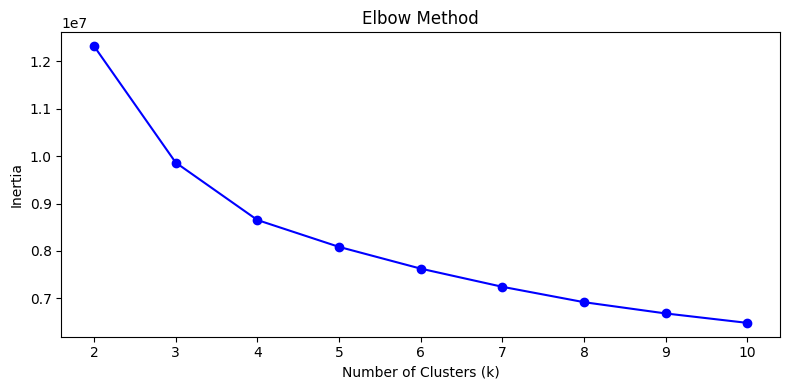

In [64]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Use all features except Churn
cluster_features = [c for c in train_data.columns if c != 'Churn']

scaler = StandardScaler()
X_cluster = scaler.fit_transform(train_data[cluster_features])

# Elbow method
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)
    print(f"k={k} done")

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.tight_layout()
plt.show()

Not very sharp, can use k=4 or k=5

In [65]:
# Fit final KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_cluster)

# Add cluster label as a feature to train_data only
train_data['cluster'] = kmeans.labels_

# Check churn rate per cluster
print(train_data.groupby('cluster')['Churn'].mean().sort_values(ascending=False))
print(train_data['cluster'].value_counts())

cluster
1    0.466554
3    0.168182
0    0.084343
2    0.014311
Name: Churn, dtype: float64
cluster
1    236815
0    180358
2    140727
3     36294
Name: count, dtype: int64


Observations:

\
Elbow Method:
- No sharp elbow visible — curve gradually flattens from k=2 onwards
- Meaningful change in slope at k=4 where the rate of decrease slows noticeably
- Selected **k=4** as the optimal number of clusters

\
Cluster Profiles:
| Cluster | Churn Rate | Size | Profile |
|---|---|---|---|
| 1 | 46.7% | 236,815 | High risk — nearly half churn |
| 3 | 16.8% | 36,294 | Medium risk |
| 0 | 8.4% | 180,358 | Low risk |
| 2 | 1.4% | 140,727 | Very loyal — almost never churn |

\
Key Findings:
- Clusters are very well separated by churn rate — 46.7% vs 1.4% is a massive difference
- Cluster 1 is the largest group (236,815 customers) AND the highest risk — most important to target
- Cluster 2 is the most loyal segment despite being the second largest group
- Cluster 3 is notably small (36,294) — likely a niche customer profile

\
Next Step: \
Testing whether adding cluster label as a feature improves XGBoost AUC above 0.9167

Visualising the Clusters

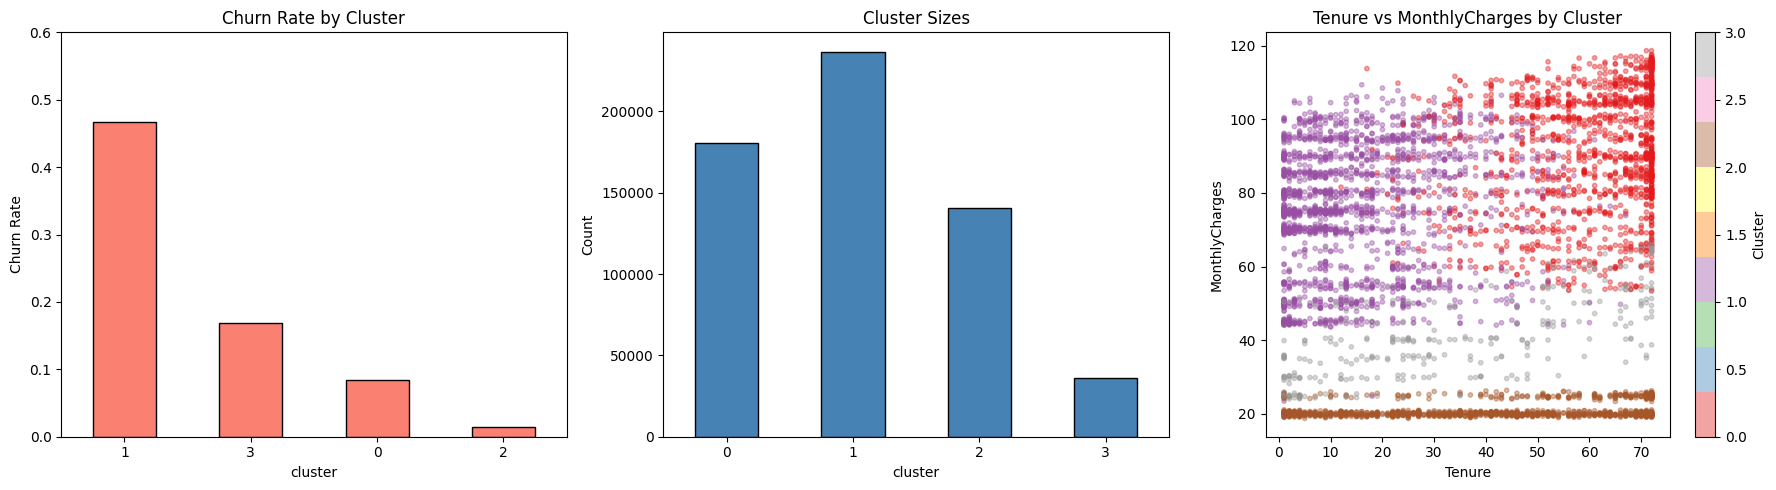

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn rate per cluster
churn_by_cluster = train_data.groupby('cluster')['Churn'].mean().sort_values(ascending=False)
churn_by_cluster.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Churn Rate by Cluster')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 0.6)
axes[0].tick_params(axis='x', rotation=0)

# 2. Cluster sizes
train_data['cluster'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Cluster Sizes')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

# 3. Tenure vs MonthlyCharges colored by cluster
sample = train_data.sample(5000, random_state=42)
scatter = axes[2].scatter(
    sample['tenure'], sample['MonthlyCharges'],
    c=sample['cluster'], cmap='Set1', alpha=0.4, s=10
)
axes[2].set_title('Tenure vs MonthlyCharges by Cluster')
axes[2].set_xlabel('Tenure')
axes[2].set_ylabel('MonthlyCharges')
plt.colorbar(scatter, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.show()

2026-03-14 07:11:54.306363: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773472314.519672      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773472314.592669      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773472315.061784      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773472315.061817      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773472315.061820      55 computation_placer.cc:177] computation placer alr

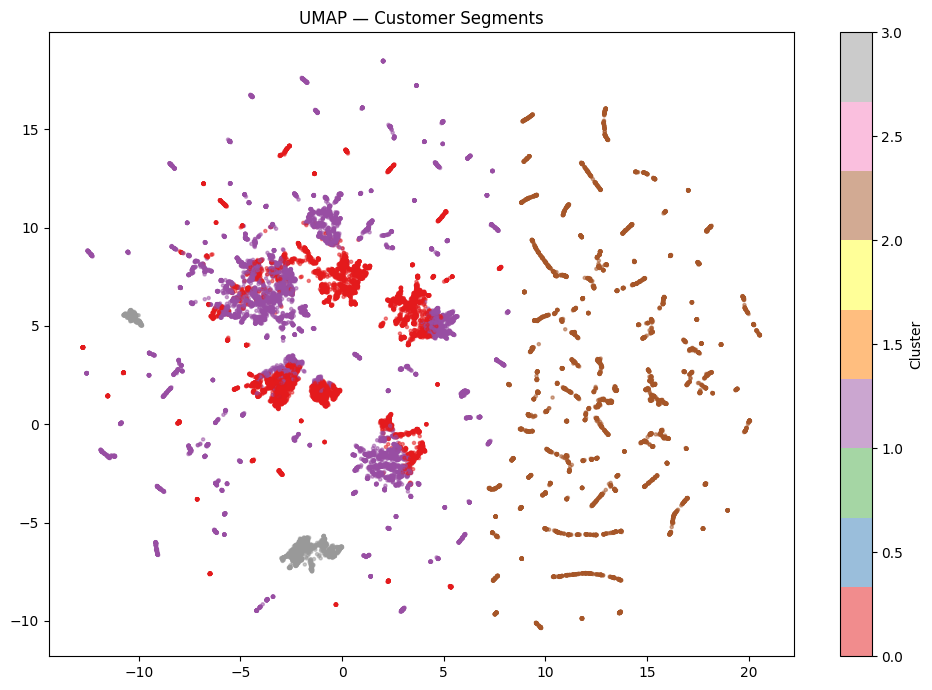

In [67]:
import umap

# Sample 20k rows — UMAP on full 594k would still be slow
sample_idx = train_data.sample(20000, random_state=42).index
X_sample = X_cluster[train_data.index.isin(sample_idx)]
labels_sample = train_data.loc[train_data.index.isin(sample_idx), 'cluster']

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_sample)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=labels_sample, cmap='Set1', alpha=0.5, s=5
)
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP — Customer Segments')
plt.tight_layout()
plt.show()

- Brown Clusters are completely separate. These are the very loyal customers that are completely different from the others.
- The Red and Purple overlap shows that there may be more than 4 clusters required. Similar features but different outcomes

cluster_6
5    0.612259
4    0.225897
3    0.168182
1    0.157859
2    0.016816
0    0.014311
Name: Churn, dtype: float64
cluster_6
5    146884
0    140727
2     93959
4     93370
1     82960
3     36294
Name: count, dtype: int64


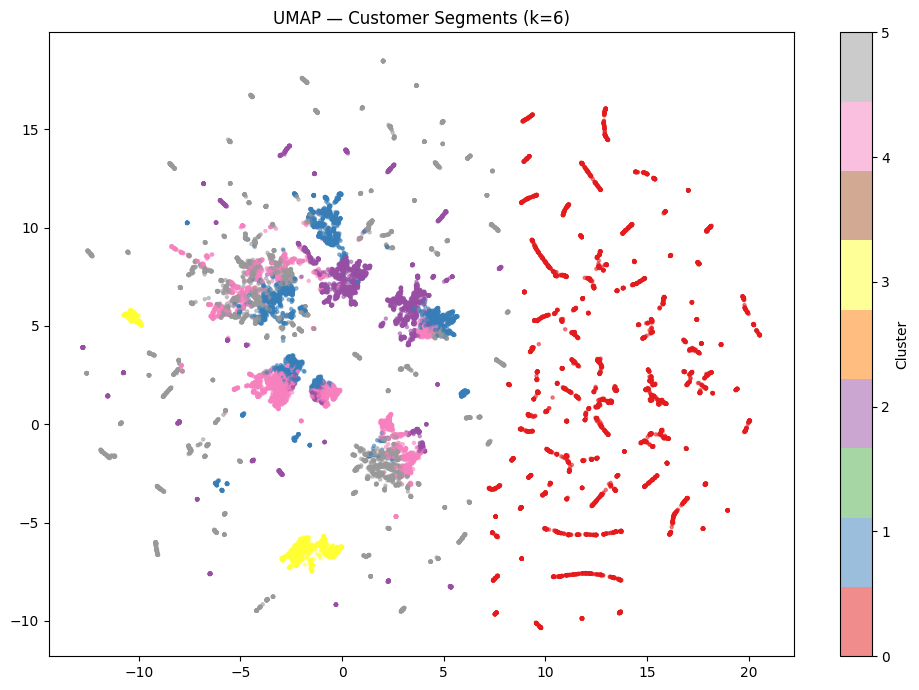

In [68]:
# Try k=6
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_6.fit(X_cluster)

# Check churn rate per cluster
train_data['cluster_6'] = kmeans_6.labels_
print(train_data.groupby('cluster_6')['Churn'].mean().sort_values(ascending=False))
print(train_data['cluster_6'].value_counts())

# UMAP visualization
labels_sample_6 = train_data.loc[train_data.index.isin(sample_idx), 'cluster_6']

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=labels_sample_6, cmap='Set1', alpha=0.5, s=5
)
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP — Customer Segments (k=6)')
plt.tight_layout()
plt.show()

cluster_5
2    0.520572
1    0.381996
3    0.168182
4    0.041550
0    0.014311
Name: Churn, dtype: float64
cluster_5
1    154910
4    146137
0    140727
2    116126
3     36294
Name: count, dtype: int64


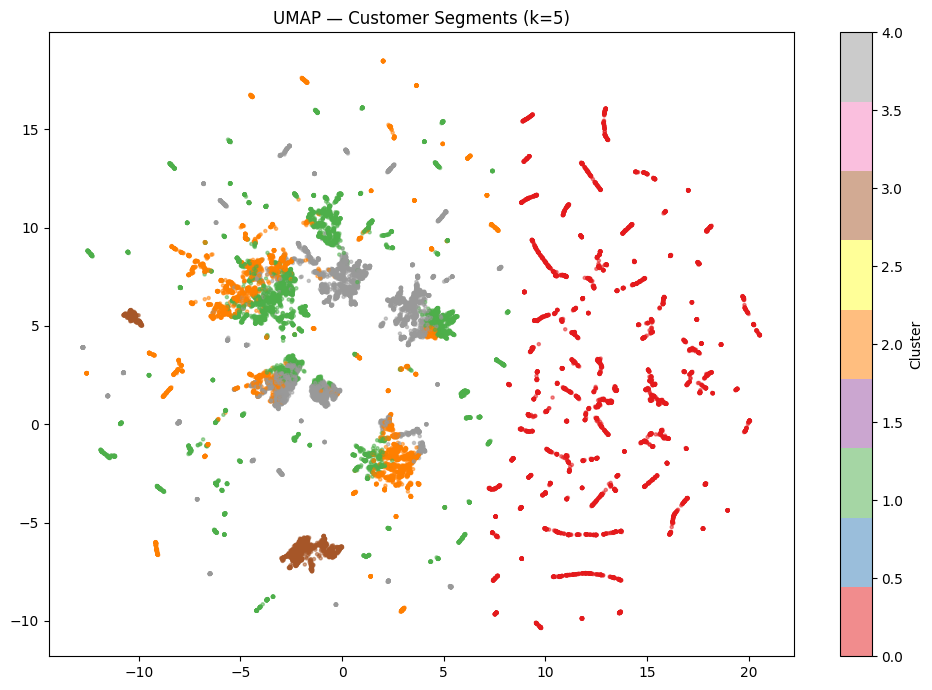

In [69]:
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_5.fit(X_cluster)

train_data['cluster_5'] = kmeans_5.labels_
print(train_data.groupby('cluster_5')['Churn'].mean().sort_values(ascending=False))
print(train_data['cluster_5'].value_counts())

labels_sample_5 = train_data.loc[train_data.index.isin(sample_idx), 'cluster_5']

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=labels_sample_5, cmap='Set1', alpha=0.5, s=5
)
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP — Customer Segments (k=5)')
plt.tight_layout()
plt.show()

Observations:

\
k=6 Results:
| Cluster | Churn Rate | Size |
|---|---|---|
| 5 | 61.2% | 146,884 |
| 4 | 22.6% | 93,370 |
| 3 | 16.8% | 36,294 |
| 1 | 15.8% | 82,960 |
| 2 | 1.7% | 93,959 |
| 0 | 1.4% | 140,727 |

- Better separation at the top — split the 46.7% cluster into an even higher risk group at 61.2%
- However clusters 3 and 1 are nearly identical (16.8% vs 15.8%) — redundant split
- Clusters 0 and 2 are also nearly identical (1.4% vs 1.7%) — another redundant split
- UMAP showed pink/blue mixing heavily into grey — artificial splits with no natural boundary


\
k=5 Results:
| Cluster | Churn Rate | Size |
|---|---|---|
| 2 | 52.1% | 116,126 |
| 1 | 38.2% | 154,910 |
| 3 | 16.8% | 36,294 |
| 4 | 4.2% | 146,137 |
| 0 | 1.4% | 140,727 |

- Clean, well separated churn rates across all 5 clusters — no redundant splits
- UMAP revealed a concentric ring structure:
  - **Cluster 2 (orange, 52.1%)** — outermost ring, highest churn risk
  - **Cluster 1 (green, 38.2%)** — outer layer, high risk
  - **Cluster 3 (brown, 16.8%)** — small niche group, medium risk
  - **Cluster 4 (grey, 4.2%)** — central core, mostly loyal
  - **Cluster 0 (red, 1.4%)** — completely isolated island, no internet service group, almost zero churn
- Moving outward from centre = progressively higher churn risk — intuitive and meaningful structure

\
Why k=5 Over k=6
- k=6 created redundant clusters with nearly identical churn rates (1.4% vs 1.7%, 15.8% vs 16.8%)
- k=5 has no redundant splits — every cluster is meaningfully distinct
- k=5 UMAP shows cleaner separation with the concentric ring pattern clearly visible
- k=5 preserves the high risk signal (52.1%) without over-fragmenting the middle and bottom

\
**Selected k=5 cluster labels as new feature for modeling.**

In [70]:
print(train_data.columns.tolist())
print(train_data['cluster_5'].value_counts())

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No_phone_service', 'MultipleLines_Yes', 'OnlineSecurity_No_internet_service', 'OnlineSecurity_Yes', 'OnlineBackup_No_internet_service', 'OnlineBackup_Yes', 'DeviceProtection_No_internet_service', 'DeviceProtection_Yes', 'TechSupport_No_internet_service', 'TechSupport_Yes', 'StreamingTV_No_internet_service', 'StreamingTV_Yes', 'StreamingMovies_No_internet_service', 'StreamingMovies_Yes', 'InternetService_Fiber_optic', 'InternetService_No', 'Contract_One_year', 'Contract_Two_year', 'PaymentMethod_Credit_card_(automatic)', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check', 'num_addons', 'tenure_group', 'cluster', 'cluster_6', 'cluster_5']
cluster_5
1    154910
4    146137
0    140727
2    116126
3     36294
Name: count, dtype: int64


In [72]:
# Split with cluster feature included
X = train_data.drop(columns=['Churn', 'cluster', 'cluster_6']) # removing cluster labels from k=4, k=6
y = train_data['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost with cluster feature
xgb_cluster = XGBClassifier(
    n_estimators=395,
    max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7,
    gamma=1.308840064055984,
    scale_pos_weight=3.44,      # better represents the target proportions
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50,
    device='cuda'
)

xgb_cluster.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

cluster_probs = xgb_cluster.predict_proba(X_val)[:, 1]
print(f"With Cluster AUC:    {roc_auc_score(y_val, cluster_probs):.4f}")
print(f"Without Cluster AUC: 0.9167")

[0]	validation_0-auc:0.88934
[50]	validation_0-auc:0.91410
[100]	validation_0-auc:0.91544
[150]	validation_0-auc:0.91587
[200]	validation_0-auc:0.91620
[250]	validation_0-auc:0.91632
[300]	validation_0-auc:0.91639
[350]	validation_0-auc:0.91647
[394]	validation_0-auc:0.91647
With Cluster AUC:    0.9165
Without Cluster AUC: 0.9167


In [73]:
X = train_data.drop(columns=['Churn', 'cluster_5', 'cluster_6'])  # keep cluster (k=4)
y = train_data['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_cluster4 = XGBClassifier(
    n_estimators=395,
    max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7,
    gamma=1.308840064055984,
    scale_pos_weight=3,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50,
    device='cuda'
)

xgb_cluster4.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

cluster4_probs = xgb_cluster4.predict_proba(X_val)[:, 1]
print(f"With Cluster k=4 AUC: {roc_auc_score(y_val, cluster4_probs):.4f}")
print(f"With Cluster k=5 AUC: 0.9165")
print(f"Without Cluster AUC:  0.9167")

[0]	validation_0-auc:0.89049
[50]	validation_0-auc:0.91402
[100]	validation_0-auc:0.91542
[150]	validation_0-auc:0.91594
[200]	validation_0-auc:0.91629
[250]	validation_0-auc:0.91644
[300]	validation_0-auc:0.91648
[350]	validation_0-auc:0.91652
[394]	validation_0-auc:0.91658
With Cluster k=4 AUC: 0.9166
With Cluster k=5 AUC: 0.9165
Without Cluster AUC:  0.9167


## Trying to Train Full Set

In [15]:
# Train on full dataset — no validation split
import xgboost as xgb

X_full = train_data.drop(columns=['Churn'])
y_full = train_data['Churn']

final_full_model = xgb.XGBClassifier(
    n_estimators=395,
    max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7,
    gamma=1.308840064055984,
    scale_pos_weight=3,
    eval_metric='auc',
    random_state=42,
    device='cuda'
)

final_full_model.fit(X_full, y_full, verbose=50)
print("Done!")

Done!


## Trying Applying SMOTE-ENN

In [12]:
# !pip install imbalanced-learn

In [13]:
from imblearn.combine import SMOTEENN
from collections import Counter

print(f"Before SMOTE-ENN: {Counter(y_train)}")

smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)

print(f"After SMOTE-ENN: {Counter(y_train_resampled)}")
print(f"New training size: {X_train_resampled.shape}")

Before SMOTE-ENN: Counter({0: 368301, 1: 107054})
After SMOTE-ENN: Counter({1: 311198, 0: 255877})
New training size: (567075, 31)


In [17]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report

xgb_smote = xgb.XGBClassifier(
    n_estimators=395,
    max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7,
    gamma=1.308840064055984,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50,
    device='cuda'
    # no scale_pos_weight — SMOTE-ENN already balanced the classes
)

xgb_smote.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_val, y_val)],  # original val set, never resample validation!
    verbose=50
)

smote_probs = xgb_smote.predict_proba(X_val)[:, 1]
print(f"SMOTE-ENN XGBoost AUC: {roc_auc_score(y_val, smote_probs):.4f}")
print(f"Original XGBoost AUC:  0.9167")
print(classification_report(y_val, xgb_smote.predict(X_val)))

[0]	validation_0-auc:0.88824
[50]	validation_0-auc:0.90988
[100]	validation_0-auc:0.91116
[150]	validation_0-auc:0.91171
[200]	validation_0-auc:0.91209
[250]	validation_0-auc:0.91244
[300]	validation_0-auc:0.91255
[350]	validation_0-auc:0.91273
[394]	validation_0-auc:0.91273
SMOTE-ENN XGBoost AUC: 0.9127
Original XGBoost AUC:  0.9167
              precision    recall  f1-score   support

           0       0.95      0.81      0.87     92076
           1       0.57      0.87      0.68     26763

    accuracy                           0.82    118839
   macro avg       0.76      0.84      0.78    118839
weighted avg       0.87      0.82      0.83    118839



This actually hurt performance. 

## Trying Cox Proportional Hazard

In [18]:
# !pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=6884631546a068397196f1f2d4486d5c87284270bd51ac5a107de6c723ef588b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [19]:
from lifelines import CoxPHFitter

# Use encoded train_data — drop Churn temporarily to build cox_input
cox_input = train_data.copy()

# Cox needs tenure as duration col and Churn as event col
# All other columns are covariates
cph = CoxPHFitter(penalizer=0.1)  # penalizer prevents overfitting with many features
cph.fit(
    cox_input, 
    duration_col='tenure', 
    event_col='Churn'
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 594194 total observations, 460377 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 594194
number of events observed = 133817
   partial log-likelihood = -1535127.08
         time fit was run = 2026-03-14 11:26:34 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
SeniorCitizen                          0.22      1.24      0.01            0.21            0.23                1.23                1.26
Partner                               -0.28      0.76      0.01           -0.29           -0.27                0.75                0.77
Dependents                            -0.22      0.80      0.01           -0.24           -0.21                0.79                0.81
PhoneService                          -0.01      0.99      0.01           -0.03            0.02                0.97                1.02
PaperlessBilling                       0.25      1.28      0.01            0.24            0.26                1.27                1.30
MonthlyCharges                         0.00      1.00      0.00            0.00            0.00                1.00                1.00
TotalCharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MultipleLines_No_phone_service         0.01      1.01      0.01           -0.02            0.03                0.98                1.03
MultipleLines_Yes                     -0.03      0.97      0.00           -0.04           -0.02                0.96                0.98
OnlineSecurity_No_internet_service    -0.26      0.77      0.01           -0.27           -0.24                0.76                0.79
OnlineSecurity_Yes                    -0.37      0.69      0.01           -0.39           -0.36                0.68                0.70
OnlineBackup_No_internet_service      -0.26      0.77      0.01           -0.27           -0.24                0.76                0.79
OnlineBackup_Yes                      -0.21      0.81      0.01           -0.22           -0.20                0.80                0.82
DeviceProtection_No_internet_service  -0.26      0.77      0.01           -0.27           -0.24                0.76                0.79
DeviceProtection_Yes                  -0.15      0.86      0.01           -0.16           -0.14                0.85                0.87
TechSupport_No_internet_service       -0.26      0.77      0.01           -0.27           -0.24                0.76                0.79
TechSupport_Yes                       -0.29      0.75      0.01           -0.30           -0.28                0.74                0.76
StreamingTV_No_internet_service       -0.26      0.77      0.01           -0.27           -0.24                0.76                0.79
StreamingTV_Yes                        0.08      1.08      0.01            0.07            0.09                1.07                1.10
StreamingMovies_No_internet_service   -0.26      0.77      0.01           -0.27           -0.24                0.76                0.79
StreamingMovies_Yes                    0.08      1.08      0.01            0.06            0.09                1.07                1.09
InternetService_Fiber_optic            0.48      1.62      0.01            0.47            0.50                1.60                1.64
InternetService_No                    -0.26      0.77      0.01           -0.27           -0.24                0.76                0.79
Contract_One_year                     -0.51      0.60      0.01           -0.52           -0.49                0.59                0.61
Contract_Two_year        

In [20]:
# Generate hazard score for each customer
train_data['hazard_score'] = cph.predict_partial_hazard(train_data)

# Check distribution
print(train_data['hazard_score'].describe())
print(f"\nCorrelation with Churn: {train_data['hazard_score'].corr(train_data['Churn']):.4f}")

count    594194.000000
mean          7.577490
std          13.030868
min           0.013998
25%           0.115030
50%           0.793727
75%           8.734078
max          66.890695
Name: hazard_score, dtype: float64

Correlation with Churn: 0.5645


In [22]:
X = train_data.drop(columns=['Churn'])
y = train_data['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_hazard = xgb.XGBClassifier(
    n_estimators=395,
    max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7,
    gamma=1.308840064055984,
    scale_pos_weight=3,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50,
    device='cuda'
)

xgb_hazard.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

hazard_probs = xgb_hazard.predict_proba(X_val)[:, 1]
print(f"With Hazard Score AUC: {roc_auc_score(y_val, hazard_probs):.4f}")
print(f"Without Hazard Score:  0.9167")
print(classification_report(y_val, xgb_hazard.predict(X_val)))

[0]	validation_0-auc:0.89814
[50]	validation_0-auc:0.91409
[100]	validation_0-auc:0.91537
[150]	validation_0-auc:0.91600
[200]	validation_0-auc:0.91622
[250]	validation_0-auc:0.91639
[300]	validation_0-auc:0.91646
[350]	validation_0-auc:0.91652
[379]	validation_0-auc:0.91652
With Hazard Score AUC: 0.9165
Without Hazard Score:  0.9167
              precision    recall  f1-score   support

           0       0.95      0.82      0.88     92076
           1       0.58      0.86      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.76      0.84      0.79    118839
weighted avg       0.87      0.83      0.84    118839



## Trying Pseudo-labels

In [32]:
# Get test set predictions with current model
test_probs = final_model.predict_proba(test_data)[:, 1]

# Check confidence distribution
import numpy as np
print(f"Predictions > 0.95: {(test_probs > 0.95).sum()}")
print(f"Predictions < 0.05: {(test_probs < 0.05).sum()}")
print(f"Total high confidence: {((test_probs > 0.95) | (test_probs < 0.05)).sum()}")
print(f"Total test samples: {len(test_probs)}")

Predictions > 0.95: 6863
Predictions < 0.05: 92909
Total high confidence: 99772
Total test samples: 254655


In [33]:
# Step 1: Create pseudo labels
high_conf_mask = (test_probs >= 0.95) | (test_probs <= 0.05)
X_pseudo = test_data[high_conf_mask].copy()
y_pseudo = (test_probs[high_conf_mask] >= 0.95).astype(int)

print(f"Pseudo churners: {y_pseudo.sum()}")
print(f"Pseudo non-churners: {(y_pseudo == 0).sum()}")

# Step 2: Combine with original training data
X_combined = pd.concat([X_train, X_pseudo], axis=0).reset_index(drop=True)
y_combined = pd.concat([y_train, pd.Series(y_pseudo)], axis=0).reset_index(drop=True)

print(f"Original training size: {X_train.shape}")
print(f"New combined training size: {X_combined.shape}")

# Step 3: Retrain on combined data
pseudo_model = XGBClassifier(**best_params)
pseudo_model.fit(
    X_combined, y_combined,
    eval_set=[(X_val, y_val)],
    verbose=50
)

pseudo_probs = pseudo_model.predict_proba(X_val)[:, 1]
print(f"\nPseudo Label AUC: {roc_auc_score(y_val, pseudo_probs):.4f}")
print(f"Original AUC:     0.9165")
print(classification_report(y_val, pseudo_model.predict(X_val)))

Pseudo churners: 6863
Pseudo non-churners: 92909
Original training size: (475355, 31)
New combined training size: (575127, 31)
[0]	validation_0-auc:0.89112
[50]	validation_0-auc:0.91407
[100]	validation_0-auc:0.91540
[150]	validation_0-auc:0.91590
[200]	validation_0-auc:0.91625
[250]	validation_0-auc:0.91642
[300]	validation_0-auc:0.91649
[350]	validation_0-auc:0.91651
[394]	validation_0-auc:0.91648

Pseudo Label AUC: 0.9165
Original AUC:     0.9165
              precision    recall  f1-score   support

           0       0.95      0.81      0.88     92076
           1       0.58      0.86      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.76      0.84      0.78    118839
weighted avg       0.87      0.83      0.84    118839



## Trying Categorical Combinations

In [14]:
# Fresh start with raw data
cat_combo_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
cat_combo_df['Churn'] = cat_combo_df['Churn'].map({'Yes': 1, 'No': 0})
cat_combo_df.drop(columns=['id', 'gender'], inplace=True)

# Binary encode simple cols
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    cat_combo_df[col] = cat_combo_df[col].map({'Yes': 1, 'No': 0})

# Create categorical combinations BEFORE encoding
cat_combo_df['Contract_Payment'] = (
    cat_combo_df['Contract'] + '_' + cat_combo_df['PaymentMethod']
)
cat_combo_df['Internet_Contract'] = (
    cat_combo_df['InternetService'] + '_' + cat_combo_df['Contract']
)
cat_combo_df['Internet_Payment'] = (
    cat_combo_df['InternetService'] + '_' + cat_combo_df['PaymentMethod']
)
cat_combo_df['Internet_Security'] = (
    cat_combo_df['InternetService'] + '_' + cat_combo_df['OnlineSecurity']
)
cat_combo_df['Contract_TechSupport'] = (
    cat_combo_df['Contract'] + '_' + cat_combo_df['TechSupport']
)

# Check unique values and churn rates for each combo
for col in ['Contract_Payment', 'Internet_Contract', 'Internet_Payment',
            'Internet_Security', 'Contract_TechSupport']:
    print(f"\n{col}:")
    print(cat_combo_df.groupby(col)['Churn'].mean().sort_values(ascending=False))


Contract_Payment:
Contract_Payment
Month-to-month_Electronic check             0.556798
Month-to-month_Bank transfer (automatic)    0.240299
Month-to-month_Credit card (automatic)      0.233974
Month-to-month_Mailed check                 0.173862
One year_Electronic check                   0.146125
Two year_Electronic check                   0.053599
One year_Bank transfer (automatic)          0.045648
One year_Credit card (automatic)            0.041858
One year_Mailed check                       0.014525
Two year_Bank transfer (automatic)          0.009615
Two year_Credit card (automatic)            0.008634
Two year_Mailed check                       0.002003
Name: Churn, dtype: float64

Internet_Contract:
Internet_Contract
Fiber optic_Month-to-month    0.550093
DSL_Month-to-month            0.225724
Fiber optic_One year          0.132738
No_Month-to-month             0.054969
Fiber optic_Two year          0.035436
DSL_One year                  0.022020
No_One year                 

In [15]:
import category_encoders as ce
from sklearn.model_selection import train_test_split

# Feature engineering
addon_cols_raw = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
cat_combo_df['num_addons'] = (cat_combo_df[addon_cols_raw] == 'Yes').sum(axis=1)
cat_combo_df['tenure_group'] = pd.cut(
    cat_combo_df['tenure'], bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3]
).astype(int)

# Split BEFORE encoding
X_combo = cat_combo_df.drop(columns=['Churn'])
y_combo = cat_combo_df['Churn']

X_combo_train, X_combo_val, y_combo_train, y_combo_val = train_test_split(
    X_combo, y_combo, test_size=0.2, random_state=42, stratify=y_combo
)

# Target encode ALL categoricals including combos
target_encode_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod',
    'Contract_Payment', 'Internet_Contract', 'Internet_Payment',
    'Internet_Security', 'Contract_TechSupport'
]

encoder = ce.TargetEncoder(cols=target_encode_cols, smoothing=0.3)
X_combo_train_enc = encoder.fit_transform(X_combo_train, y_combo_train)
X_combo_val_enc = encoder.transform(X_combo_val)

print(X_combo_train_enc.shape)
print(X_combo_train_enc.dtypes)

(475355, 25)
SeniorCitizen             int64
Partner                   int64
Dependents                int64
tenure                    int64
PhoneService              int64
MultipleLines           float64
InternetService         float64
OnlineSecurity          float64
OnlineBackup            float64
DeviceProtection        float64
TechSupport             float64
StreamingTV             float64
StreamingMovies         float64
Contract                float64
PaperlessBilling          int64
PaymentMethod           float64
MonthlyCharges          float64
TotalCharges            float64
Contract_Payment        float64
Internet_Contract       float64
Internet_Payment        float64
Internet_Security       float64
Contract_TechSupport    float64
num_addons                int64
tenure_group              int64
dtype: object


In [24]:
xgb_combo = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7,
    gamma=1.308840064055984,
    scale_pos_weight=3,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50,
    device='cuda'
)

xgb_combo.fit(
    X_combo_train_enc, y_combo_train,
    eval_set=[(X_combo_val_enc, y_combo_val)],
    verbose=50
)

combo_probs = xgb_combo.predict_proba(X_combo_val_enc)[:, 1]
print(f"Combo + Target Encoding AUC: {roc_auc_score(y_combo_val, combo_probs):.4f}")
print(f"Original XGBoost AUC:        0.9165")
print(classification_report(y_combo_val, xgb_combo.predict(X_combo_val_enc)))

[0]	validation_0-auc:0.89570
[50]	validation_0-auc:0.91421
[100]	validation_0-auc:0.91552
[150]	validation_0-auc:0.91604
[200]	validation_0-auc:0.91637
[250]	validation_0-auc:0.91650
[300]	validation_0-auc:0.91660
[350]	validation_0-auc:0.91665
[400]	validation_0-auc:0.91664
[426]	validation_0-auc:0.91663
Combo + Target Encoding AUC: 0.9167
Original XGBoost AUC:        0.9165
              precision    recall  f1-score   support

           0       0.95      0.82      0.88     92076
           1       0.58      0.86      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.77      0.84      0.79    118839
weighted avg       0.87      0.83      0.84    118839



## Trying Multiple Seeds + Rank Averaging

In [11]:
from scipy.stats import rankdata

seeds = [42, 123, 456, 789, 1024]
xgb_preds_seeds = []

for seed in seeds:
    model_seed = XGBClassifier(
        n_estimators=395,
        max_depth=4,
        learning_rate=0.18686108212758018,
        subsample=0.8667476017573688,
        colsample_bytree=0.9066658356163867,
        min_child_weight=7,
        gamma=1.308840064055984,
        scale_pos_weight=3,
        eval_metric='auc',
        random_state=seed,
        early_stopping_rounds=50,
        device='cuda'
    )
    model_seed.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    preds = model_seed.predict_proba(X_val)[:, 1]
    xgb_preds_seeds.append(preds)
    print(f"Seed {seed}: {roc_auc_score(y_val, preds):.4f}")

# Average raw probabilities
xgb_avg = np.mean(xgb_preds_seeds, axis=0)
print(f"\nMulti-seed avg AUC: {roc_auc_score(y_val, xgb_avg):.4f}")

# Rank averaging
xgb_ranks = np.mean([rankdata(p) / len(p) for p in xgb_preds_seeds], axis=0)
print(f"Multi-seed rank avg AUC: {roc_auc_score(y_val, xgb_ranks):.4f}")

print(f"Single seed AUC: 0.9165")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [16:59:12] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Seed 42: 0.9165
Seed 123: 0.9166
Seed 456: 0.9165
Seed 789: 0.9165
Seed 1024: 0.9166

Multi-seed avg AUC: 0.9168
Multi-seed rank avg AUC: 0.9168
Single seed AUC: 0.9165


In [17]:
cat_preds_seeds = []

for seed in seeds:
    cat_seed = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        scale_pos_weight=3,
        eval_metric='AUC',
        random_seed=seed,
        early_stopping_rounds=50,
        verbose=False,
        task_type='GPU'
    )
    cat_seed.fit(
        X_cat_train, y_cat_train,
        cat_features=cat_features,
        eval_set=(X_cat_val, y_cat_val)
    )
    preds = cat_seed.predict_proba(X_cat_val)[:, 1]
    cat_preds_seeds.append(preds)
    print(f"CAT Seed {seed}: {roc_auc_score(y_cat_val, preds):.4f}")

# Average
cat_avg = np.mean(cat_preds_seeds, axis=0)
cat_ranks = np.mean([rankdata(p) / len(p) for p in cat_preds_seeds], axis=0)
print(f"\nCAT Multi-seed avg AUC: {roc_auc_score(y_val, cat_avg):.4f}")
print(f"CAT Multi-seed rank avg AUC: {roc_auc_score(y_val, cat_ranks):.4f}")

# Blend multi-seed XGB + multi-seed CAT
blend_avg = (xgb_avg * 0.5) + (cat_avg * 0.5)
blend_ranks = (xgb_ranks * 0.5) + (cat_ranks * 0.5)
print(f"\nBlend avg probs AUC: {roc_auc_score(y_val, blend_avg):.4f}")
print(f"Blend rank avg AUC:  {roc_auc_score(y_val, blend_ranks):.4f}")
print(f"Current best:        0.9169")

Default metric period is 5 because AUC is/are not implemented for GPU


CAT Seed 42: 0.9160


Default metric period is 5 because AUC is/are not implemented for GPU


CAT Seed 123: 0.9160


Default metric period is 5 because AUC is/are not implemented for GPU


CAT Seed 456: 0.9161


Default metric period is 5 because AUC is/are not implemented for GPU


CAT Seed 789: 0.9161


Default metric period is 5 because AUC is/are not implemented for GPU


CAT Seed 1024: 0.9161

CAT Multi-seed avg AUC: 0.9162
CAT Multi-seed rank avg AUC: 0.9162

Blend avg probs AUC: 0.9167
Blend rank avg AUC:  0.9167
Current best:        0.9169


In [31]:
lgb_preds_seeds = []

for seed in seeds:
    lgb_seed = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        scale_pos_weight=3,
        random_state=seed,
        verbose=-1,
        device='gpu'
    )
    lgb_seed.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(500)]
    )
    preds = lgb_seed.predict_proba(X_val)[:, 1]
    lgb_preds_seeds.append(preds)
    print(f"LGB Seed {seed}: {roc_auc_score(y_val, preds):.4f}")

lgb_avg = np.mean(lgb_preds_seeds, axis=0)
lgb_ranks = np.mean([rankdata(p) / len(p) for p in lgb_preds_seeds], axis=0)
print(f"\nLGB Multi-seed avg AUC: {roc_auc_score(y_val, lgb_avg):.4f}")

# Blend XGB multi-seed + LGB multi-seed
blend_xgb_lgb = (xgb_avg * 0.6) + (lgb_avg * 0.4)
blend_ranks_xgb_lgb = (xgb_ranks * 0.6) + (lgb_ranks * 0.4)
print(f"XGB + LGB blend avg:   {roc_auc_score(y_val, blend_xgb_lgb):.4f}")
print(f"XGB + LGB rank blend:  {roc_auc_score(y_val, blend_ranks_xgb_lgb):.4f}")
print(f"Current best:          0.9169")

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[193]	valid_0's binary_logloss: 0.353211
LGB Seed 42: 0.9130
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[195]	valid_0's binary_logloss: 0.353176
LGB Seed 123: 0.9131
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[186]	valid_0's binary_logloss: 0.353219
LGB Seed 456: 0.9129
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[188]	valid_0's binary_logloss: 0.353055
LGB Seed 789: 0.9131
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[191]	valid_0's binary_logloss: 0.353191
LGB Seed 1024: 0.9130

LGB Multi-seed avg AUC: 0.9130
XGB + LGB blend avg:   0.9163
XGB + LGB rank blend:  0.9162
Current best:          0.9169


In [17]:
# XGB multi-seed + CAT single seed
blend1 = (xgb_avg * 0.5) + (cat_probs * 0.5)
blend2 = (xgb_avg * 0.6) + (cat_probs * 0.4)
blend3 = (xgb_avg * 0.7) + (cat_probs * 0.3)
blend4 = (xgb_ranks * 0.5) + (rankdata(cat_probs)/len(cat_probs) * 0.5)

print(f"XGB_avg 0.5 + CAT 0.5:     {roc_auc_score(y_val, blend1):.4f}")
print(f"XGB_avg 0.6 + CAT 0.4:     {roc_auc_score(y_val, blend2):.4f}")
print(f"XGB_avg 0.7 + CAT 0.3:     {roc_auc_score(y_val, blend3):.4f}")
print(f"XGB_ranks + CAT_ranks 0.5: {roc_auc_score(y_val, blend4):.4f}")
print(f"Current best:              0.9169")

NameError: name 'xgb_avg' is not defined

## Trying Real/Synthetic Classifier

In [3]:
# Load IBM original dataset
ibm = pd.read_csv('/kaggle/input/datasets/riddhimadeshmukh/teleco-customer-churn-dataset/Telco-Customer-Churn.csv')

# Load competition train
comp = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')

# Label them
ibm['is_real'] = 1
comp['is_real'] = 0

# Keep common columns only
common_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
               'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
               'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
               'MonthlyCharges', 'TotalCharges', 'is_real']

ibm_sub = ibm[common_cols].copy()
comp_sub = comp[common_cols].copy()

# Fix TotalCharges
ibm_sub['TotalCharges'] = pd.to_numeric(ibm_sub['TotalCharges'], errors='coerce').fillna(0)

# Combine
combined = pd.concat([ibm_sub, comp_sub], axis=0).reset_index(drop=True)
print(combined['is_real'].value_counts())
print(combined.shape)

is_real
0    594194
1      7043
Name: count, dtype: int64
(601237, 20)


In [4]:
from sklearn.preprocessing import LabelEncoder

# Encode categoricals
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

combined_enc = combined.copy()
for col in cat_cols:
    le = LabelEncoder()
    combined_enc[col] = le.fit_transform(combined_enc[col].astype(str))

X_real = combined_enc.drop(columns=['is_real'])
y_real = combined_enc['is_real']

# Train real vs synthetic classifier
from sklearn.model_selection import train_test_split

X_real_train, X_real_val, y_real_train, y_real_val = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

real_clf = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=len(y_real[y_real==0]) / len(y_real[y_real==1]),
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=50,
    device='cuda'
)

real_clf.fit(
    X_real_train, y_real_train,
    eval_set=[(X_real_val, y_real_val)],
    verbose=50
)

real_val_probs = real_clf.predict_proba(X_real_val)[:, 1]
print(f"Real vs Synthetic AUC: {roc_auc_score(y_real_val, real_val_probs):.4f}")

[0]	validation_0-auc:0.60092


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [04:29:52] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [04:29:52] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-auc:0.65647
[100]	validation_0-auc:0.66579
[150]	validation_0-auc:0.67076
[200]	validation_0-auc:0.67533
[250]	validation_0-auc:0.67713
[300]	validation_0-auc:0.67805
[350]	validation_0-auc:0.67923
[400]	validation_0-auc:0.67968
[450]	validation_0-auc:0.67978
[484]	validation_0-auc:0.67970
Real vs Synthetic AUC: 0.6804


In [15]:
'''
# Get probability of being "real" for competition train data
comp_for_pred = comp[common_cols].drop(columns=['is_real']).copy()
comp_for_pred['TotalCharges'] = pd.to_numeric(
    comp_for_pred['TotalCharges'], errors='coerce'
).fillna(0)
'''

# Re-encode combined properly, storing encoders
encoders = {}
combined_enc = combined.copy()

for col in cat_cols:
    le = LabelEncoder()
    combined_enc[col] = le.fit_transform(combined_enc[col].astype(str))
    encoders[col] = le  # store each encoder

# Now encode comp using stored encoders
comp_enc = comp_for_pred.copy()
for col in cat_cols:
    comp_enc[col] = encoders[col].transform(comp_enc[col].astype(str))

# Generate prob_real feature
train_data['prob_real'] = real_clf.predict_proba(comp_enc)[:, 1]

print(train_data['prob_real'].describe())
print(f"Correlation with Churn: {train_data['prob_real'].corr(train_data['Churn']):.4f}")

count    594194.000000
mean          0.439599
std           0.133162
min           0.000040
25%           0.346180
50%           0.440675
75%           0.525828
max           0.954693
Name: prob_real, dtype: float64
Correlation with Churn: -0.0003


In [16]:
train_data.drop(columns=['prob_real'], inplace=True)
print(train_data.shape)

(594194, 32)


## Trying Advanced EDA

In [44]:
# Add log features to train_data
train_data['log_TotalCharges'] = np.log1p(train_data['TotalCharges'])
train_data['log_MonthlyCharges'] = np.log1p(train_data['MonthlyCharges'])
train_data['log_tenure'] = np.log1p(train_data['tenure'])

# Split and test
X = train_data.drop(columns=['Churn', 'sqrt_TotalCharges'])
y = train_data['Churn']

X_train_log, X_val_log, y_train_log, y_val_log = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_log = XGBClassifier(
    n_estimators=395, max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7, gamma=1.308840064055984,
    scale_pos_weight=3, eval_metric='auc',
    random_state=42, early_stopping_rounds=50,
    device='cuda'
)

xgb_log.fit(
    X_train_log, y_train_log,
    eval_set=[(X_val_log, y_val_log)],
    verbose=50
)

log_probs = xgb_log.predict_proba(X_val_log)[:, 1]
print(f"With log features AUC: {roc_auc_score(y_val_log, log_probs):.4f}")
print(f"Without log features:  0.9165")

[0]	validation_0-auc:0.88920
[50]	validation_0-auc:0.91467
[100]	validation_0-auc:0.91569
[150]	validation_0-auc:0.91619
[200]	validation_0-auc:0.91641
[250]	validation_0-auc:0.91649
[300]	validation_0-auc:0.91660
[350]	validation_0-auc:0.91659
[369]	validation_0-auc:0.91661
With log features AUC: 0.9166
Without log features:  0.9165


In [50]:
# Calculate weight for each training sample
sample_weights = np.ones(len(X_train))

# Downweight tenure=1 (overrepresented in train vs test)
train_tenure1_pct = 0.0491
test_tenure1_pct = 0.0324
weight_tenure1 = test_tenure1_pct / train_tenure1_pct  # ≈ 0.66

sample_weights[X_train['tenure'] == 1] = weight_tenure1

print(f"Weight for tenure=1 customers: {weight_tenure1:.3f}")
print(f"Normal weight: 1.000")
print(f"tenure=1 count in train: {(X_train['tenure'] == 1).sum()}")

# Train XGBoost with sample weights
xgb_weighted = XGBClassifier(
    n_estimators=395, max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7, gamma=1.308840064055984,
    scale_pos_weight=3, eval_metric='auc',
    random_state=42, early_stopping_rounds=50,
    device='cuda'
)

xgb_weighted.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    sample_weight=sample_weights,
    verbose=50
)

weighted_probs = xgb_weighted.predict_proba(X_val)[:, 1]
print(f"\nWeighted AUC: {roc_auc_score(y_val, weighted_probs):.4f}")
print(f"Normal AUC:   0.9165")

Weight for tenure=1 customers: 0.660
Normal weight: 1.000
tenure=1 count in train: 23291
[0]	validation_0-auc:0.89262
[50]	validation_0-auc:0.91436
[100]	validation_0-auc:0.91553
[150]	validation_0-auc:0.91602
[200]	validation_0-auc:0.91634
[250]	validation_0-auc:0.91647
[300]	validation_0-auc:0.91654
[350]	validation_0-auc:0.91657
[394]	validation_0-auc:0.91659

Weighted AUC: 0.9166
Normal AUC:   0.9165


In [51]:
# Try different weights for tenure=1
for w in [0.3, 0.5, 0.66, 0.8]:
    weights = np.ones(len(X_train))
    weights[X_train['tenure'] == 1] = w
    
    m = XGBClassifier(
        n_estimators=395, max_depth=4,
        learning_rate=0.18686108212758018,
        subsample=0.8667476017573688,
        colsample_bytree=0.9066658356163867,
        min_child_weight=7, gamma=1.308840064055984,
        scale_pos_weight=3, eval_metric='auc',
        random_state=42, early_stopping_rounds=50,
        device='cuda'
    )
    m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          sample_weight=weights, verbose=False)
    
    p = m.predict_proba(X_val)[:, 1]
    print(f"tenure=1 weight={w}: {roc_auc_score(y_val, p):.4f}")

# Also try weighting tenure=2 and tenure=3 which are also overrepresented
weights_multi = np.ones(len(X_train))
weights_multi[X_train['tenure'] == 1] = 0.66
weights_multi[X_train['tenure'] == 2] = 0.99  # train=2.82% test=2.79%
weights_multi[X_train['tenure'] == 3] = 0.99  # train=2.27% test=2.26%

m2 = XGBClassifier(
    n_estimators=395, max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7, gamma=1.308840064055984,
    scale_pos_weight=3, eval_metric='auc',
    random_state=42, early_stopping_rounds=50,
    device='cuda'
)
m2.fit(X_train, y_train,
       eval_set=[(X_val, y_val)],
       sample_weight=weights_multi, verbose=False)

p2 = m2.predict_proba(X_val)[:, 1]
print(f"Multi-tenure weighted: {roc_auc_score(y_val, p2):.4f}")

tenure=1 weight=0.3: 0.9167
tenure=1 weight=0.5: 0.9167
tenure=1 weight=0.66: 0.9167
tenure=1 weight=0.8: 0.9166
Multi-tenure weighted: 0.9167


In [55]:
# Drop the ones we don't need
train_data.drop(columns=['charge_ratio', 'sqrt_TotalCharges'], inplace=True)

# Split
X = train_data.drop(columns=['Churn'])
y = train_data['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Test XGBoost with log features
xgb_log = XGBClassifier(
    n_estimators=395, max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7, gamma=1.308840064055984,
    scale_pos_weight=3, eval_metric='auc',
    random_state=42, early_stopping_rounds=50,
    device='cuda'
)

xgb_log.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

log_probs = xgb_log.predict_proba(X_val)[:, 1]
print(f"\nWith log features AUC:    {roc_auc_score(y_val, log_probs):.4f}")
print(f"Without log features AUC: 0.9165")

[0]	validation_0-auc:0.88920
[50]	validation_0-auc:0.91410
[100]	validation_0-auc:0.91541
[150]	validation_0-auc:0.91586
[200]	validation_0-auc:0.91618
[250]	validation_0-auc:0.91635
[300]	validation_0-auc:0.91638
[350]	validation_0-auc:0.91643
[394]	validation_0-auc:0.91645

With log features AUC:    0.9165
Without log features AUC: 0.9165


## Trying Copy Detection

The Two Signals Framework:

\
Signal 1 — Real signal (from 7k IBM rows):
  - Simple, linear relationships
  - max_depth=1 captures this perfectly
  - Logistic Regression is strong here
  - Features are independent

Signal 2 — Fake signal (from synthetic generation):
  - Artifacts from copying + adding noise
  - Requires deeper trees to detect
  - XGBoost depth=4-6 captures this
  - The "noise patterns" between copies



In [20]:
X_test_scaled = test_data.copy()
X_test_scaled[cols_to_scale] = scaler.transform(test_data[cols_to_scale])

In [34]:
# Find the ~85 nearest neighbors of each test row in train
# Average their churn labels directly
# This is essentially "find the original row this was copied from"
from cuml.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Scale all features
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(
    pd.concat([
        train_data.drop(columns=['Churn']),
        test_data
    ], axis=0)
)

X_train_scaled = X_all_scaled[:len(train_data)]
X_test_scaled  = X_all_scaled[len(train_data):]

# Find 85 nearest train neighbors for each test row
knn = NearestNeighbors(n_neighbors=85, metric='euclidean')
knn.fit(X_train_scaled)
distances, indices = knn.kneighbors(X_test_scaled)

# Simple average of neighbor labels
copy_preds_test = np.array([
    train_data['Churn'].values[idx].mean()
    for idx in indices
])

# Also get OOF predictions for validation
distances_train, indices_train = knn.kneighbors(X_train_scaled)
# Skip self (first neighbor is always self)
copy_preds_oof = np.array([
    train_data['Churn'].values[idx[1:]].mean()
    for idx in indices_train
])

print(f"Copy detection AUC: {roc_auc_score(train_data['Churn'], copy_preds_oof):.4f}")

Copy detection AUC: 0.9074


In [37]:
# ── HILL CLIMBING: XGB + GNN + COPY DETECTION ─────────────────
from sklearn.model_selection import train_test_split

# We need val split indices to align OOF predictions
# Assuming X_train, X_val, y_train, y_val exist from earlier
val_idx = y_val.index

all_oof = {
    'xgb_avg':  xgb_avg,                    # multi-seed XGB val preds
    'gnn':      oof_gnn[list(val_idx)],      # GNN OOF on val
    'copy':     copy_preds_oof[list(val_idx)] # copy detection on val
}

all_test = {
    'xgb_avg':  np.mean([                    # retrain if needed
        m.predict_proba(test_data)[:, 1]
        for m in xgb_seed_models            
    ], axis=0),
    'gnn':      pred_gnn,
    'copy':     copy_preds_test
}

def hill_climb(preds_dict, y_true, n_iter=1000):
    models  = list(preds_dict.keys())
    weights = {m: 0.0 for m in models}
    
    # Start with best single model
    best_model = max(models, key=lambda m: roc_auc_score(y_true, preds_dict[m]))
    weights[best_model] = 1.0
    best_auc = roc_auc_score(y_true, preds_dict[best_model])
    print(f"Starting with: {best_model} (AUC={best_auc:.6f})")
    
    for i in range(n_iter):
        improved = False
        for model in models:
            for w in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
                new_weights = {m: weights[m] * (1-w) for m in models}
                new_weights[model] += w
                blend = sum(preds_dict[m] * new_weights[m] for m in models)
                auc   = roc_auc_score(y_true, blend)
                if auc > best_auc + 1e-6:
                    best_auc = auc
                    weights  = new_weights
                    print(f"  iter {i} | add {model} w={w} | AUC={best_auc:.6f}")
                    improved = True
                    break
        if not improved:
            break
    
    return weights, best_auc

print("=" * 50)
print("HILL CLIMBING: XGB + GNN + COPY DETECTION")
print("=" * 50)
weights, best_auc = hill_climb(all_oof, y_val)

print(f"\nBest Val AUC: {best_auc:.6f}")
print("\nFinal weights:")
for m, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f"  {m}: {w:.3f}")

# ── GENERATE FINAL SUBMISSION ──────────────────────────────────
final_blend = sum(
    all_test[m] * weights[m]
    for m in weights if weights[m] > 0.001
)

submission = pd.DataFrame({
    'id':    test_ids,
    'Churn': final_blend
})
submission.to_csv('/kaggle/working/submission.csv', index=False)
print(f"\nSubmission saved!")
print(submission['Churn'].describe())

NameError: name 'models' is not defined

## TabNet

In [24]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.3 MB/s eta 0:00:00


In [28]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# TabNet needs scaled numpy arrays
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convert to numpy
X_train_arr = X_train_scaled.astype(np.float32)
X_val_arr = X_val_scaled.astype(np.float32)
y_train_arr = y_train.values
y_val_arr = y_val.values

tabnet = TabNetClassifier(
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    momentum=0.02,
    epsilon=1e-15,
    seed=42,
    device_name='cuda',
    verbose=10
)

tabnet.fit(
    X_train_arr, y_train_arr,
    eval_set=[(X_val_arr, y_val_arr)],
    eval_metric=['auc'],
    max_epochs=300,
    patience=30,
    batch_size=4096,
    virtual_batch_size=512,
    num_workers=0,
    weights=1
)

tabnet_probs = tabnet.predict_proba(X_val_arr)[:, 1]
print(f"TabNet AUC:  {roc_auc_score(y_val_arr, tabnet_probs):.4f}")
print(f"XGBoost AUC: 0.9165")
print(classification_report(y_val_arr, tabnet.predict(X_val_arr)))

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.45444 | val_0_auc: 0.90093 |  0:00:10s
epoch 10 | loss: 0.37207 | val_0_auc: 0.91196 |  0:01:42s
epoch 20 | loss: 0.37386 | val_0_auc: 0.9105  |  0:03:16s
epoch 30 | loss: 0.36827 | val_0_auc: 0.91311 |  0:04:49s
epoch 40 | loss: 0.37543 | val_0_auc: 0.90759 |  0:06:23s
epoch 50 | loss: 0.3659  | val_0_auc: 0.91314 |  0:07:59s
epoch 60 | loss: 0.3646  | val_0_auc: 0.91209 |  0:09:35s
epoch 70 | loss: 0.3594  | val_0_auc: 0.9108  |  0:11:10s

Early stopping occurred at epoch 79 with best_epoch = 49 and best_val_0_auc = 0.91328


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet AUC:  0.9133
XGBoost AUC: 0.9165
              precision    recall  f1-score   support

           0       0.96      0.80      0.87     92076
           1       0.56      0.87      0.68     26763

    accuracy                           0.82    118839
   macro avg       0.76      0.84      0.78    118839
weighted avg       0.87      0.82      0.83    118839



In [ ]:
tabnet_probs = tabnet.predict_proba(X_val_arr)[:, 1]
print(f"TabNet AUC: {roc_auc_score(y_val_arr, tabnet_probs):.4f}")

## RealMLP

In [42]:
# Try these one by one
!pip install pytorch-tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 14.6 MB/s eta 0:00:00


In [47]:
from pytorch_tabular import TabularModel
from pytorch_tabular.models import CategoryEmbeddingModelConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import pandas as pd

# PyTorch Tabular needs column type definitions
data_config = DataConfig(
    target=['Churn'],
    continuous_cols=[
        'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
        'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'num_addons', 
        'tenure_group', 'MultipleLines_No_phone_service', 'MultipleLines_Yes',
        'OnlineSecurity_No_internet_service', 'OnlineSecurity_Yes',
        'OnlineBackup_No_internet_service', 'OnlineBackup_Yes',
        'DeviceProtection_No_internet_service', 'DeviceProtection_Yes',
        'TechSupport_No_internet_service', 'TechSupport_Yes',
        'StreamingTV_No_internet_service', 'StreamingTV_Yes',
        'StreamingMovies_No_internet_service', 'StreamingMovies_Yes',
        'InternetService_Fiber_optic', 'InternetService_No',
        'Contract_One_year', 'Contract_Two_year',
        'PaymentMethod_Credit_card_(automatic)',
        'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check'
    ],
    categorical_cols=[]
)

trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=4096,
    max_epochs=100,
    early_stopping='valid_loss',
    early_stopping_patience=10,
    checkpoints='valid_loss',
    load_best=True,
    progress_bar='simple',
    trainer_kwargs={"accelerator": "gpu"}
)

optimizer_config = OptimizerConfig(
    optimizer="Adam"
)

model_config = CategoryEmbeddingModelConfig(
    task="classification",
    layers="256-128-64",
    activation="ReLU",
    dropout=0.3,
    use_batch_norm=True,
    learning_rate=1e-3
)

# Prepare data — pytorch tabular needs Churn in the dataframe
train_pt = X_train.copy()
train_pt['Churn'] = y_train.values
val_pt = X_val.copy()
val_pt['Churn'] = y_val.values

tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config
)

tabular_model.fit(train=train_pt, validation=val_pt)

pt_probs = tabular_model.predict(val_pt)['Churn_1_probability'].values
print(f"PyTorch Tabular AUC: {roc_auc_score(y_val, pt_probs):.4f}")
print(f"XGBoost AUC:         0.9165")

2026-03-14 17:10:19,768 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-03-14 17:10:19,784 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-03-14 17:10:19,827 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:388: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.3586382   2.78832542 -0.3586382  ... -0.3586382  -0.3586382
 -0.3586382 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.fit_transform(
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:388: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.9582843  -1.0

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ CategoryEmbeddingBackbone │ 50.2 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding1dLayer          │     62 │ train │     0 │
│ 2 │ head             │ LinearHead                │    130 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss          │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 50.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 50.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

2026-03-14 17:15:11,759 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-03-14 17:15:11,760 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.3586382  -0.3586382  -0.3586382  ... -0.3586382  -0.3586382
  2.78832542]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.transform(data.loc[:, self.config.continuous_cols])
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.04353166  0.9582843   0.9582843  ... -1.04353166 -1.04353166
 -1.04353166]' has dtype incompatible with int64, please explic

PyTorch Tabular AUC: 0.9128
XGBoost AUC:         0.9165


lower auc, but check ensemble

In [48]:
# Blend with our best models
pt_blend_xgb = (xgb_probs * 0.5) + (pt_probs * 0.5)
pt_blend_cat = (cat_probs * 0.5) + (pt_probs * 0.5)
pt_blend_all = (xgb_probs * 0.4) + (cat_probs * 0.4) + (pt_probs * 0.2)
pt_blend_all2 = (xgb_probs * 0.45) + (cat_probs * 0.45) + (pt_probs * 0.1)

print(f"XGB only:                    {roc_auc_score(y_val, xgb_probs):.4f}")
print(f"XGB + PT Tabular:            {roc_auc_score(y_val, pt_blend_xgb):.4f}")
print(f"CAT + PT Tabular:            {roc_auc_score(y_val, pt_blend_cat):.4f}")
print(f"XGB 0.4 + CAT 0.4 + PT 0.2: {roc_auc_score(y_val, pt_blend_all):.4f}")
print(f"XGB 0.45 + CAT 0.45 + PT 0.1: {roc_auc_score(y_val, pt_blend_all2):.4f}")
print(f"Current best blend:          0.9169")

XGB only:                    0.9165
XGB + PT Tabular:            0.9158
CAT + PT Tabular:            0.9154
XGB 0.4 + CAT 0.4 + PT 0.2: 0.9165
XGB 0.45 + CAT 0.45 + PT 0.1: 0.9167
Current best blend:          0.9169


In [49]:
# Try more combinations
combos = [
    (0.5, 0.4, 0.1),
    (0.6, 0.35, 0.05),
    (0.48, 0.48, 0.04),
    (0.5, 0.45, 0.05),
    (0.55, 0.4, 0.05),
    (0.4, 0.55, 0.05),
]

for xgb_w, cat_w, pt_w in combos:
    blend = (xgb_probs * xgb_w) + (cat_probs * cat_w) + (pt_probs * pt_w)
    auc = roc_auc_score(y_val, blend)
    print(f"XGB {xgb_w} + CAT {cat_w} + PT {pt_w} → {auc:.4f}")

# Also try with TabNet
blend_4 = (xgb_probs * 0.4) + (cat_probs * 0.4) + (pt_probs * 0.1) + (tabnet_probs * 0.1)
blend_5 = (xgb_probs * 0.45) + (cat_probs * 0.45) + (tabnet_probs * 0.1)
print(f"XGB + CAT + PT + TabNet:     {roc_auc_score(y_val, blend_4):.4f}")
print(f"XGB + CAT + TabNet:          {roc_auc_score(y_val, blend_5):.4f}")

XGB 0.5 + CAT 0.4 + PT 0.1 → 0.9167
XGB 0.6 + CAT 0.35 + PT 0.05 → 0.9168
XGB 0.48 + CAT 0.48 + PT 0.04 → 0.9168
XGB 0.5 + CAT 0.45 + PT 0.05 → 0.9168
XGB 0.55 + CAT 0.4 + PT 0.05 → 0.9168
XGB 0.4 + CAT 0.55 + PT 0.05 → 0.9167
XGB + CAT + PT + TabNet:     0.9166
XGB + CAT + TabNet:          0.9167


In [51]:
from pytorch_tabular.models import FTTransformerConfig

ft_model_config = FTTransformerConfig(
    task="classification",
    num_attn_blocks=3,
    num_heads=8,
    learning_rate=1e-4,
    attn_dropout=0.1,
)

tabular_ft = TabularModel(
    data_config=data_config,
    model_config=ft_model_config,
    optimizer_config=OptimizerConfig(optimizer="Adam"),
    trainer_config=TrainerConfig(
        auto_lr_find=False,
        batch_size=4096,
        max_epochs=50,
        early_stopping='valid_loss',
        early_stopping_patience=5,
        checkpoints='valid_loss',
        load_best=True,
        progress_bar='simple',
        trainer_kwargs={"accelerator": "gpu"}
    )
)

tabular_ft.fit(train=train_pt, validation=val_pt)

ft_probs = tabular_ft.predict(val_pt)['Churn_1_probability'].values
print(f"FTTransformer AUC: {roc_auc_score(y_val, ft_probs):.4f}")
print(f"XGBoost AUC:       0.9165")

2026-03-14 17:49:26,055 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-03-14 17:49:26,072 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-03-14 17:49:26,111 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:388: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.3586382   2.78832542 -0.3586382  ... -0.3586382  -0.3586382
 -0.3586382 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.fit_transform(
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:388: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.9582843  -1.0

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │  135 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │  2.0 K │ train │     0 │
│ 2 │ _head            │ LinearHead            │     66 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 137 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 137 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 68                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

2026-03-14 17:57:43,968 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-03-14 17:57:43,968 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.3586382  -0.3586382  -0.3586382  ... -0.3586382  -0.3586382
  2.78832542]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.transform(data.loc[:, self.config.continuous_cols])
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.04353166  0.9582843   0.9582843  ... -1.04353166 -1.04353166
 -1.04353166]' has dtype incompatible with int64, please explic

FTTransformer AUC: 0.9113
XGBoost AUC:       0.9165


In [52]:
combos_ft = [
    (0.5, 0.5, 0.0),
    (0.45, 0.45, 0.1),
    (0.48, 0.48, 0.04),
    (0.5, 0.45, 0.05),
]

for xgb_w, cat_w, ft_w in combos_ft:
    blend = (xgb_probs * xgb_w) + (cat_probs * cat_w) + (ft_probs * ft_w)
    auc = roc_auc_score(y_val, blend)
    print(f"XGB {xgb_w} + CAT {cat_w} + FT {ft_w} → {auc:.4f}")

print(f"Current best: 0.9169")

XGB 0.5 + CAT 0.5 + FT 0.0 → 0.9168
XGB 0.45 + CAT 0.45 + FT 0.1 → 0.9167
XGB 0.48 + CAT 0.48 + FT 0.04 → 0.9168
XGB 0.5 + CAT 0.45 + FT 0.05 → 0.9168
Current best: 0.9169


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Scale data
scaler_nn = StandardScaler()
X_train_sc = scaler_nn.fit_transform(X_train)
X_val_sc = scaler_nn.transform(X_val)

# Convert to tensors
X_tr = torch.FloatTensor(X_train_sc).cuda()
y_tr = torch.FloatTensor(y_train.values).cuda()
X_vl = torch.FloatTensor(X_val_sc).cuda()
y_vl = torch.FloatTensor(y_val.values).cuda()

train_ds = TensorDataset(X_tr, y_tr)
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True)

# RealMLP architecture
class RealMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.SELU(),
            nn.Dropout(0.5),
            
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.SELU(),
            nn.Dropout(0.5),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SELU(),
            nn.Dropout(0.4),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SELU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

input_dim = X_train.shape[1]
model_mlp = RealMLP(input_dim).cuda()

# Label smoothing loss — key RealMLP ingredient
class LabelSmoothingBCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        
    def forward(self, pred, target):
        target_smooth = target * (1 - self.smoothing) + 0.5 * self.smoothing
        return nn.BCEWithLogitsLoss(pos_weight=torch.tensor([3.0]).cuda())(pred, target_smooth)

criterion = LabelSmoothingBCE(smoothing=0.1)
optimizer = torch.optim.AdamW(model_mlp.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate warmup + cosine decay
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=100,
    steps_per_epoch=len(train_loader)
)

# Training loop
best_auc = 0
patience_counter = 0
best_weights = None

for epoch in range(100):
    model_mlp.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model_mlp(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()
    
    # Validate
    model_mlp.eval()
    with torch.no_grad():
        val_pred = torch.sigmoid(model_mlp(X_vl)).cpu().numpy()
    
    auc = roc_auc_score(y_val, val_pred)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: AUC {auc:.4f}")
    
    if auc > best_auc:
        best_auc = auc
        best_weights = model_mlp.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= 15:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best weights
model_mlp.load_state_dict(best_weights)
model_mlp.eval()
with torch.no_grad():
    mlp_probs = torch.sigmoid(model_mlp(X_vl)).cpu().numpy()

print(f"\nRealMLP AUC: {roc_auc_score(y_val, mlp_probs):.4f}")
print(f"XGBoost AUC: 0.9165")

Epoch 0: AUC 0.9044
Epoch 10: AUC 0.9081
Epoch 20: AUC 0.9098
Epoch 30: AUC 0.9111
Epoch 40: AUC 0.9119
Epoch 50: AUC 0.9123
Epoch 60: AUC 0.9127
Epoch 70: AUC 0.9127


## GNN

In [13]:
# Install torch-geometric
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.2 MB/s eta 0:00:00a 0:00:01


In [15]:
# ── GNN SECTION ───────────────────────────────────────────────
# Uses existing: y (from train_data['Churn']), test_ids
# Needs fresh: raw data for GNN-specific features

import gc
import time
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from cuml.neighbors import NearestNeighbors
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

# ── CONFIG ────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
VER    = 1
SEED   = 42
N_FOLDS = 5
RARE_MIN_COUNT = 25
K = 8
EPOCHS = 5
PATIENCE = 8
MIN_EPOCHS = 6
GRAPH_NUMERIC_MULTIPLIER = 3.0
BATCH_SIZE = 8192
INFER_BATCH_SIZE = 16384
FANOUTS = [6, 4]
USE_AMP = True

BASE_NUMS = ["tenure", "MonthlyCharges", "TotalCharges"]
BASE_CATS = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]
CAT_PROXY      = [f"{c}__cat"     for c in BASE_NUMS]
CAT_RARE       = [f"{c}__is_rare" for c in BASE_NUMS]
CAT_COLS       = BASE_CATS + CAT_PROXY + CAT_RARE
NUM_COLS       = BASE_NUMS[:]
GRAPH_CAT_COLS = BASE_CATS[:]
GRAPH_NUM_COLS = BASE_NUMS[:]

# ── REPRO ─────────────────────────────────────────────────────
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── USE EXISTING y ────────────────────────────────────────────
# Reuse y from train_data — already encoded as 0/1
y_gnn = train_data['Churn'].values.astype(np.float32)

# ── LOAD RAW DATA FOR GNN FEATURES ───────────────────────────
# GNN needs raw strings for categorical features
train_raw_gnn = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test_raw_gnn  = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

for c in ["id"]:
    if c in train_raw_gnn.columns: train_raw_gnn.drop(columns=[c], inplace=True)
    if c in test_raw_gnn.columns:  test_raw_gnn.drop(columns=[c], inplace=True)

train_raw_gnn.drop(columns=['Churn'], inplace=True)

# Fix TotalCharges
for df in (train_raw_gnn, test_raw_gnn):
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"].astype(str).str.strip().replace("", np.nan),
        errors="coerce"
    )

# Fill numerics with train median
for c in BASE_NUMS:
    med = float(np.nanmedian(train_raw_gnn[c].values))
    if not np.isfinite(med): med = 0.0
    train_raw_gnn[c] = train_raw_gnn[c].fillna(med).astype(np.float32)
    test_raw_gnn[c]  = test_raw_gnn[c].fillna(med).astype(np.float32)

# Clean categoricals
for df in (train_raw_gnn, test_raw_gnn):
    for c in BASE_CATS:
        df[c] = df[c].astype(str).fillna("missing").str.strip()

print(f"train_raw_gnn: {train_raw_gnn.shape}")
print(f"test_raw_gnn:  {test_raw_gnn.shape}")

# ── FEATURE ENGINEERING ───────────────────────────────────────
def build_numeric_snapper(train_series, rare_min_count):
    s = pd.to_numeric(train_series, errors="coerce").astype(np.float32)
    vc = pd.Series(s).value_counts(dropna=False)
    frequent_vals = vc[vc >= rare_min_count].index.values
    frequent_vals = np.array([v for v in frequent_vals if pd.notna(v)], dtype=np.float32)
    if frequent_vals.size == 0:
        frequent_vals = np.array(pd.Series(s.dropna()).unique(), dtype=np.float32)
    frequent_vals = np.sort(frequent_vals)
    frequent_set  = set(frequent_vals.tolist())

    def transform(series_any):
        x = pd.to_numeric(series_any, errors="coerce").astype(np.float32).values
        is_nan  = np.isnan(x)
        is_rare = np.ones_like(x, dtype=np.int32)
        for i, v in enumerate(x):
            if np.isnan(v): is_rare[i] = 1
            else: is_rare[i] = 0 if float(v) in frequent_set else 1
        x_snapped = x.copy()
        if frequent_vals.size > 0:
            idx_snap = np.where((~is_nan) & (is_rare == 1))[0]
            if idx_snap.size > 0:
                v     = x[idx_snap]
                pos   = np.clip(np.searchsorted(frequent_vals, v), 0, len(frequent_vals)-1)
                left  = np.clip(pos-1, 0, len(frequent_vals)-1)
                nearest = np.where(
                    np.abs(v-frequent_vals[pos]) <= np.abs(v-frequent_vals[left]),
                    frequent_vals[pos], frequent_vals[left]
                )
                x_snapped[idx_snap] = nearest.astype(np.float32)
        return x_snapped.astype(np.float32), is_rare.astype(np.int32)
    return transform

def make_simple25_features(tr, te):
    tr, te = tr.copy(), te.copy()
    for col in BASE_NUMS:
        snapper = build_numeric_snapper(tr[col], RARE_MIN_COUNT)
        tr_snap, tr_rare = snapper(tr[col])
        te_snap, te_rare = snapper(te[col])
        tr[f"{col}__cat"]     = pd.Series(tr_snap).astype(str).values
        te[f"{col}__cat"]     = pd.Series(te_snap).astype(str).values
        tr[f"{col}__is_rare"] = pd.Series(tr_rare).astype(str).values
        te[f"{col}__is_rare"] = pd.Series(te_rare).astype(str).values
    for df in (tr, te):
        for c in CAT_COLS:
            df[c] = df[c].astype(str).fillna("missing")
    return tr, te

train_fe, test_fe = make_simple25_features(train_raw_gnn, test_raw_gnn)
print("Features built!")

# ── ENCODE CATEGORICALS ───────────────────────────────────────
def encode_cats(tr, te, cat_cols):
    tr_codes, te_codes, cardinals = [], [], []
    for c in cat_cols:
        all_vals = pd.concat([tr[c].astype(str), te[c].astype(str)], ignore_index=True)
        mapping  = {v: i for i, v in enumerate(all_vals.unique().tolist())}
        tr_codes.append(tr[c].astype(str).map(mapping).fillna(0).astype(np.int64).values)
        te_codes.append(te[c].astype(str).map(mapping).fillna(0).astype(np.int64).values)
        cardinals.append(len(mapping))
    Xc_tr = np.stack(tr_codes, axis=1)
    Xc_te = np.stack(te_codes, axis=1)
    return Xc_tr, Xc_te, cardinals

Xc_train, Xc_test, cat_cardinals = encode_cats(train_fe, test_fe, CAT_COLS)

# ── NUMERIC MATRIX ────────────────────────────────────────────
for c in NUM_COLS:
    train_fe[c] = pd.to_numeric(train_fe[c], errors="coerce").fillna(0).astype(np.float32)
    test_fe[c]  = pd.to_numeric(test_fe[c],  errors="coerce").fillna(0).astype(np.float32)

node_scaler = StandardScaler()
Xn_train = node_scaler.fit_transform(train_fe[NUM_COLS].values.astype(np.float32))
Xn_test  = node_scaler.transform(test_fe[NUM_COLS].values.astype(np.float32))

Xn_all = np.vstack([Xn_train, Xn_test]).astype(np.float32)
Xc_all = np.vstack([Xc_train, Xc_test])
n_train = len(train_fe)
n_test  = len(test_fe)
n_all   = n_train + n_test
print(f"Xn_all: {Xn_all.shape}, Xc_all: {Xc_all.shape}")

# ── BUILD KNN GRAPH ───────────────────────────────────────────
graph_all_cat = pd.concat(
    [train_fe[GRAPH_CAT_COLS].astype(str),
     test_fe[GRAPH_CAT_COLS].astype(str)],
    ignore_index=True
)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False, dtype=np.float32)

X_graph_cat = ohe.fit_transform(graph_all_cat).astype(np.float32)

graph_scaler = StandardScaler()
X_graph_num = np.vstack([
    graph_scaler.fit_transform(train_fe[GRAPH_NUM_COLS].values.astype(np.float32)),
    graph_scaler.transform(test_fe[GRAPH_NUM_COLS].values.astype(np.float32))
]).astype(np.float32) * GRAPH_NUMERIC_MULTIPLIER

X_graph = np.concatenate([X_graph_cat, X_graph_num], axis=1).astype(np.float32)
print(f"Building KNN graph on shape: {X_graph.shape}")

knn = NearestNeighbors(n_neighbors=K)
knn.fit(X_graph)
_, idx = knn.kneighbors(X_graph)
neighbors = idx.astype(np.int32)
print(f"neighbors: {neighbors.shape}")

del X_graph, X_graph_cat, X_graph_num, idx, knn
gc.collect()

# ── CPU TENSORS ───────────────────────────────────────────────
x_num_cpu = torch.tensor(Xn_all, dtype=torch.float32).pin_memory()
x_cat_cpu = torch.tensor(Xc_all, dtype=torch.long).pin_memory()
y_all_gnn = np.concatenate([y_gnn, np.full(n_test, -1, np.float32)]).astype(np.float32)
y_cpu     = torch.tensor(y_all_gnn, dtype=torch.float32).pin_memory()
print("CPU tensors ready!")

# ── MODEL ─────────────────────────────────────────────────────
def emb_dim_from_card(card):
    return int(np.clip(round(1.8 * (card ** 0.25)), 4, 24))

class CatEmbed(nn.Module):
    def __init__(self, cardinals):
        super().__init__()
        self.embs = nn.ModuleList()
        out_dim = 0
        for card in cardinals:
            card = max(2, int(card))
            d = emb_dim_from_card(card)
            self.embs.append(nn.Embedding(card, d))
            out_dim += d
        self.out_dim = out_dim
        for e in self.embs:
            nn.init.normal_(e.weight, 0.0, 0.02)

    def forward(self, x_cat):
        return torch.cat([emb(x_cat[:, j]) for j, emb in enumerate(self.embs)], dim=1)

class SAGEWithCats(nn.Module):
    def __init__(self, num_in, cat_cardinals, hidden=128, dropout=0.20):
        super().__init__()
        self.cat     = CatEmbed(cat_cardinals)
        in_dim       = num_in + self.cat.out_dim
        self.lin_in  = nn.Linear(in_dim, hidden)
        self.conv1   = SAGEConv(hidden, hidden)
        self.conv2   = SAGEConv(hidden, hidden)
        self.norm1   = nn.LayerNorm(hidden)
        self.norm2   = nn.LayerNorm(hidden)
        self.dropout = dropout
        self.head    = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(inplace=True),
            nn.Dropout(dropout),   nn.Linear(64, 1)
        )

    def forward(self, data):
        x = torch.cat([data.x_num, self.cat(data.x_cat)], dim=1)
        x = F.dropout(F.relu(self.lin_in(x)), p=self.dropout, training=self.training)
        x = x + 0.5 * F.dropout(F.relu(self.norm1(self.conv1(x, data.edge_index))),
                                  p=self.dropout, training=self.training)
        x = x + 0.5 * F.dropout(F.relu(self.norm2(self.conv2(x, data.edge_index))),
                                  p=self.dropout, training=self.training)
        return self.head(x).squeeze(-1)

class SmoothBCE(nn.Module):
    def __init__(self, eps=0.01):
        super().__init__()
        self.eps = eps
    def forward(self, logits, targets):
        return F.binary_cross_entropy_with_logits(
            logits, targets * (1 - self.eps) + 0.5 * self.eps
        )

# ── SUBGRAPH SAMPLER ──────────────────────────────────────────
global_pos = np.full(n_all, -1, dtype=np.int32)

def build_subgraph(seed_nodes, offset=0):
    seed_nodes = np.asarray(seed_nodes, dtype=np.int32)
    frontier   = seed_nodes
    collected  = [seed_nodes]
    for hop, fanout in enumerate(FANOUTS):
        nbr      = neighbors[frontier]
        cols     = (np.arange(fanout) + (offset + hop)) % nbr.shape[1]
        frontier = np.unique(nbr[:, cols].reshape(-1))
        collected.append(frontier)
    nodes = np.unique(np.concatenate(collected))
    m     = len(nodes)
    global_pos[nodes] = np.arange(m, dtype=np.int32)
    seed_local        = global_pos[seed_nodes]
    sub_nbr           = neighbors[nodes]
    dst_all           = global_pos[sub_nbr]
    mask              = dst_all >= 0
    src = np.repeat(np.arange(m, dtype=np.int64), sub_nbr.shape[1])[mask.reshape(-1)]
    dst = dst_all[mask].astype(np.int64)
    edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long, device=DEVICE)
    batch = Data(
        x_num=x_num_cpu[nodes].to(DEVICE, non_blocking=True),
        x_cat=x_cat_cpu[nodes].to(DEVICE, non_blocking=True),
        y=y_cpu[nodes].to(DEVICE, non_blocking=True),
        edge_index=edge_index,
    )
    batch.seed_local = torch.tensor(seed_local, dtype=torch.long, device=DEVICE)
    global_pos[nodes] = -1
    return batch

def iter_batches(seed_nodes, batch_size, shuffle):
    arr = np.asarray(seed_nodes, dtype=np.int32).copy()
    if shuffle: np.random.shuffle(arr)
    for i in range(0, len(arr), batch_size):
        yield arr[i:i+batch_size]

@torch.no_grad()
def predict_gnn(model, seed_nodes, batch_size, offset=0):
    model.eval()
    out = np.zeros(len(seed_nodes), dtype=np.float32)
    pos = 0
    for batch_seeds in iter_batches(seed_nodes, batch_size, shuffle=False):
        batch  = build_subgraph(batch_seeds, offset)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(USE_AMP and DEVICE=="cuda")):
            logits = model(batch)
        probs = torch.sigmoid(logits[batch.seed_local]).float().cpu().numpy()
        out[pos:pos+len(batch_seeds)] = probs
        pos += len(batch_seeds)
        del batch, logits, probs
    return out

# ── CV TRAIN ──────────────────────────────────────────────────
skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_gnn    = np.zeros(n_train, dtype=np.float32)
pred_gnn   = np.zeros(n_test,  dtype=np.float32)
loss_fn    = SmoothBCE(eps=0.01)
test_nodes = np.arange(n_train, n_all, dtype=np.int32)

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(n_train), y_gnn), 1):
    print(f"\n===== Fold {fold}/{N_FOLDS} =====")
    model  = SAGEWithCats(Xn_all.shape[1], cat_cardinals).to(DEVICE)
    opt    = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=3e-4)
    scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE=="cuda"))
    best_auc, best_state, bad = -1.0, None, 0
    t0 = time.time()

    for epoch in range(1, EPOCHS+1):
        model.train()
        losses = []
        offset = epoch % K
        for batch_seeds in iter_batches(tr_idx, BATCH_SIZE, shuffle=True):
            batch = build_subgraph(batch_seeds, offset)
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16, enabled=(USE_AMP and DEVICE=="cuda")):
                logits = model(batch)
                loss   = loss_fn(logits[batch.seed_local], batch.y[batch.seed_local])
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            losses.append(loss.item())
            del batch, logits, loss

        val_pred = predict_gnn(model, va_idx, INFER_BATCH_SIZE, offset)
        auc      = roc_auc_score(y_gnn[va_idx], val_pred)
        print(f"  epoch {epoch:02d} | loss {np.mean(losses):.5f} | val_auc {auc:.6f}")

        if auc > best_auc + 1e-6:
            best_auc, best_state, bad = auc, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if epoch >= MIN_EPOCHS and bad >= PATIENCE: break

    model.load_state_dict(best_state)
    oof_gnn[va_idx] = predict_gnn(model, va_idx,    INFER_BATCH_SIZE).astype(np.float32)
    pred_gnn       += predict_gnn(model, test_nodes, INFER_BATCH_SIZE).astype(np.float32) / N_FOLDS
    print(f"  [Fold {fold}] best AUC: {best_auc:.6f} | time: {time.time()-t0:.1f}s")

    del model, opt, scaler, best_state
    gc.collect()
    torch.cuda.empty_cache()

cv_auc = roc_auc_score(y_gnn, oof_gnn)
print(f"\nGNN OOF CV AUC: {cv_auc:.6f}")

# ── QUICK ENSEMBLE CHECK ──────────────────────────────────────
# Use existing xgb_probs from our earlier training
print(f"\nGNN AUC:     {roc_auc_score(y_val, oof_gnn[y_val.index]):.4f}")
print(f"XGBoost AUC: {roc_auc_score(y_val, xgb_probs):.4f}")

blend_gnn_xgb = (xgb_probs * 0.6) + (oof_gnn[y_val.index] * 0.4)
print(f"Blend AUC:   {roc_auc_score(y_val, blend_gnn_xgb):.4f}")

# ── SAVE OOF + PREDS ─────────────────────────────────────────
np.save(f"oof_gnn_v{VER}.npy",  oof_gnn.astype(np.float32))
np.save(f"pred_gnn_v{VER}.npy", pred_gnn.astype(np.float32))
print(f"Saved oof_gnn_v{VER}.npy and pred_gnn_v{VER}.npy")

# ── SUBMISSION (GNN only first to check LB) ──────────────────
'''
sub_gnn = pd.DataFrame({'id': test_ids, 'Churn': pred_gnn})
sub_gnn.to_csv("/kaggle/working/submission_gnn.csv", index=False)
print(sub_gnn.head())
'''

train_raw_gnn: (594194, 19)
test_raw_gnn:  (254655, 19)
Features built!
Xn_all: (848849, 3), Xc_all: (848849, 22)
Building KNN graph on shape: (848849, 46)
neighbors: (848849, 8)
CPU tensors ready!

===== Fold 1/5 =====
  epoch 01 | loss 0.38311 | val_auc 0.912580
  epoch 02 | loss 0.31546 | val_auc 0.915182
  epoch 03 | loss 0.31025 | val_auc 0.915789
  epoch 04 | loss 0.30617 | val_auc 0.915809
  epoch 05 | loss 0.30647 | val_auc 0.915847
  [Fold 1] best AUC: 0.915847 | time: 119.0s

===== Fold 2/5 =====
  epoch 01 | loss 0.37631 | val_auc 0.913786
  epoch 02 | loss 0.31755 | val_auc 0.915932
  epoch 03 | loss 0.31008 | val_auc 0.916188
  epoch 04 | loss 0.30759 | val_auc 0.916160
  epoch 05 | loss 0.30525 | val_auc 0.916311
  [Fold 2] best AUC: 0.916311 | time: 118.3s

===== Fold 3/5 =====
  epoch 01 | loss 0.38542 | val_auc 0.913398
  epoch 02 | loss 0.31809 | val_auc 0.915806
  epoch 03 | loss 0.31186 | val_auc 0.915929
  epoch 04 | loss 0.30702 | val_auc 0.915912
  epoch 05 | los

'\nsub_gnn = pd.DataFrame({\'id\': test_ids, \'Churn\': pred_gnn})\nsub_gnn.to_csv("/kaggle/working/submission_gnn.csv", index=False)\nprint(sub_gnn.head())\n'

In [69]:
print(f"XGBoost AUC: {roc_auc_score(y_val, xgb_probs):.4f}")

blend_gnn_xgb = (xgb_probs * 0.6) + (oof_gnn[y_val.index] * 0.4)
print(f"Blend AUC:   {roc_auc_score(y_val, blend_gnn_xgb):.4f}")

# ── SAVE OOF + PREDS ─────────────────────────────────────────
np.save(f"oof_gnn_v{VER}.npy",  oof_gnn.astype(np.float32))
np.save(f"pred_gnn_v{VER}.npy", pred_gnn.astype(np.float32))
print(f"Saved oof_gnn_v{VER}.npy and pred_gnn_v{VER}.npy")

# ── SUBMISSION (GNN only first to check LB) ──────────────────
sub_gnn = pd.DataFrame({'id': test_ids, 'Churn': pred_gnn})
sub_gnn.to_csv("/kaggle/working/submission_gnn.csv", index=False)
print(sub_gnn.head())

XGBoost AUC: 0.9165
Blend AUC:   0.9177
Saved oof_gnn_v1.npy and pred_gnn_v1.npy
       id     Churn
0  594194  0.160449
1  594195  0.005602
2  594196  0.127258
3  594197  0.009258
4  594198  0.593848


In [73]:
sub_gnn.to_csv("/kaggle/working/submission_gnn.csv", index=False)
submission_gnn.head()

NameError: name 'submission_gnn' is not defined

# Submission

Creating a pipeline for the test set:

In [33]:
# Store ids before dropping
test_ids = test_data['id']

# Drop useless columns
test_data.drop(columns=['id', 'gender'], inplace=True)

# Binary encode
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    test_data[col] = test_data[col].map({'Yes': 1, 'No': 0})

# One-hot encode 3-category columns
three_cat_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
test_data = pd.get_dummies(test_data, columns=three_cat_cols, drop_first=True)

# One-hot encode multi-category columns
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']
test_data = pd.get_dummies(test_data, columns=multi_cols, drop_first=True)

# Fix column names
test_data.columns = test_data.columns.str.replace(' ', '_')

'''
# Feature engineering
addon_cols = [
    'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
]
test_data['num_addons'] = test_data[addon_cols].sum(axis=1)

test_data['tenure_group'] = pd.cut(
    test_data['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3]
).astype(int)'''

# Verify columns match training data
print(test_data.shape)
print(test_data.columns.tolist())

KeyError: 'id'

In [47]:
# Generate predictions
test_probs = final_model.predict_proba(test_data)[:, 1]

# Create submission file
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': test_probs
})

submission.to_csv('submission.csv', index=False)

# Sanity check
print(submission.shape)
print(submission.head(10))
print(submission['Churn'].describe())

(254655, 2)
       id     Churn
0  594194  0.211965
1  594195  0.001021
2  594196  0.265540
3  594197  0.007623
4  594198  0.784186
5  594199  0.356992
6  594200  0.965656
7  594201  0.005834
8  594202  0.129449
9  594203  0.576811
count    254655.000000
mean          0.327916
std           0.340761
min           0.000019
25%           0.017085
50%           0.167905
75%           0.658618
max           0.995855
Name: Churn, dtype: float64


In [58]:
# Raw test data for CatBoost (no one-hot encoding)
cat_test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

# Drop useless columns
cat_test.drop(columns=['id', 'gender'], inplace=True)

# Feature engineering on raw data
addon_cols_raw = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
cat_test['num_addons'] = (cat_test[addon_cols_raw] == 'Yes').sum(axis=1)

cat_test['tenure_group'] = pd.cut(
    cat_test['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3]
).astype(int)

# Verify shape and columns match cat_df (training data for CatBoost)
print(cat_test.shape)
print(cat_test.columns.tolist())

(254655, 20)
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'num_addons', 'tenure_group']


In [39]:
# ── FINAL SUBMISSION ──────────────────────────────────────────────────
# Ensemble: XGBoost 0.5 + CatBoost 0.5 | Val AUC: 0.9169

# Test predictions
xgb_test_probs = final_model.predict_proba(test_data)[:, 1]      # encoded version
cat_test_probs = cat_model.predict_proba(cat_test)[:, 1]         # raw version ← fix

# Blend
final_ensemble_probs = (xgb_test_probs * 0.5) + (cat_test_probs * 0.5)

# Submission file
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': final_ensemble_probs
})

submission.to_csv('submission.csv', index=False)
print(submission.shape)
print(submission['Churn'].describe())

(254655, 2)
count    254655.000000
mean          0.328239
std           0.339835
min           0.000403
25%           0.017755
50%           0.168967
75%           0.658268
max           0.995223
Name: Churn, dtype: float64


In [17]:
## ------------------------ Training on Full Training Set --------------------------

# Generate predictions on test set
full_model_probs = final_full_model.predict_proba(test_data)[:, 1]

# Submission
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': full_model_probs
})

submission.to_csv('/kaggle/working/submission.csv', index=False)

# Sanity check
print(submission.shape)
print(submission['Churn'].describe())

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [08:39:36] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


(254655, 2)
count    254655.000000
mean          0.327719
std           0.340815
min           0.000028
25%           0.017832
50%           0.166594
75%           0.656538
max           0.996217
Name: Churn, dtype: float64


In [18]:
submission.head() 

,id,Churn
0,594194,0.200820
1,594195,0.001187
2,594196,0.269778
3,594197,0.005467
4,594198,0.771302


In [62]:
# ------------------------- Using XGBoost + CatBoost on full Training Set --------------------------

# Full cat_df — no split
X_cat_full = cat_df.drop(columns=['Churn'])
y_cat_full = cat_df['Churn']

cat_full_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=3,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    task_type = 'GPU'
)

cat_full_model.fit(
    X_cat_full, y_cat_full,
    cat_features=cat_features
)

print("Done!")

Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 64.2ms	remaining: 1m 4s
100:	total: 4.95s	remaining: 44s
200:	total: 9.64s	remaining: 38.3s
300:	total: 14.3s	remaining: 33.3s
400:	total: 19s	remaining: 28.3s
500:	total: 23.7s	remaining: 23.6s
600:	total: 28.3s	remaining: 18.8s
700:	total: 33.1s	remaining: 14.1s
800:	total: 37.8s	remaining: 9.4s
900:	total: 42.6s	remaining: 4.68s
999:	total: 47.2s	remaining: 0us
Done!


In [22]:
# Get CatBoost predictions on test
cat_full_probs = cat_full_model.predict_proba(cat_test)[:, 1]

# Get XGBoost predictions on test (already have this)
xgb_full_probs = final_full_model.predict_proba(test_data)[:, 1]

# Blend 50/50
ensemble_full_probs = (xgb_full_probs * 0.5) + (cat_full_probs * 0.5)

# Submission
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': ensemble_full_probs
})

submission.to_csv('/kaggle/working/submission.csv', index=False)

print(submission.shape)
print(submission['Churn'].describe())

(254655, 2)
count    254655.000000
mean          0.328193
std           0.339918
min           0.000438
25%           0.018202
50%           0.167953
75%           0.657585
max           0.995876
Name: Churn, dtype: float64


In [23]:
submission.head()

,id,Churn
0,594194,0.190363
1,594195,0.002394
2,594196,0.267369
3,594197,0.007046
4,594198,0.752039


In [54]:
# Check what columns train_data has now vs test_data
train_cols = set(train_data.columns)
test_cols = set(test_data.columns)

print("In train but NOT in test:")
print(train_cols - test_cols)

print("\nIn test but NOT in train:")
print(test_cols - train_cols)

In train but NOT in test:
{'charge_ratio', 'Churn', 'log_TotalCharges', 'log_tenure', 'sqrt_TotalCharges', 'log_MonthlyCharges'}

In test but NOT in train:
set()


In [56]:
# AFTER ADVANCED EDA:

# Drop log features from both
cols_to_drop = ['log_TotalCharges', 'log_MonthlyCharges', 'log_tenure']
train_data.drop(columns=cols_to_drop, inplace=True)

print(f"Train: {train_data.shape}")
print(f"Test:  {test_data.shape}")

# Train on FULL DATA with tenure=1 downweighted
X_full = train_data.drop(columns=['Churn'])
y_full = train_data['Churn']

full_weights = np.ones(len(X_full))
full_weights[X_full['tenure'] == 1] = 0.5

final_weighted = XGBClassifier(
    n_estimators=395, max_depth=4,
    learning_rate=0.18686108212758018,
    subsample=0.8667476017573688,
    colsample_bytree=0.9066658356163867,
    min_child_weight=7, gamma=1.308840064055984,
    scale_pos_weight=3, eval_metric='auc',
    random_state=42,
    device='cuda'
)

final_weighted.fit(X_full, y_full,
                   sample_weight=full_weights,
                   verbose=50)

# Generate predictions
weighted_test_probs = final_weighted.predict_proba(test_data)[:, 1]

submission = pd.DataFrame({
    'id': test_ids,
    'Churn': weighted_test_probs
})

submission.to_csv('/kaggle/working/submission.csv', index=False)
print(submission.shape)
print(submission['Churn'].describe())

Train: (594194, 32)
Test:  (254655, 31)
(254655, 2)
count    254655.000000
mean          0.327647
std           0.340864
min           0.000091
25%           0.017345
50%           0.165605
75%           0.657588
max           0.994807
Name: Churn, dtype: float64


In [57]:
# Step 1 — Weighted XGBoost already trained above (final_weighted)
# Get test predictions
xgb_weighted_test = final_weighted.predict_proba(test_data)[:, 1]

# Step 2 — Train CatBoost on full raw data
cat_full_weighted = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=3,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    task_type='GPU' 
)

# Full raw cat data
X_cat_full = cat_df.drop(columns=['Churn'])
y_cat_full = cat_df['Churn']

# Sample weights for CatBoost too
cat_full_weights = np.ones(len(X_cat_full))
cat_full_weights[X_cat_full['tenure'] == 1] = 0.5

cat_full_weighted.fit(
    X_cat_full, y_cat_full,
    cat_features=cat_features,
    sample_weight=cat_full_weights
)



Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 65.4ms	remaining: 1m 5s
100:	total: 4.91s	remaining: 43.7s
200:	total: 9.63s	remaining: 38.3s
300:	total: 14.3s	remaining: 33.1s
400:	total: 18.9s	remaining: 28.2s
500:	total: 23.5s	remaining: 23.5s
600:	total: 28.3s	remaining: 18.8s
700:	total: 32.9s	remaining: 14.1s
800:	total: 37.7s	remaining: 9.36s
900:	total: 42.4s	remaining: 4.66s
999:	total: 47.1s	remaining: 0us


NameError: name 'cat_test' is not defined

In [59]:
# Get test predictions — need raw cat_test
cat_weighted_test = cat_full_weighted.predict_proba(cat_test)[:, 1]

# Step 3 — Blend
ensemble_weighted = (xgb_weighted_test * 0.5) + (cat_weighted_test * 0.5)

submission = pd.DataFrame({
    'id': test_ids,
    'Churn': ensemble_weighted
})

submission.to_csv('/kaggle/working/submission.csv', index=False)
print(submission.shape)
print(submission['Churn'].describe())

(254655, 2)
count    254655.000000
mean          0.328165
std           0.339911
min           0.000473
25%           0.018040
50%           0.167072
75%           0.657971
max           0.995183
Name: Churn, dtype: float64


In [63]:
# Weighted XGBoost (full data) + Non-weighted CatBoost (full data)
# xgb_weighted_test already exists from previous cell

# Non-weighted CatBoost full data — already trained earlier as cat_full_model
cat_test_probs_full = cat_full_model.predict_proba(cat_test)[:, 1]

# Blend
ensemble_best = (xgb_weighted_test * 0.5) + (cat_test_probs_full * 0.5)

submission = pd.DataFrame({
    'id': test_ids,
    'Churn': ensemble_best
})

submission.to_csv('/kaggle/working/submission.csv', index=False)
print(submission.shape)
print(submission['Churn'].describe())

(254655, 2)
count    254655.000000
mean          0.328204
std           0.339903
min           0.000535
25%           0.018144
50%           0.166986
75%           0.658271
max           0.995366
Name: Churn, dtype: float64
